# Histogram task tied exp

In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import glob
import os
import seaborn as sns
import string
from matplotlib.patches import Rectangle

In [2]:
run_id = "20251217_0723"

run_dir = f"../results/run_{run_id}/"
config_path = f"../results/run_{run_id}/config.csv"
base_path = f"../results/run_{run_id}/summary.csv"

plot_path = f"../results/run_{run_id}/plots/"
os.makedirs(plot_path, exist_ok=True)

In [3]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
    'figure.dpi': 300,
    'savefig.bbox': 'tight',
})

## 1. experiment config

In [4]:
# --- Read the CSV file ---
config = pd.read_csv(config_path)
print(f"⚙️ Config loaded ({len(config)} rows) from {config_path}")

# --- Quick preview ---
display(config)

⚙️ Config loaded (15 rows) from ../results/run_20251217_0723/config.csv


,D,L,T,d_mlp_list,alpha,rho,beta,lambda_candidates,k_folds,samples,...,run_index,seed,batch_size,R,N_alpha,N_ft,N_train,N,MLP_dim,lambda
0,100,15,30,[100],0.010000,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,0,42,64,100,100,0,100,2100,100,0.00010
1,100,15,30,[100],0.151429,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,2,42,64,100,1514,0,1514,3514,100,0.00001
2,100,15,30,[100],0.080714,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,1,42,64,100,807,0,807,2807,100,0.00001
3,100,15,30,[100],0.363571,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,5,42,64,100,3635,0,3635,5635,100,0.00001
4,100,15,30,[100],0.222143,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,3,42,64,100,2221,0,2221,4221,100,0.00001
5,100,15,30,[100],0.292857,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,4,42,64,100,2928,0,2928,4928,100,0.00001
6,100,15,30,[100],0.434286,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,6,42,64,100,4342,0,4342,6342,100,0.00001
7,100,15,30,[100],0.575714,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,8,42,64,100,5757,0,5757,7757,100,0.00001
8,100,15,30,[100],0.858571,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,12,42,64,100,8585,0,8585,10585,100,0.00001
9,100,15,30,[100],0.505000,1.0,1.0,"[1e-05, 0.0001, 0.001, 0.01, 0.1]",5,10,...,7,42,64,100,5050,0,5050,7050,100,0.00001


## 2. Metric as function of $\alpha$ for different $\rho$

✅ Summary loaded (15 rows) from ../results/run_20251217_0723/summary.csv


,alpha,MLP_dim,rho,p_ft,lamda,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,...,acc_test_mean,acc_test_std,acc_fine_tune_mean,acc_fine_tune_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.010000,100,1.0,0.0,0.00010,0.605285,0.009138,0.000008,0.000032,0.000040,...,0.394715,0.009138,NaN,NaN,0.983908,0.013707,98.6,1.349897,98.6,1.349897
1,0.151429,100,1.0,0.0,0.00001,0.143718,0.030573,0.000036,0.000013,0.000049,...,0.856282,0.030573,NaN,NaN,0.874512,0.017826,94.5,6.835366,94.5,6.835366
2,0.080714,100,1.0,0.0,0.00001,0.197515,0.067377,0.000038,0.000012,0.000050,...,0.802485,0.067377,NaN,NaN,0.848241,0.121434,93.3,9.202053,93.3,9.202053
3,0.363571,100,1.0,0.0,0.00001,0.143830,0.057495,0.000043,0.000013,0.000056,...,0.856170,0.057495,NaN,NaN,0.843735,0.091440,91.6,8.946756,91.6,8.946756
4,0.222143,100,1.0,0.0,0.00001,0.162127,0.090163,0.000042,0.000013,0.000054,...,0.837873,0.090163,NaN,NaN,0.847582,0.129814,92.2,9.028350,92.2,9.028350


✅ Summary loaded (15 rows)
✅ Saved plot: ../results/run_20251217_0723/plots/label_error_vs_alpha_run20251217_0723.png


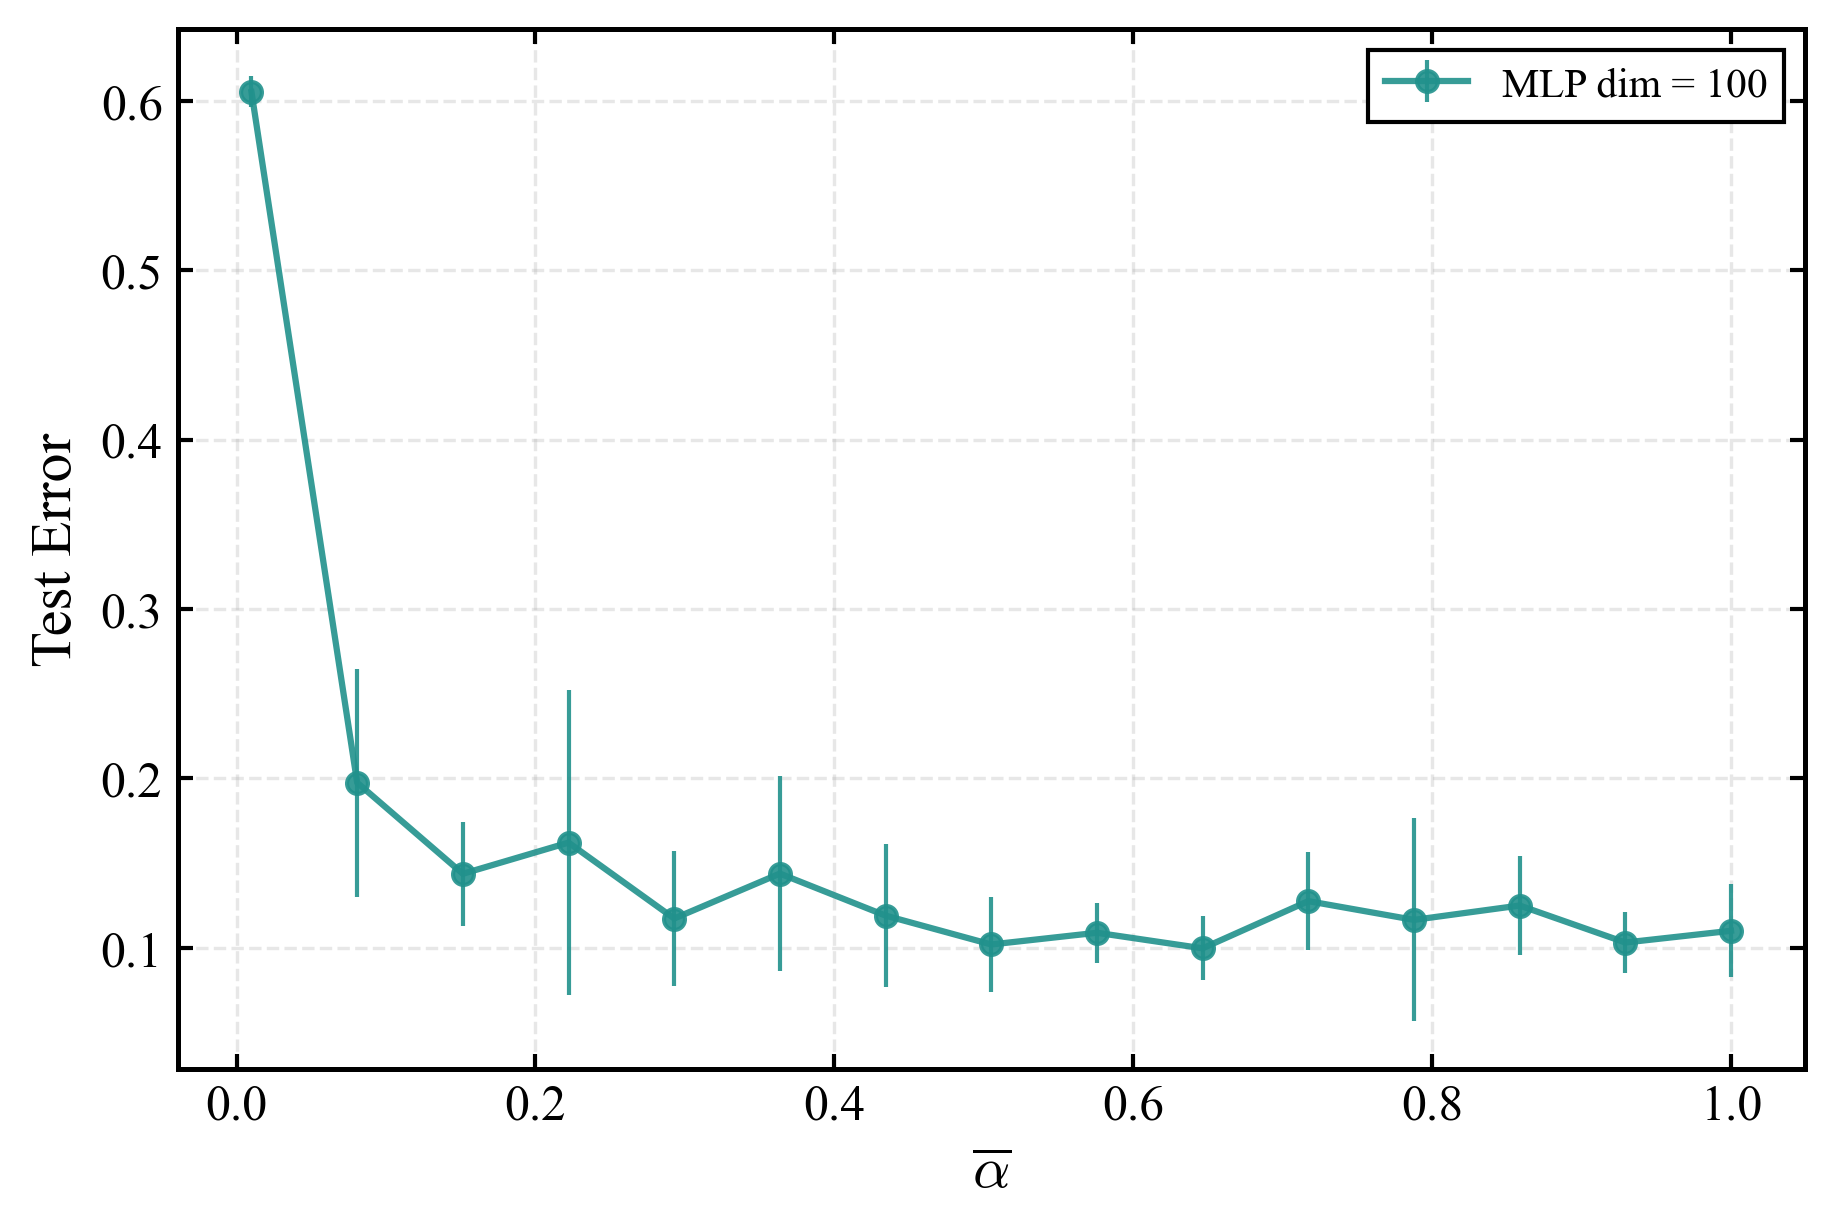

✅ Saved plot: ../results/run_20251217_0723/plots/train_data_vs_alpha_run20251217_0723.png


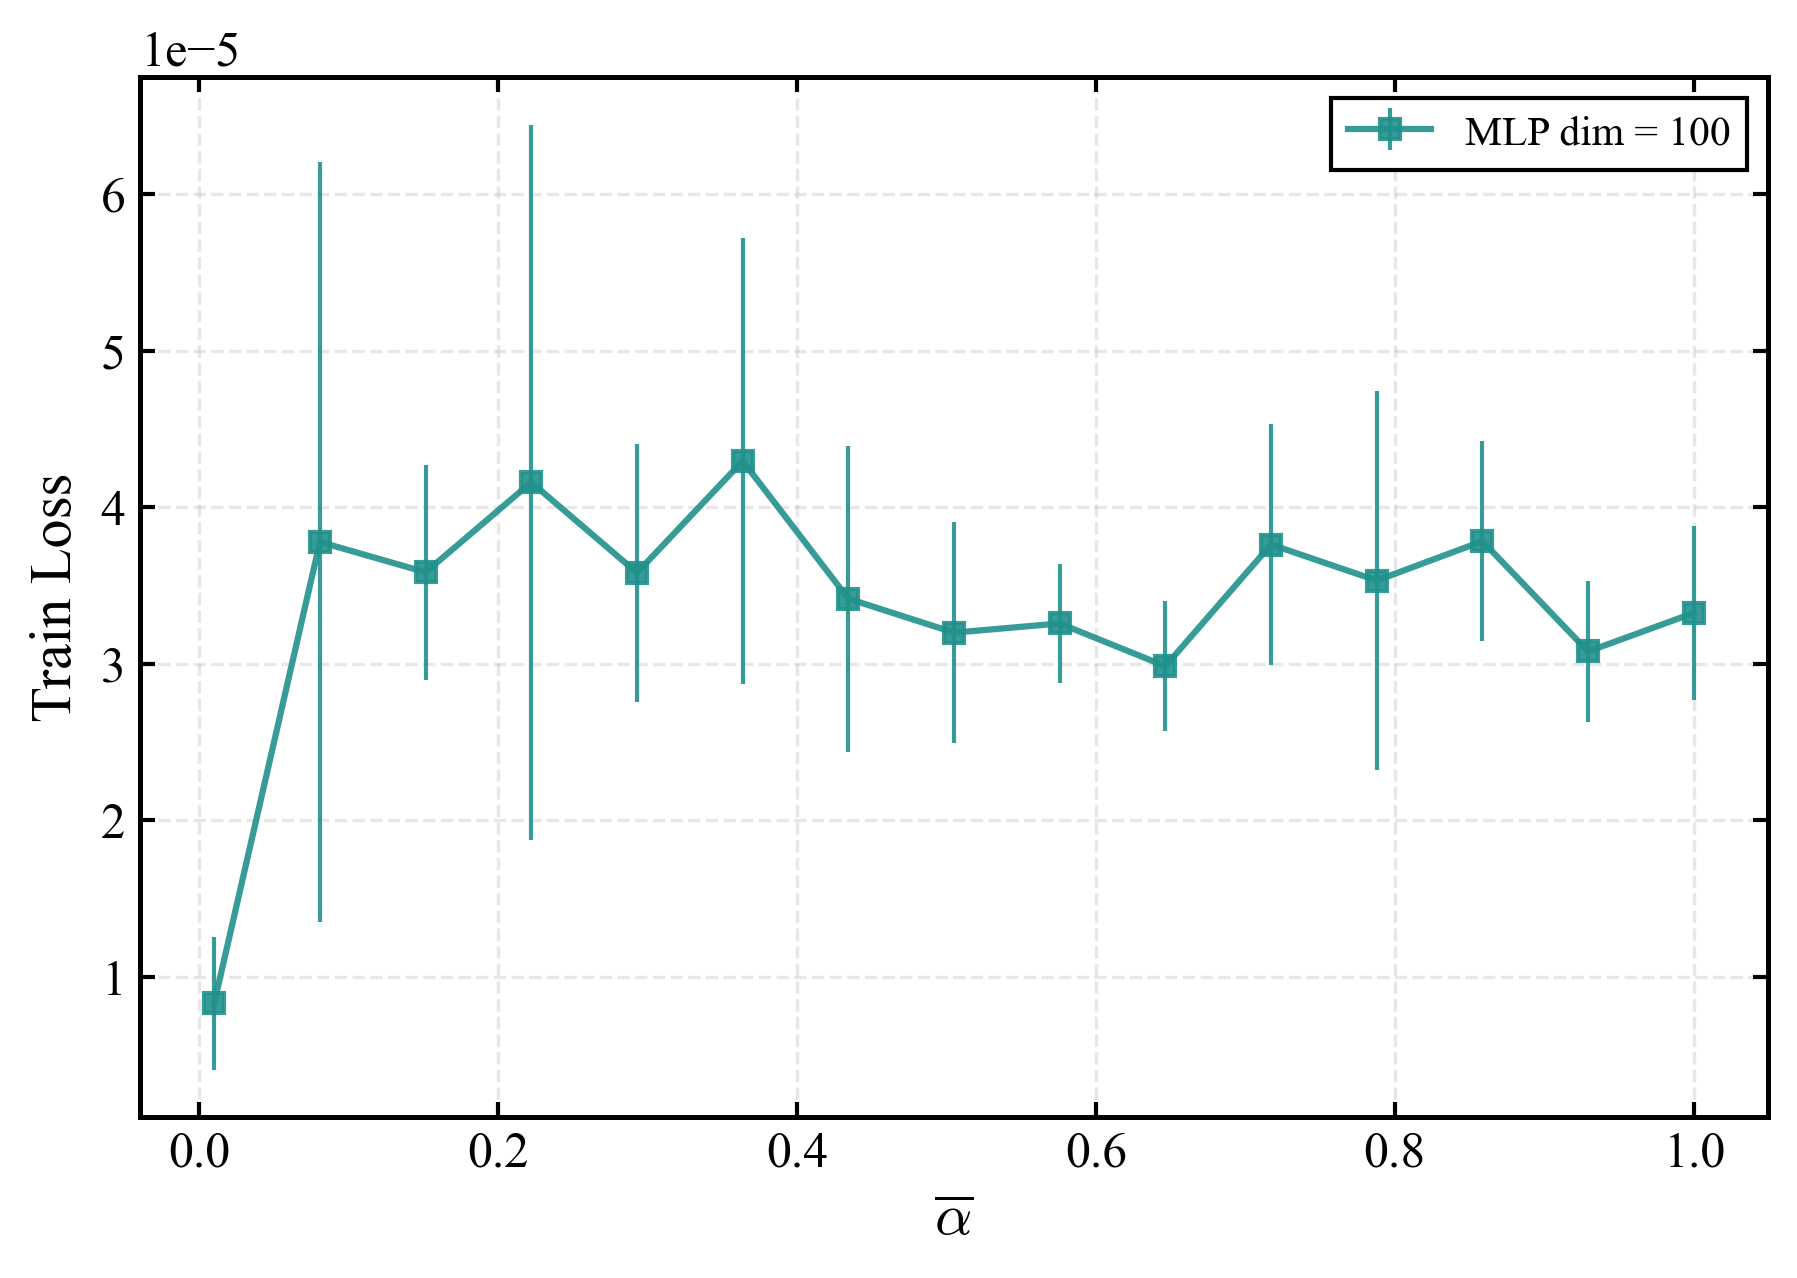

✅ Saved plot: ../results/run_20251217_0723/plots/train_accuracy_vs_alpha_run20251217_0723.png


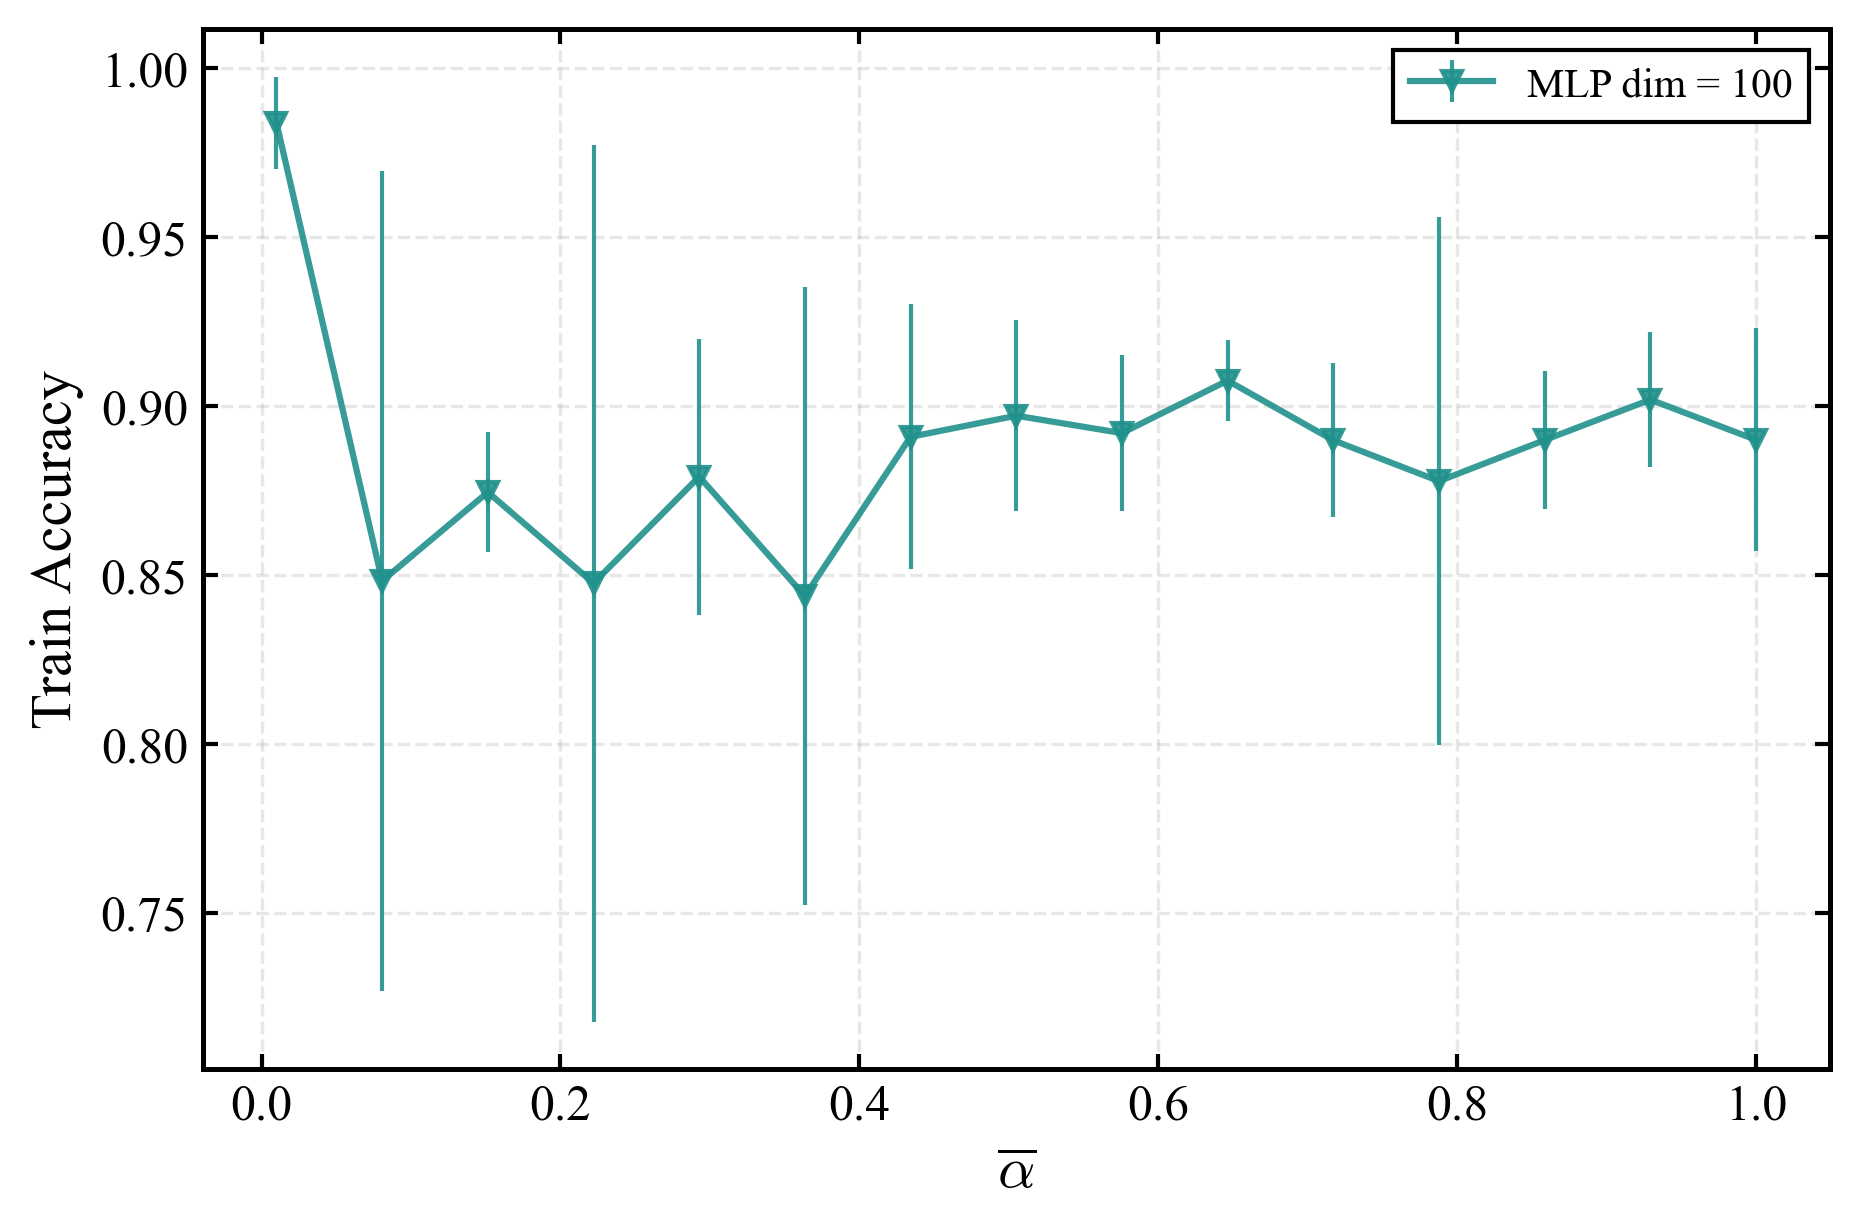

✅ Saved plot: ../results/run_20251217_0723/plots/fine_tune_accuracy_vs_alpha_run20251217_0723.png


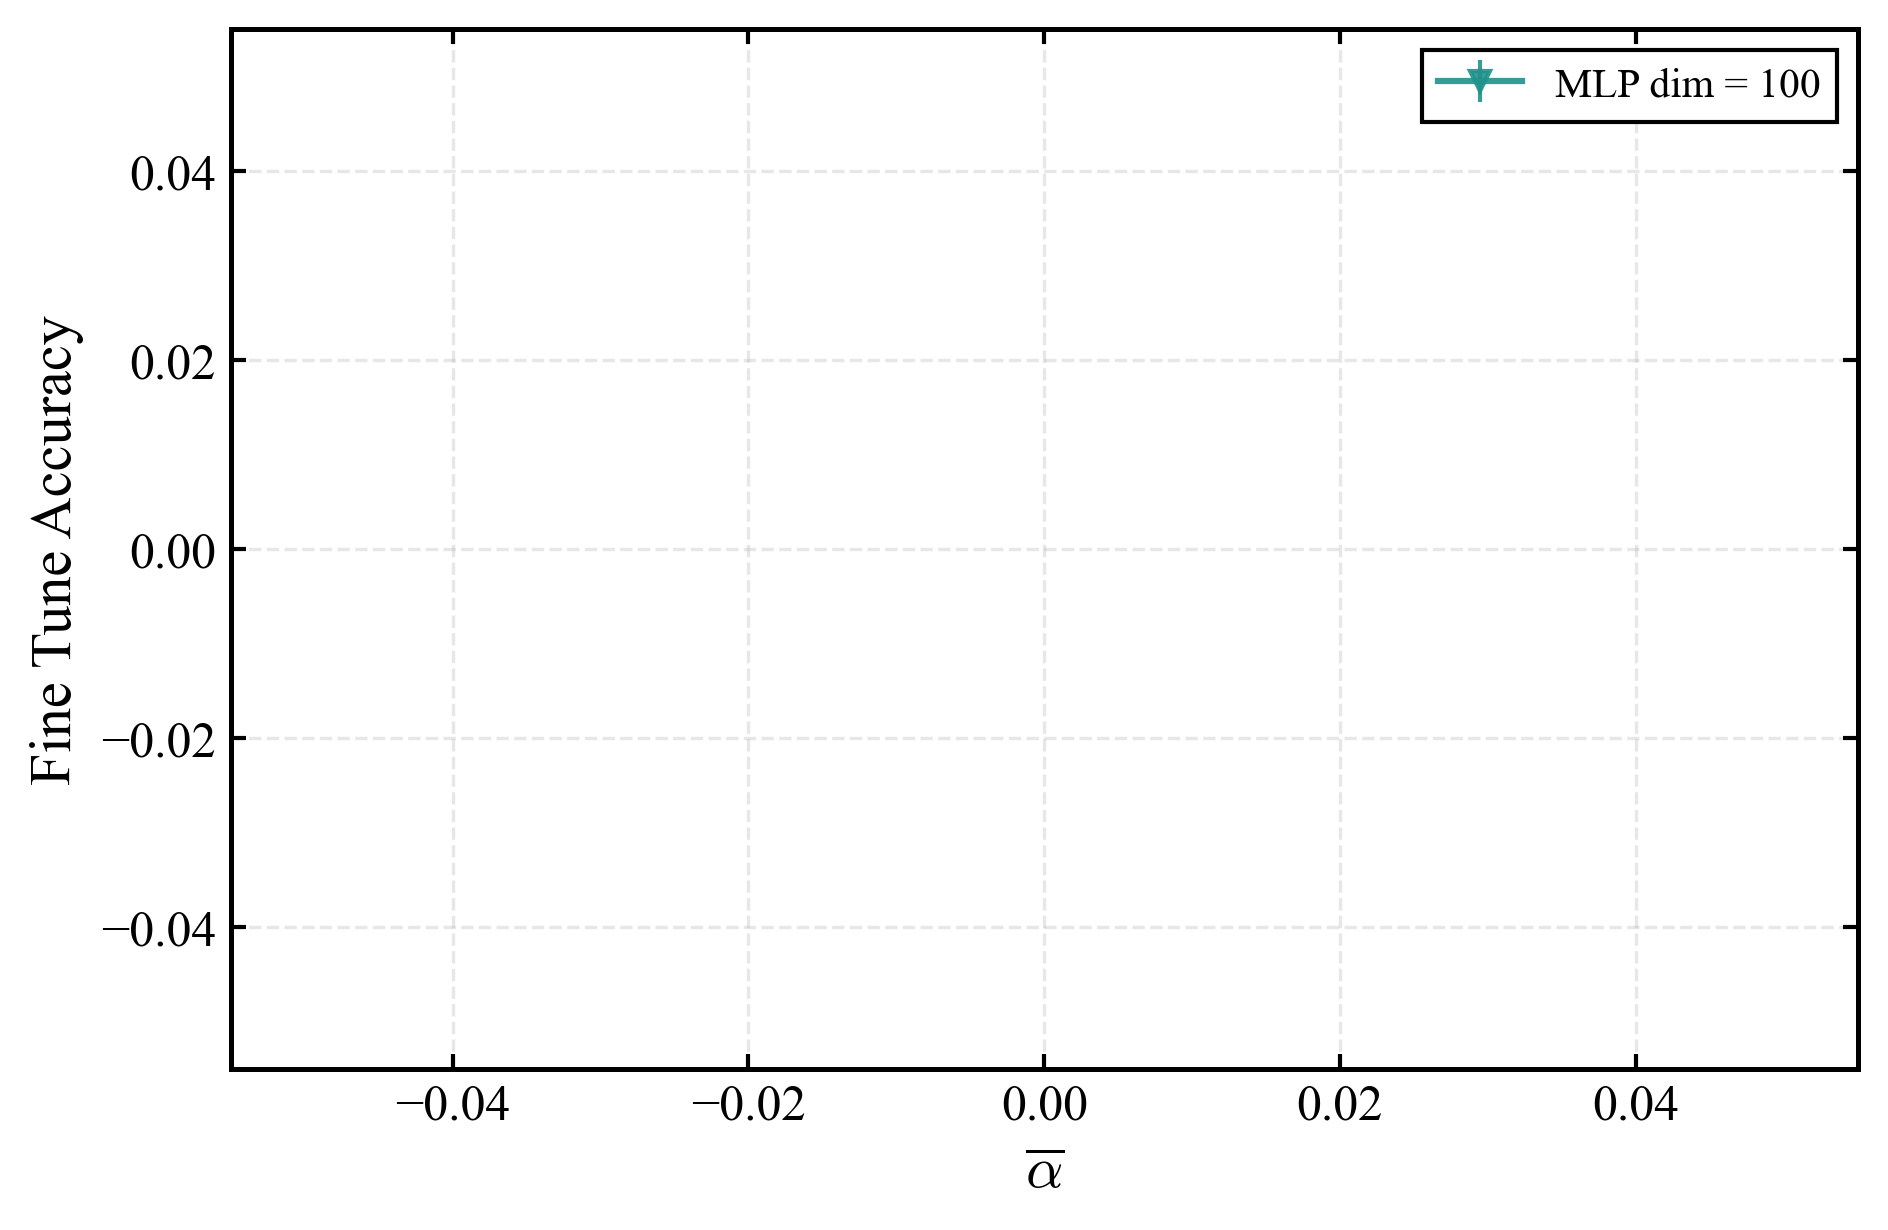

✅ Saved plot: ../results/run_20251217_0723/plots/test_accuracy_vs_alpha_run20251217_0723.png


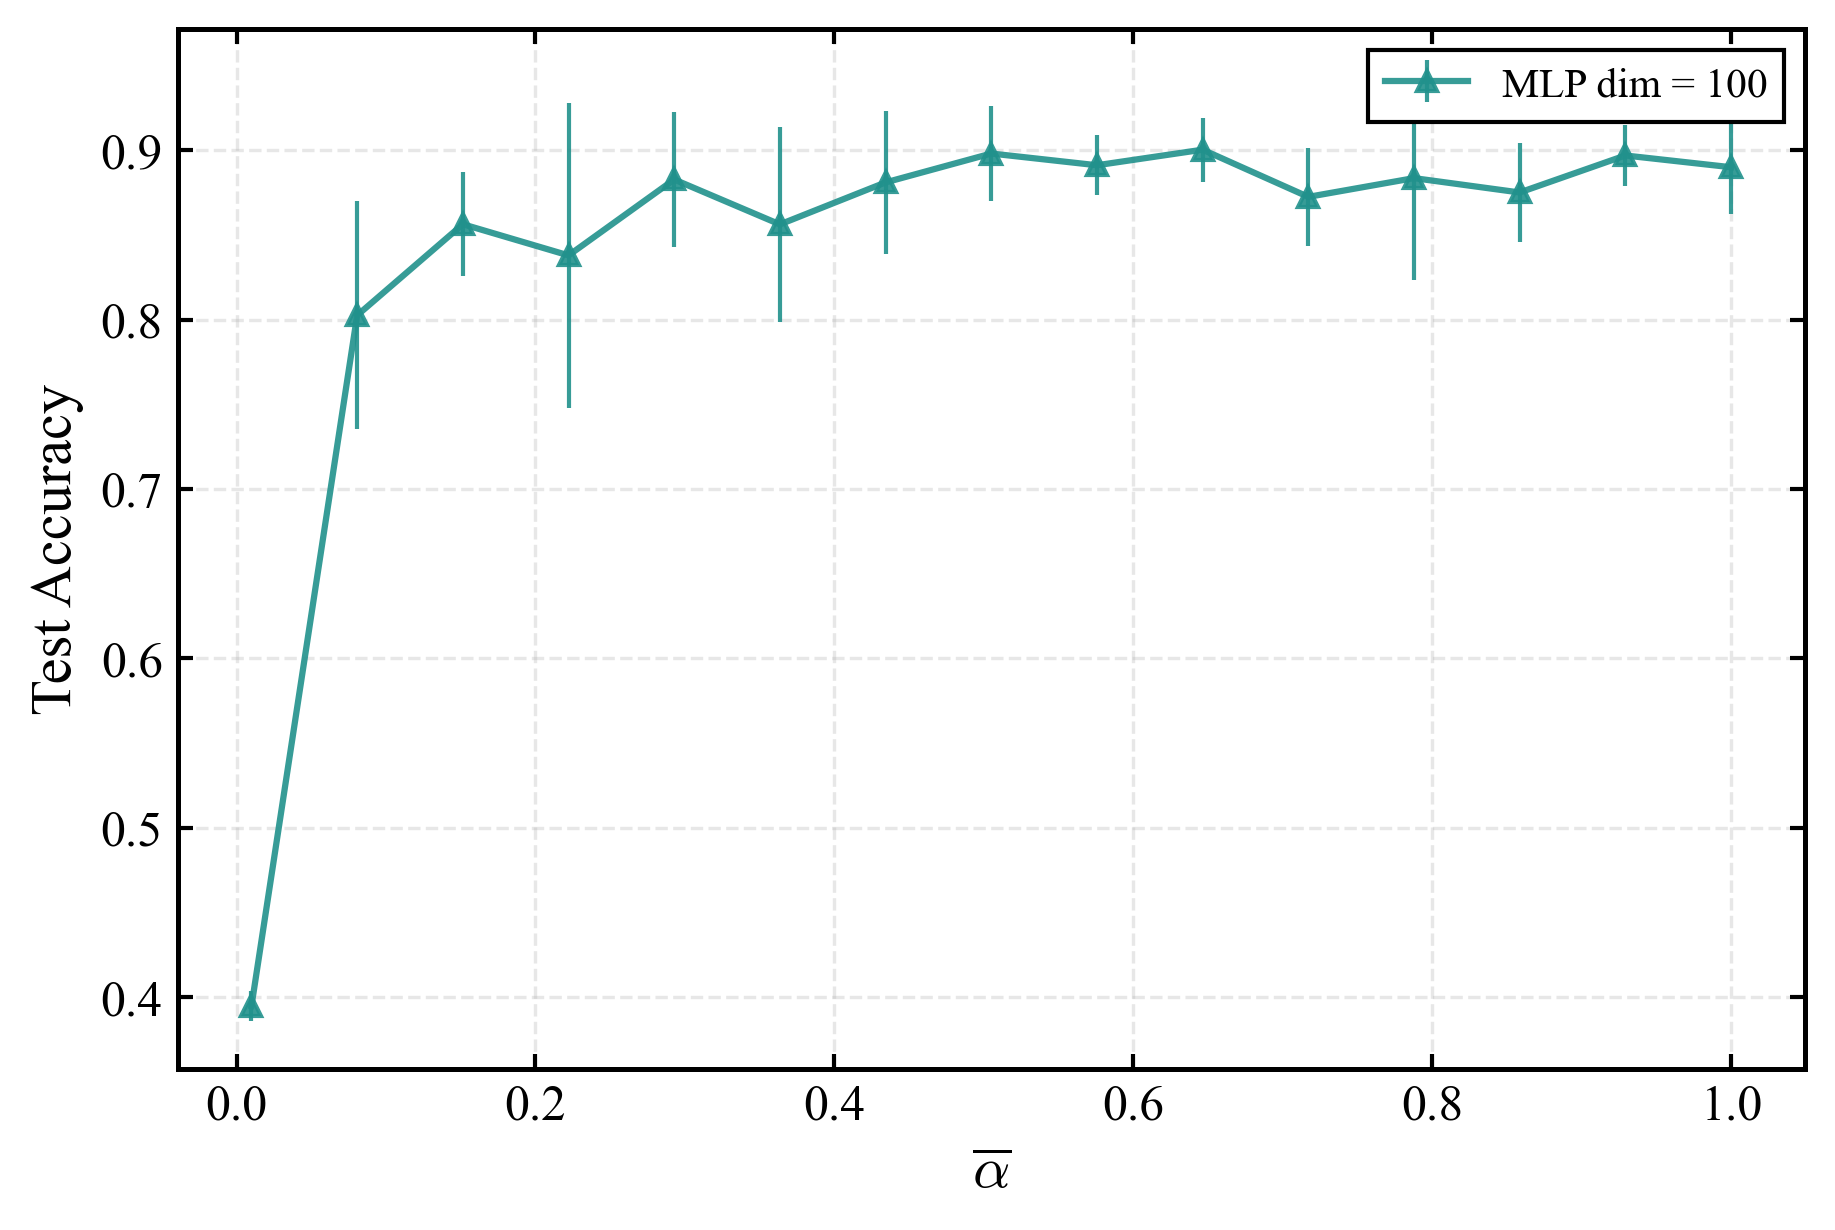

✅ Saved plot: ../results/run_20251217_0723/plots/rank_before_vs_alpha_run20251217_0723.png


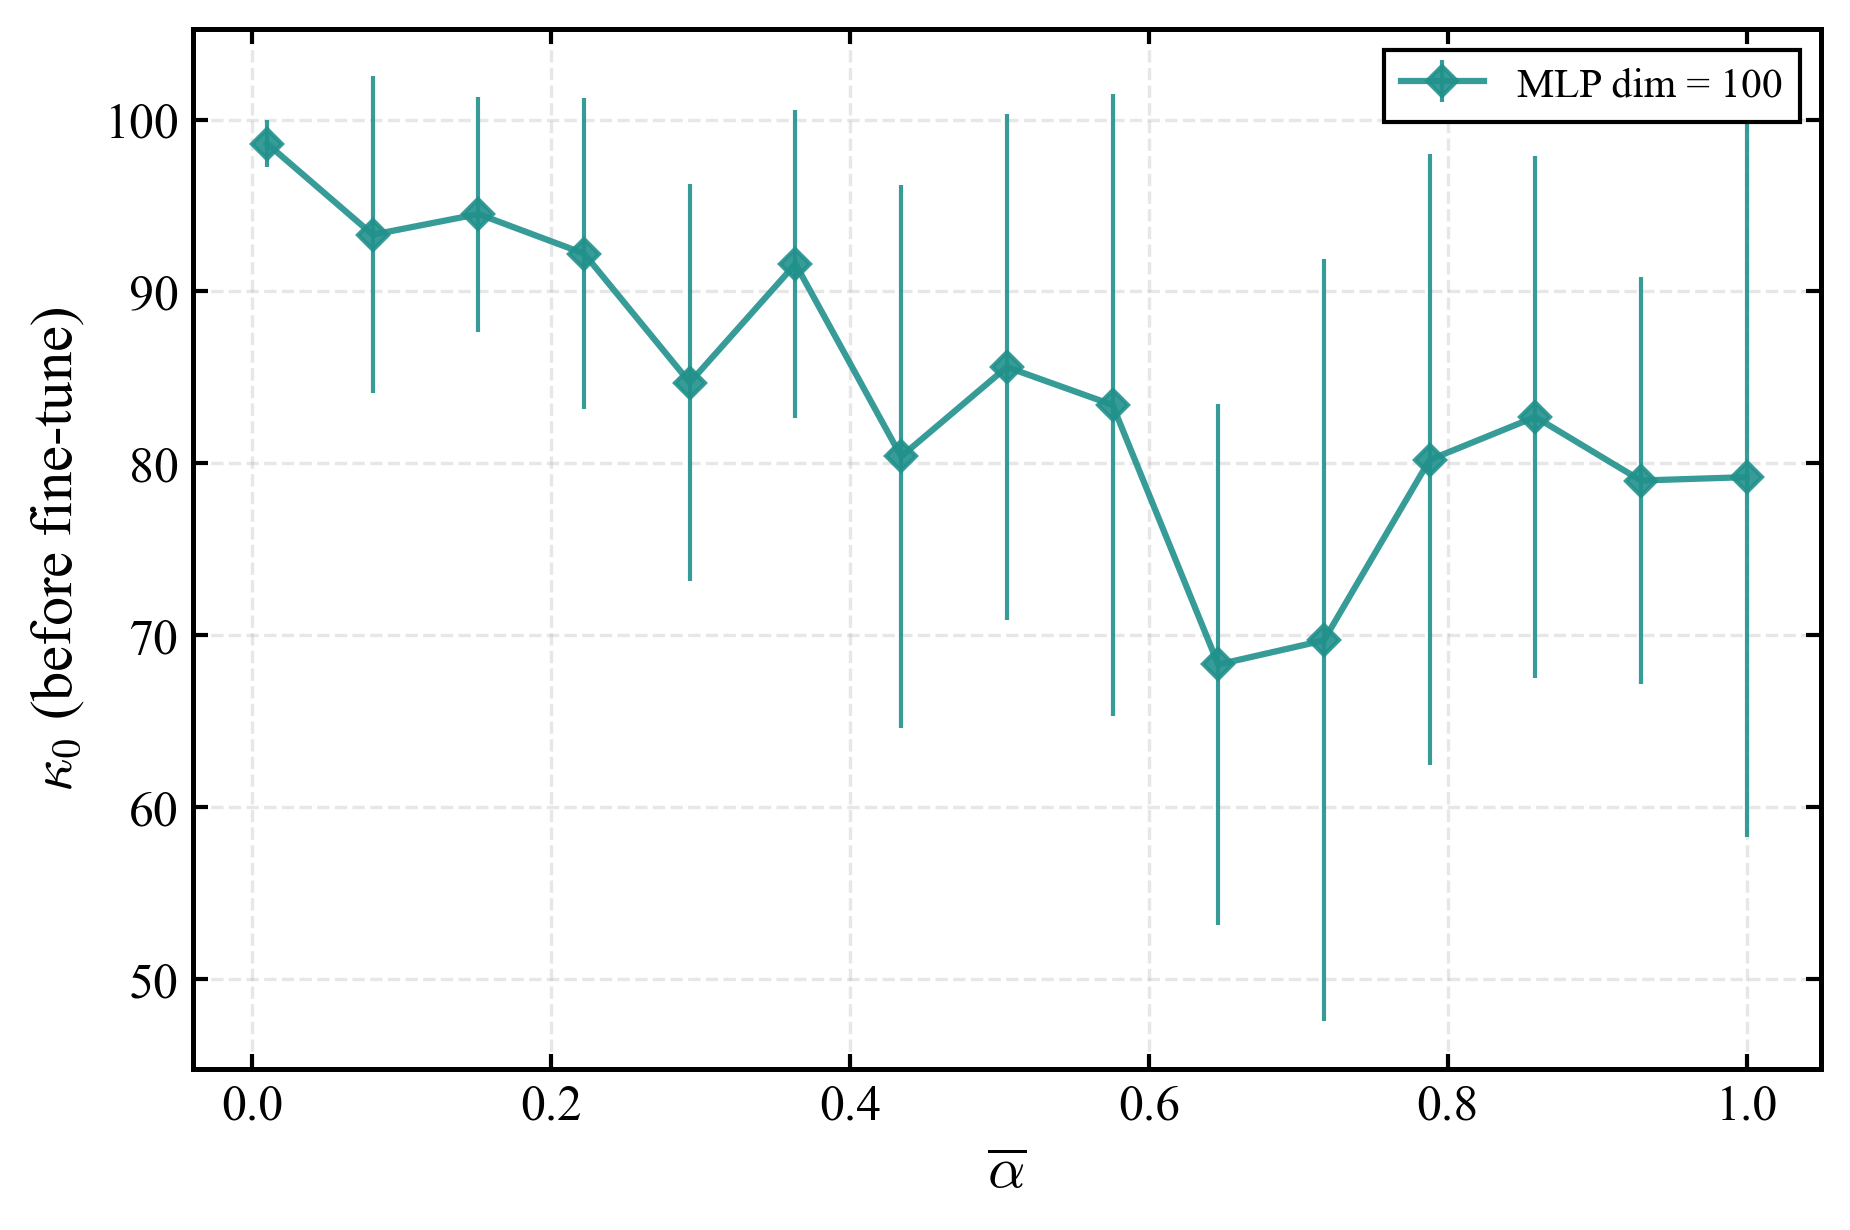

✅ Saved plot: ../results/run_20251217_0723/plots/rank_after_vs_alpha_run20251217_0723.png


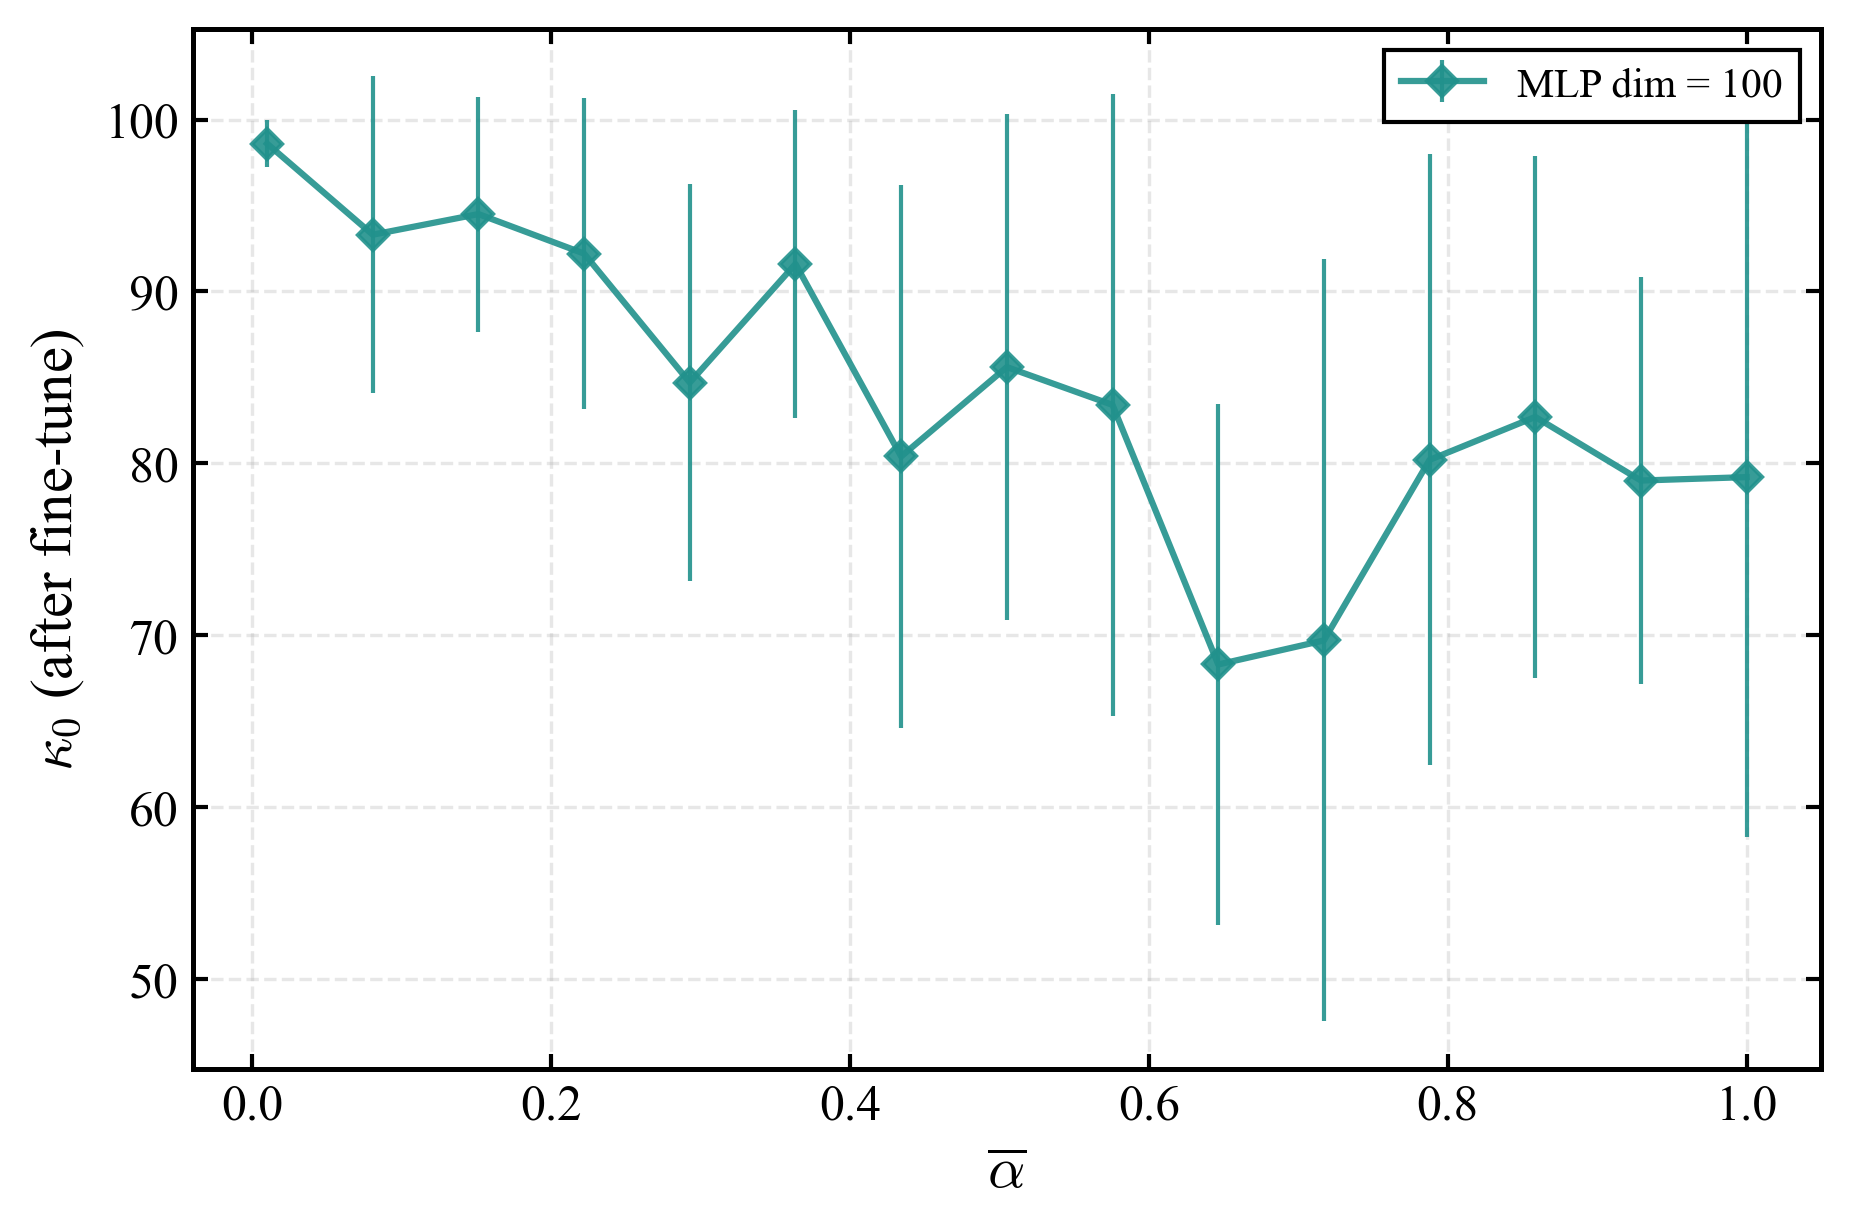

In [5]:
# --- Read the CSV file ---
df = pd.read_csv(base_path)
print(f"✅ Summary loaded ({len(df)} rows) from {base_path}")

# --- Quick preview ---
display(df.head())

# --- 2. Load Data ---
# Ensure base_path, run_id, and plot_path are defined
# df = pd.read_csv(base_path)
print(f"✅ Summary loaded ({len(df)} rows)")

# --- 3. Setup Colors for MLP Dimensions ---
# We map each unique MLP_dim to a specific color so it stays consistent across all plots
unique_dims = sorted(df["MLP_dim"].unique())
palette = sns.color_palette("viridis", n_colors=len(unique_dims))
color_map = {dim: color for dim, color in zip(unique_dims, palette)}

# --- 4. The Generic Plotting Function ---
def plot_metric_by_mlp(df, y_col, y_err_col, ylabel, filename, marker='o', log_y=False):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    
    # Loop through dimensions
    for mlp_dim in unique_dims:
        subset = df[df["MLP_dim"] == mlp_dim].sort_values("alpha")
        
        if subset.empty:
            continue
            
        ax.errorbar(
            subset["alpha"],
            subset[y_col],
            yerr=subset.get(y_err_col, 0),
            marker=marker,
            label=f"MLP dim = {mlp_dim}",
            color=color_map[mlp_dim], # Consistent color
            capsize=0,
            elinewidth=1.0,
            alpha=0.9
        )

    # Labels and Formatting
    ax.set_xlabel(r"$\overline{\alpha}$")
    ax.set_ylabel(ylabel)
    
    if log_y:
        ax.set_yscale('log')

    # --- BOX STYLE ---
    ax.set_axisbelow(True)
    ax.tick_params(direction='in', top=True, right=True, which='both', width=1.0)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.2)

    # Legend
    ax.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1.0, loc='best')

    # Save
    save_full = os.path.join(plot_path, filename)
    plt.savefig(save_full)
    print(f"✅ Saved plot: {save_full}")
    plt.show()

# --- 5. Generate All 7 Plots ---

# 1. Label Error
plot_metric_by_mlp(
    df, "label_err_mean", "label_err_std", 
    "Test Error", f"label_error_vs_alpha_run{run_id}.png", 
    marker='o'
)

# 2. Train Loss
plot_metric_by_mlp(
    df, "train_data_mean", "train_total_std", 
    "Train Loss", f"train_data_vs_alpha_run{run_id}.png", 
    marker='s' # Square
)

# 3. Train Accuracy
plot_metric_by_mlp(
    df, "acc_train_mean", "acc_train_std", 
    "Train Accuracy", f"train_accuracy_vs_alpha_run{run_id}.png", 
    marker='v' # Down triangle
)

# 4. Fine Tune Accuracy
plot_metric_by_mlp(
    df, "acc_fine_tune_mean", "acc_fine_tune_std", 
    "Fine Tune Accuracy", f"fine_tune_accuracy_vs_alpha_run{run_id}.png", 
    marker='v'
)

# 5. Test Accuracy
plot_metric_by_mlp(
    df, "acc_test_mean", "acc_test_std", 
    "Test Accuracy", f"test_accuracy_vs_alpha_run{run_id}.png", 
    marker='^' # Up triangle
)

# 6. Rank Before
plot_metric_by_mlp(
    df, "rank_before_mean", "rank_before_std", 
    r"$\kappa_0$ (before fine-tune)", f"rank_before_vs_alpha_run{run_id}.png", 
    marker='D' # Diamond
)

# 7. Rank After
plot_metric_by_mlp(
    df, "rank_after_mean", "rank_after_std", 
    r"$\kappa_0$ (after fine-tune)", f"rank_after_vs_alpha_run{run_id}.png", 
    marker='D'
)

## 3. Results visualisation

Found 15 heavy_data files.

--- File: ../results/run_20251217_0723/heavy_data_0.pkl ---
Saved → ../results/run_20251217_0723/plots/Cumulative_Singular_Spectrum_heavy_data_0.pkl.png



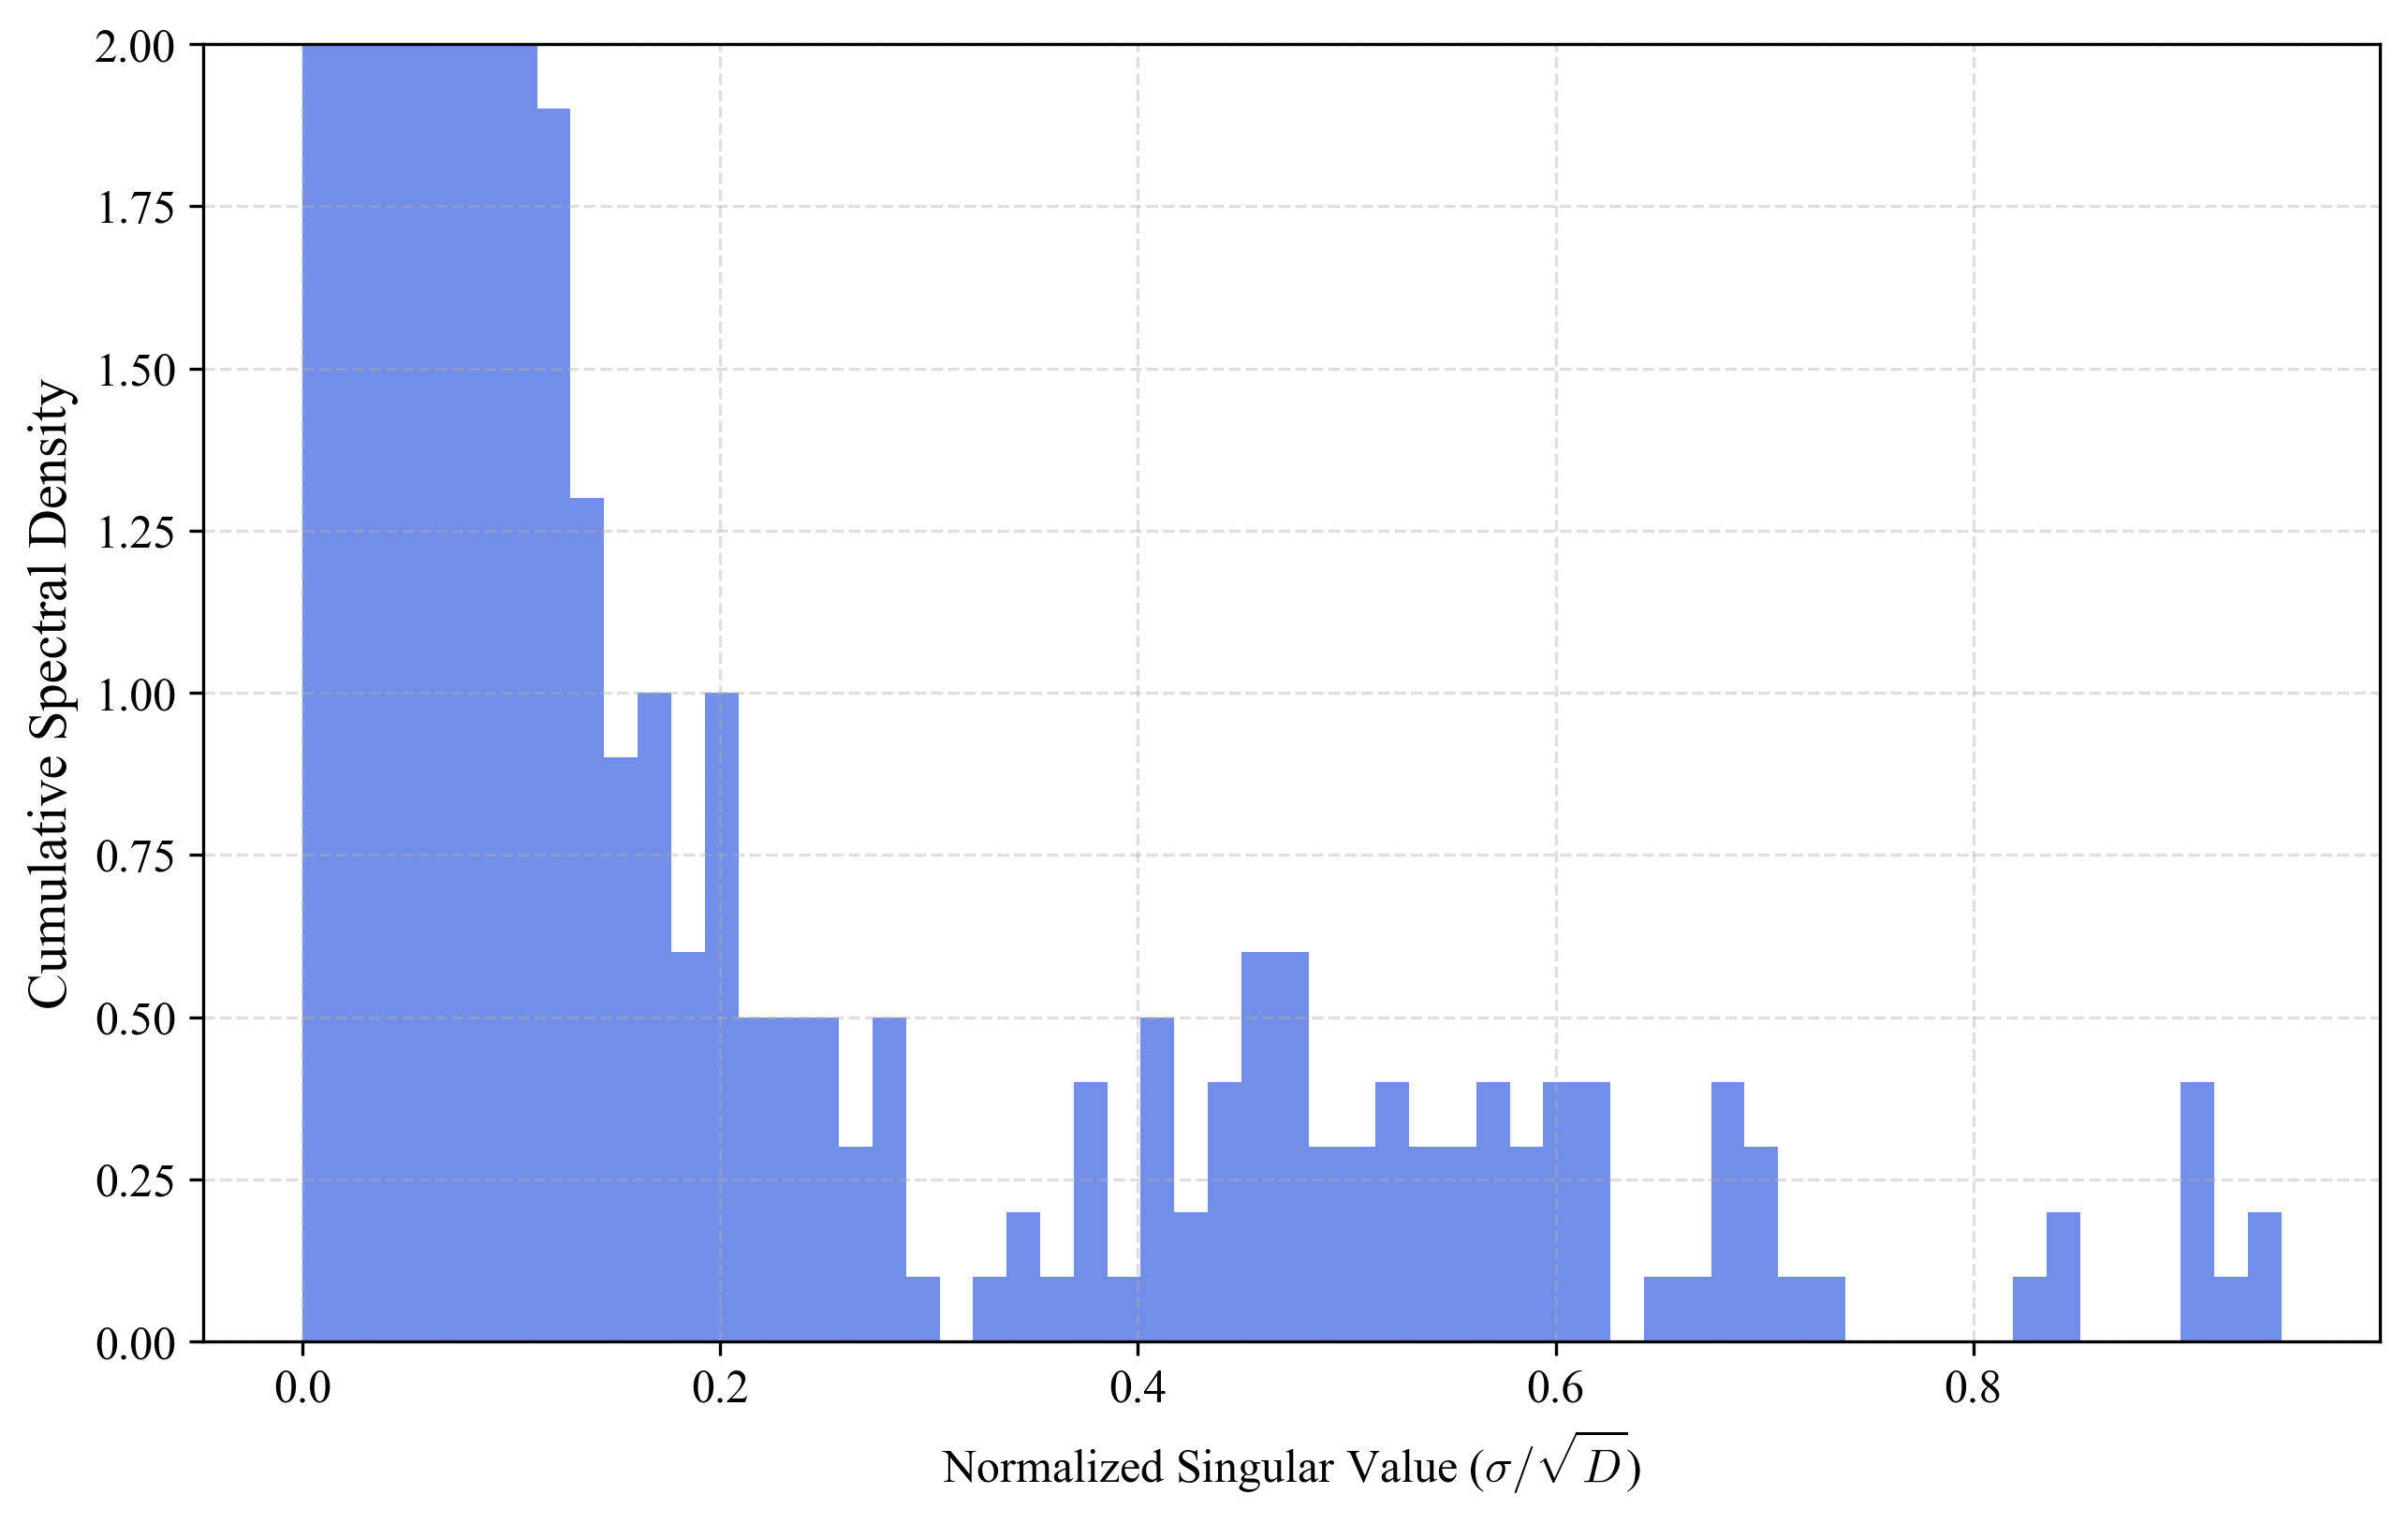

--- File: ../results/run_20251217_0723/heavy_data_1.pkl ---
Saved → ../results/run_20251217_0723/plots/Cumulative_Singular_Spectrum_heavy_data_1.pkl.png



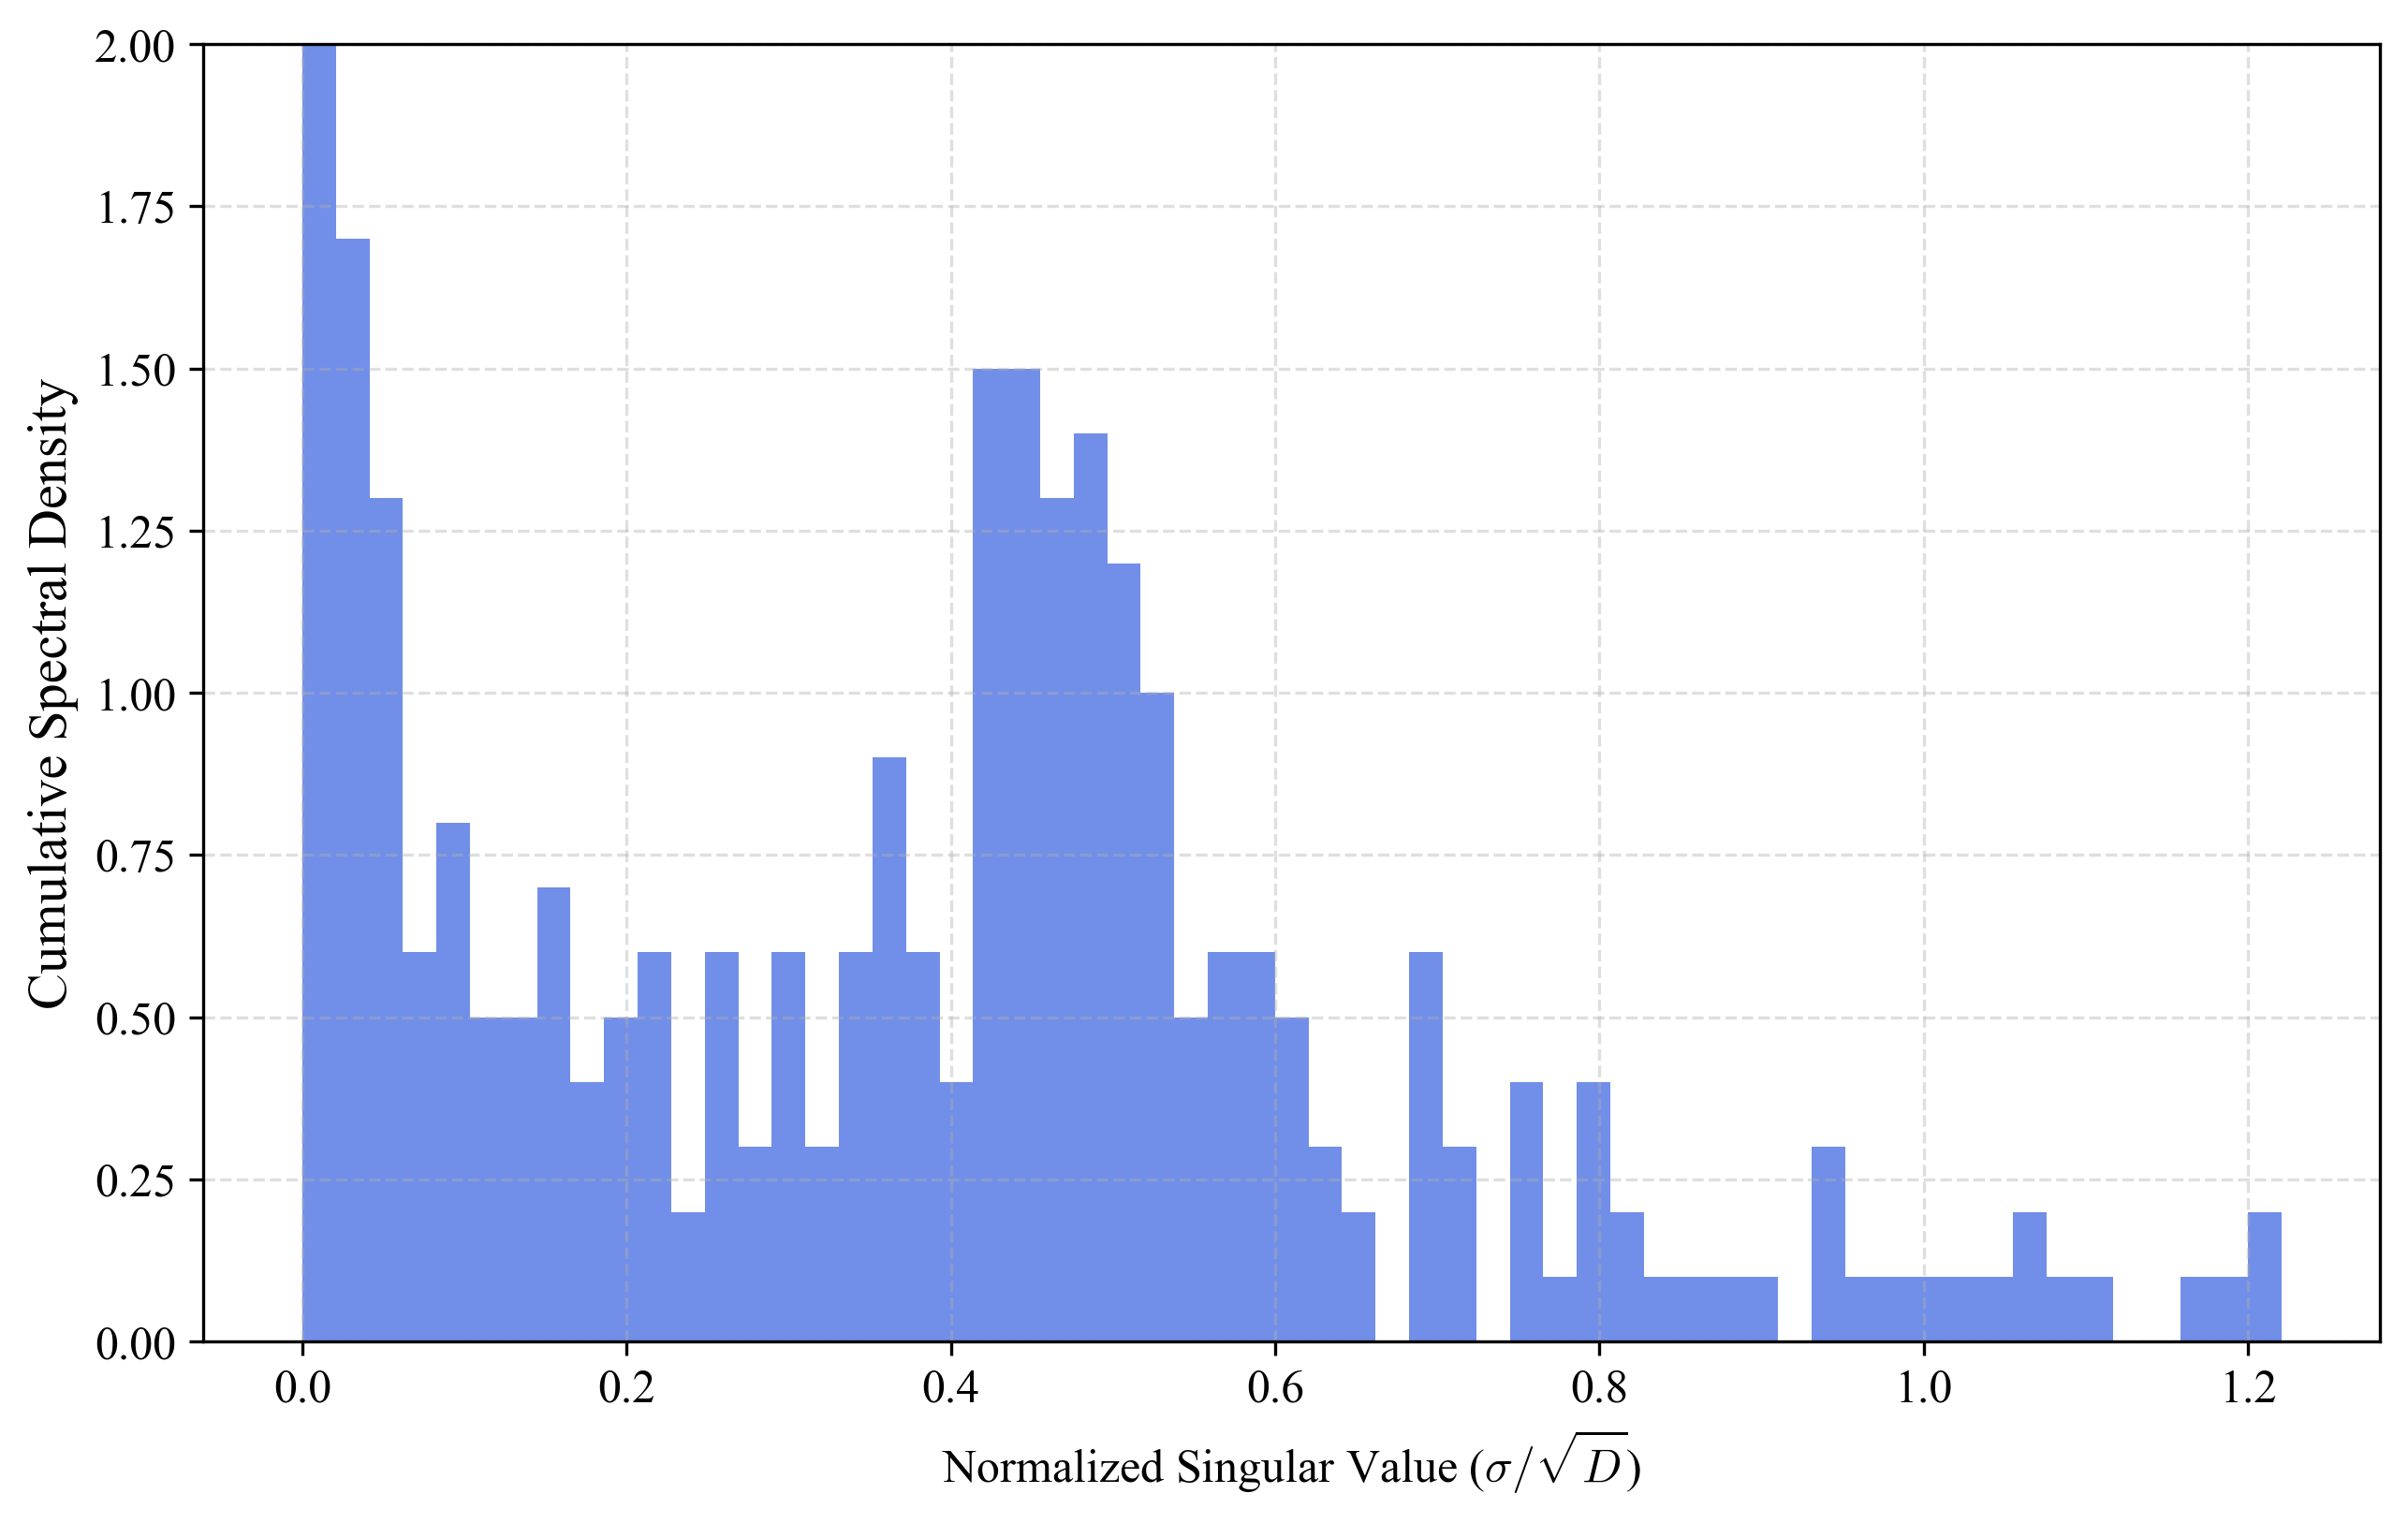

--- File: ../results/run_20251217_0723/heavy_data_10.pkl ---
Saved → ../results/run_20251217_0723/plots/Cumulative_Singular_Spectrum_heavy_data_10.pkl.png



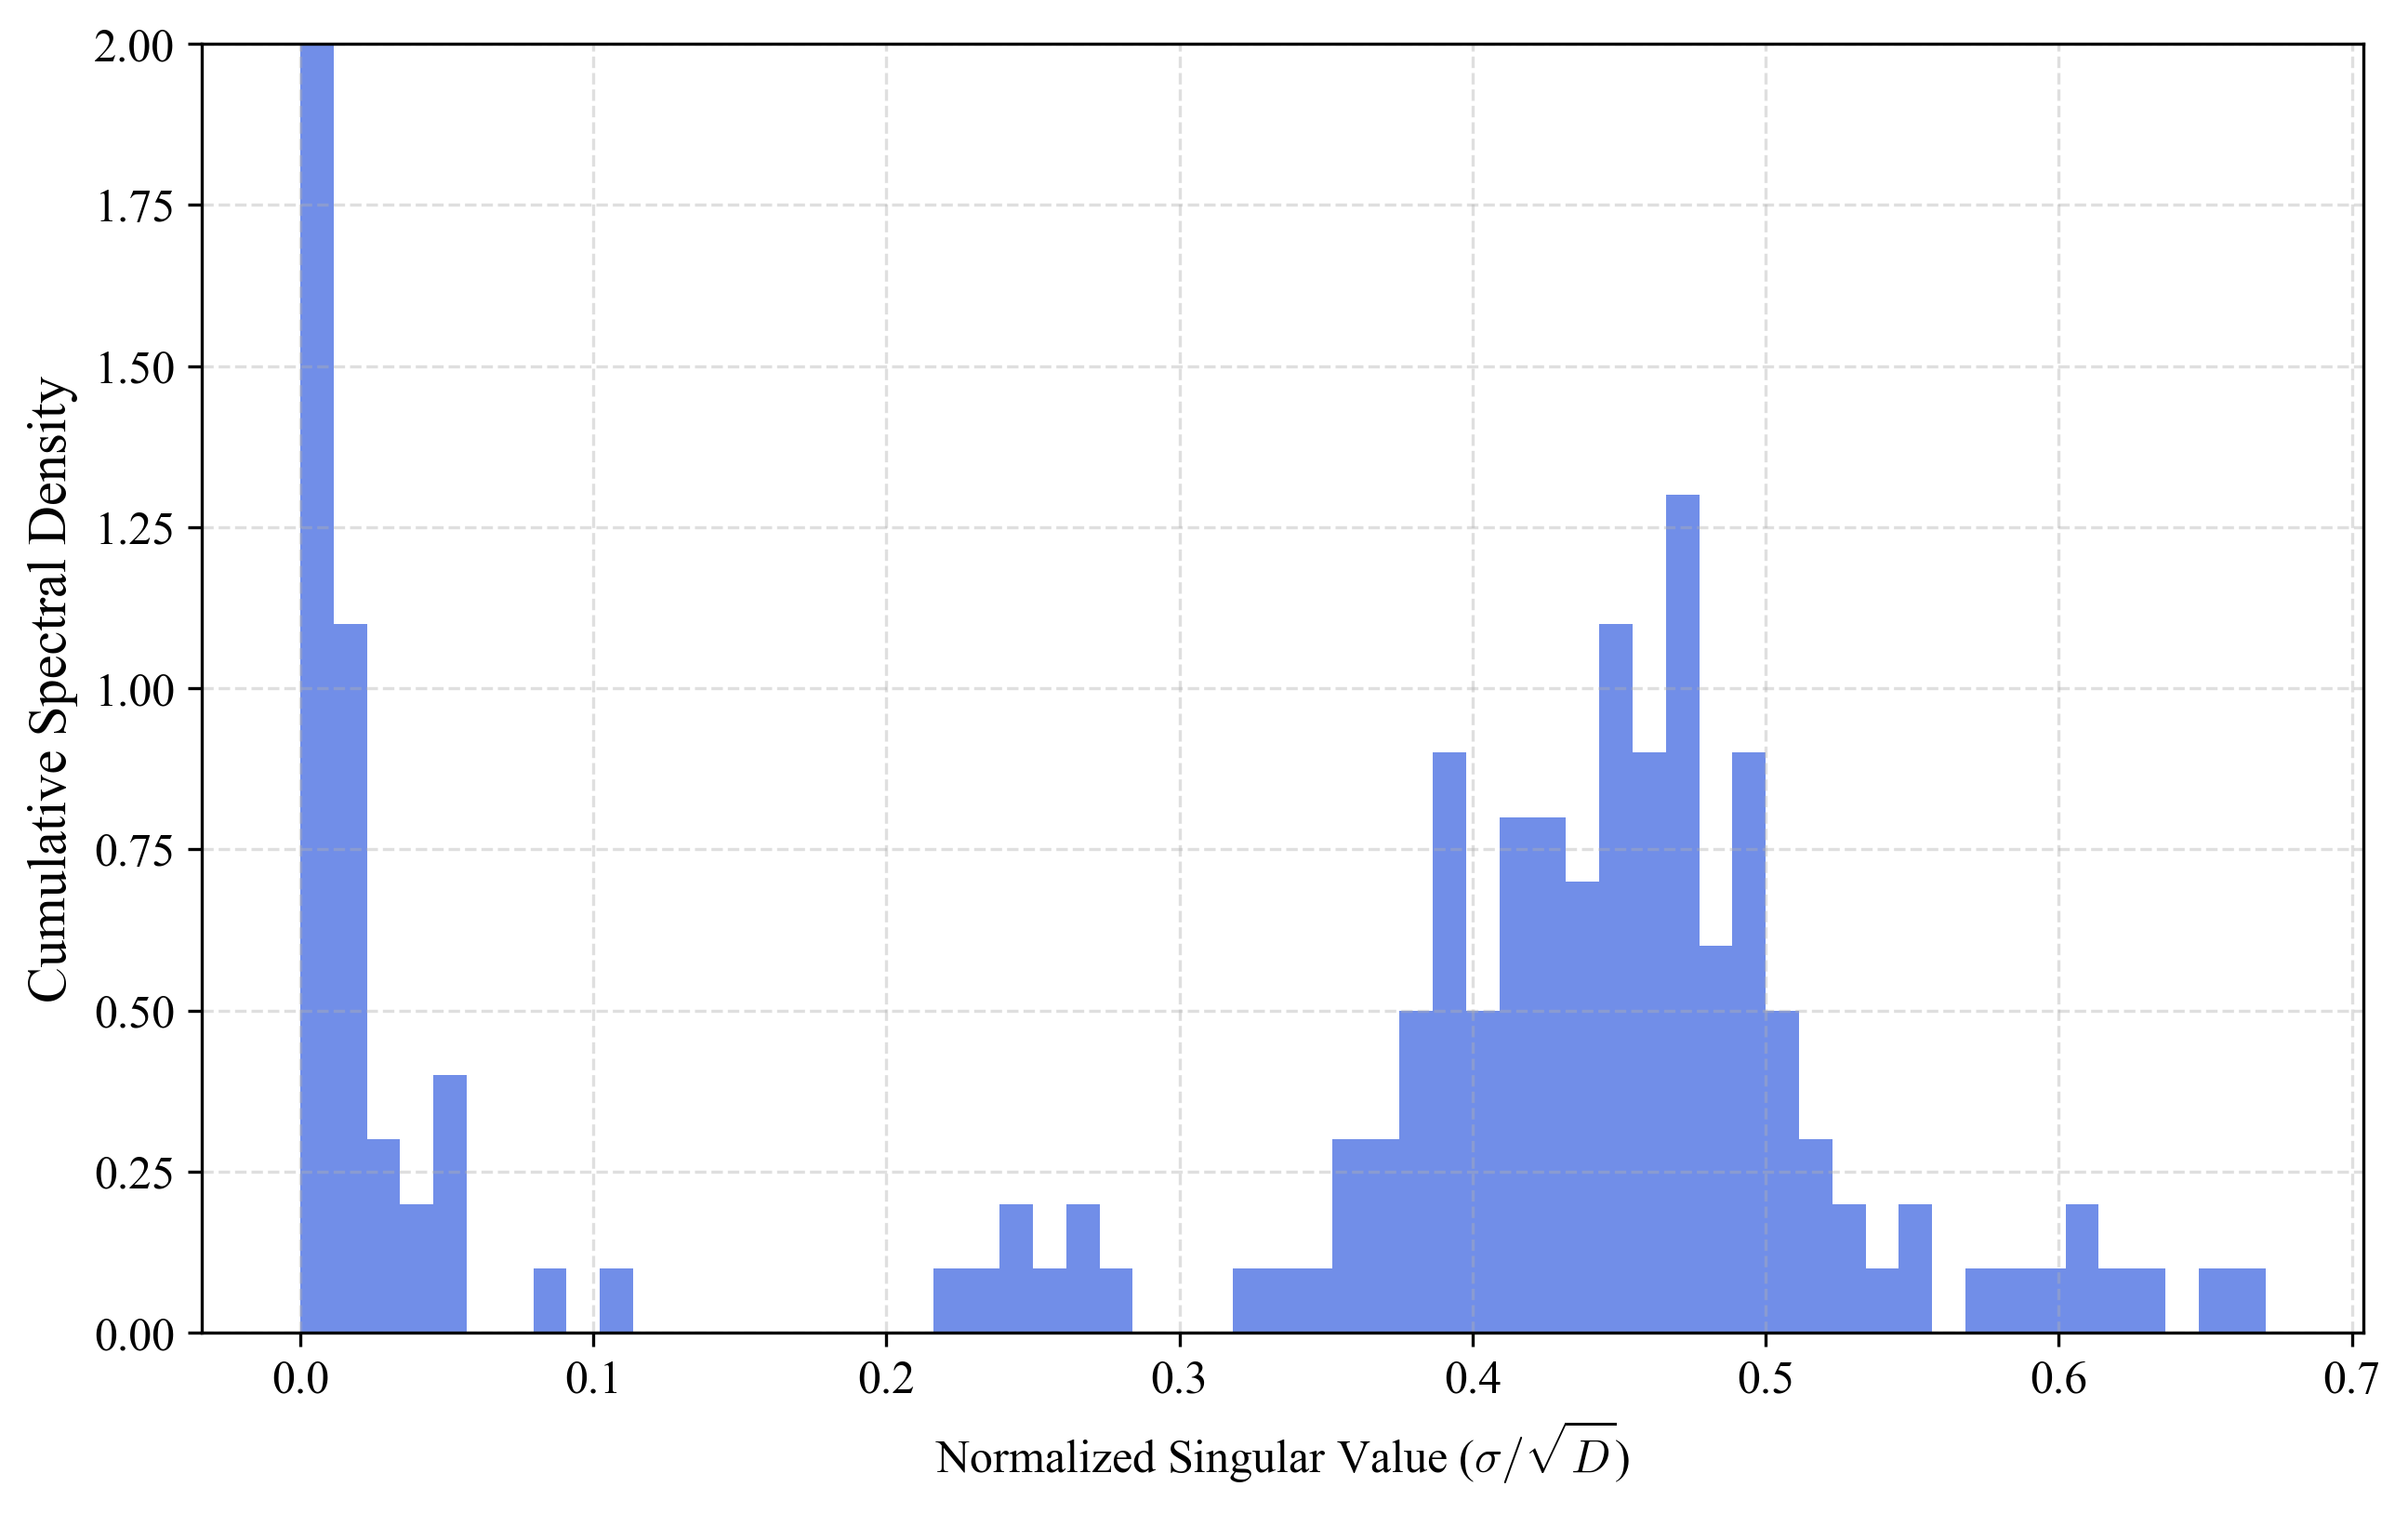

--- File: ../results/run_20251217_0723/heavy_data_11.pkl ---
Saved → ../results/run_20251217_0723/plots/Cumulative_Singular_Spectrum_heavy_data_11.pkl.png



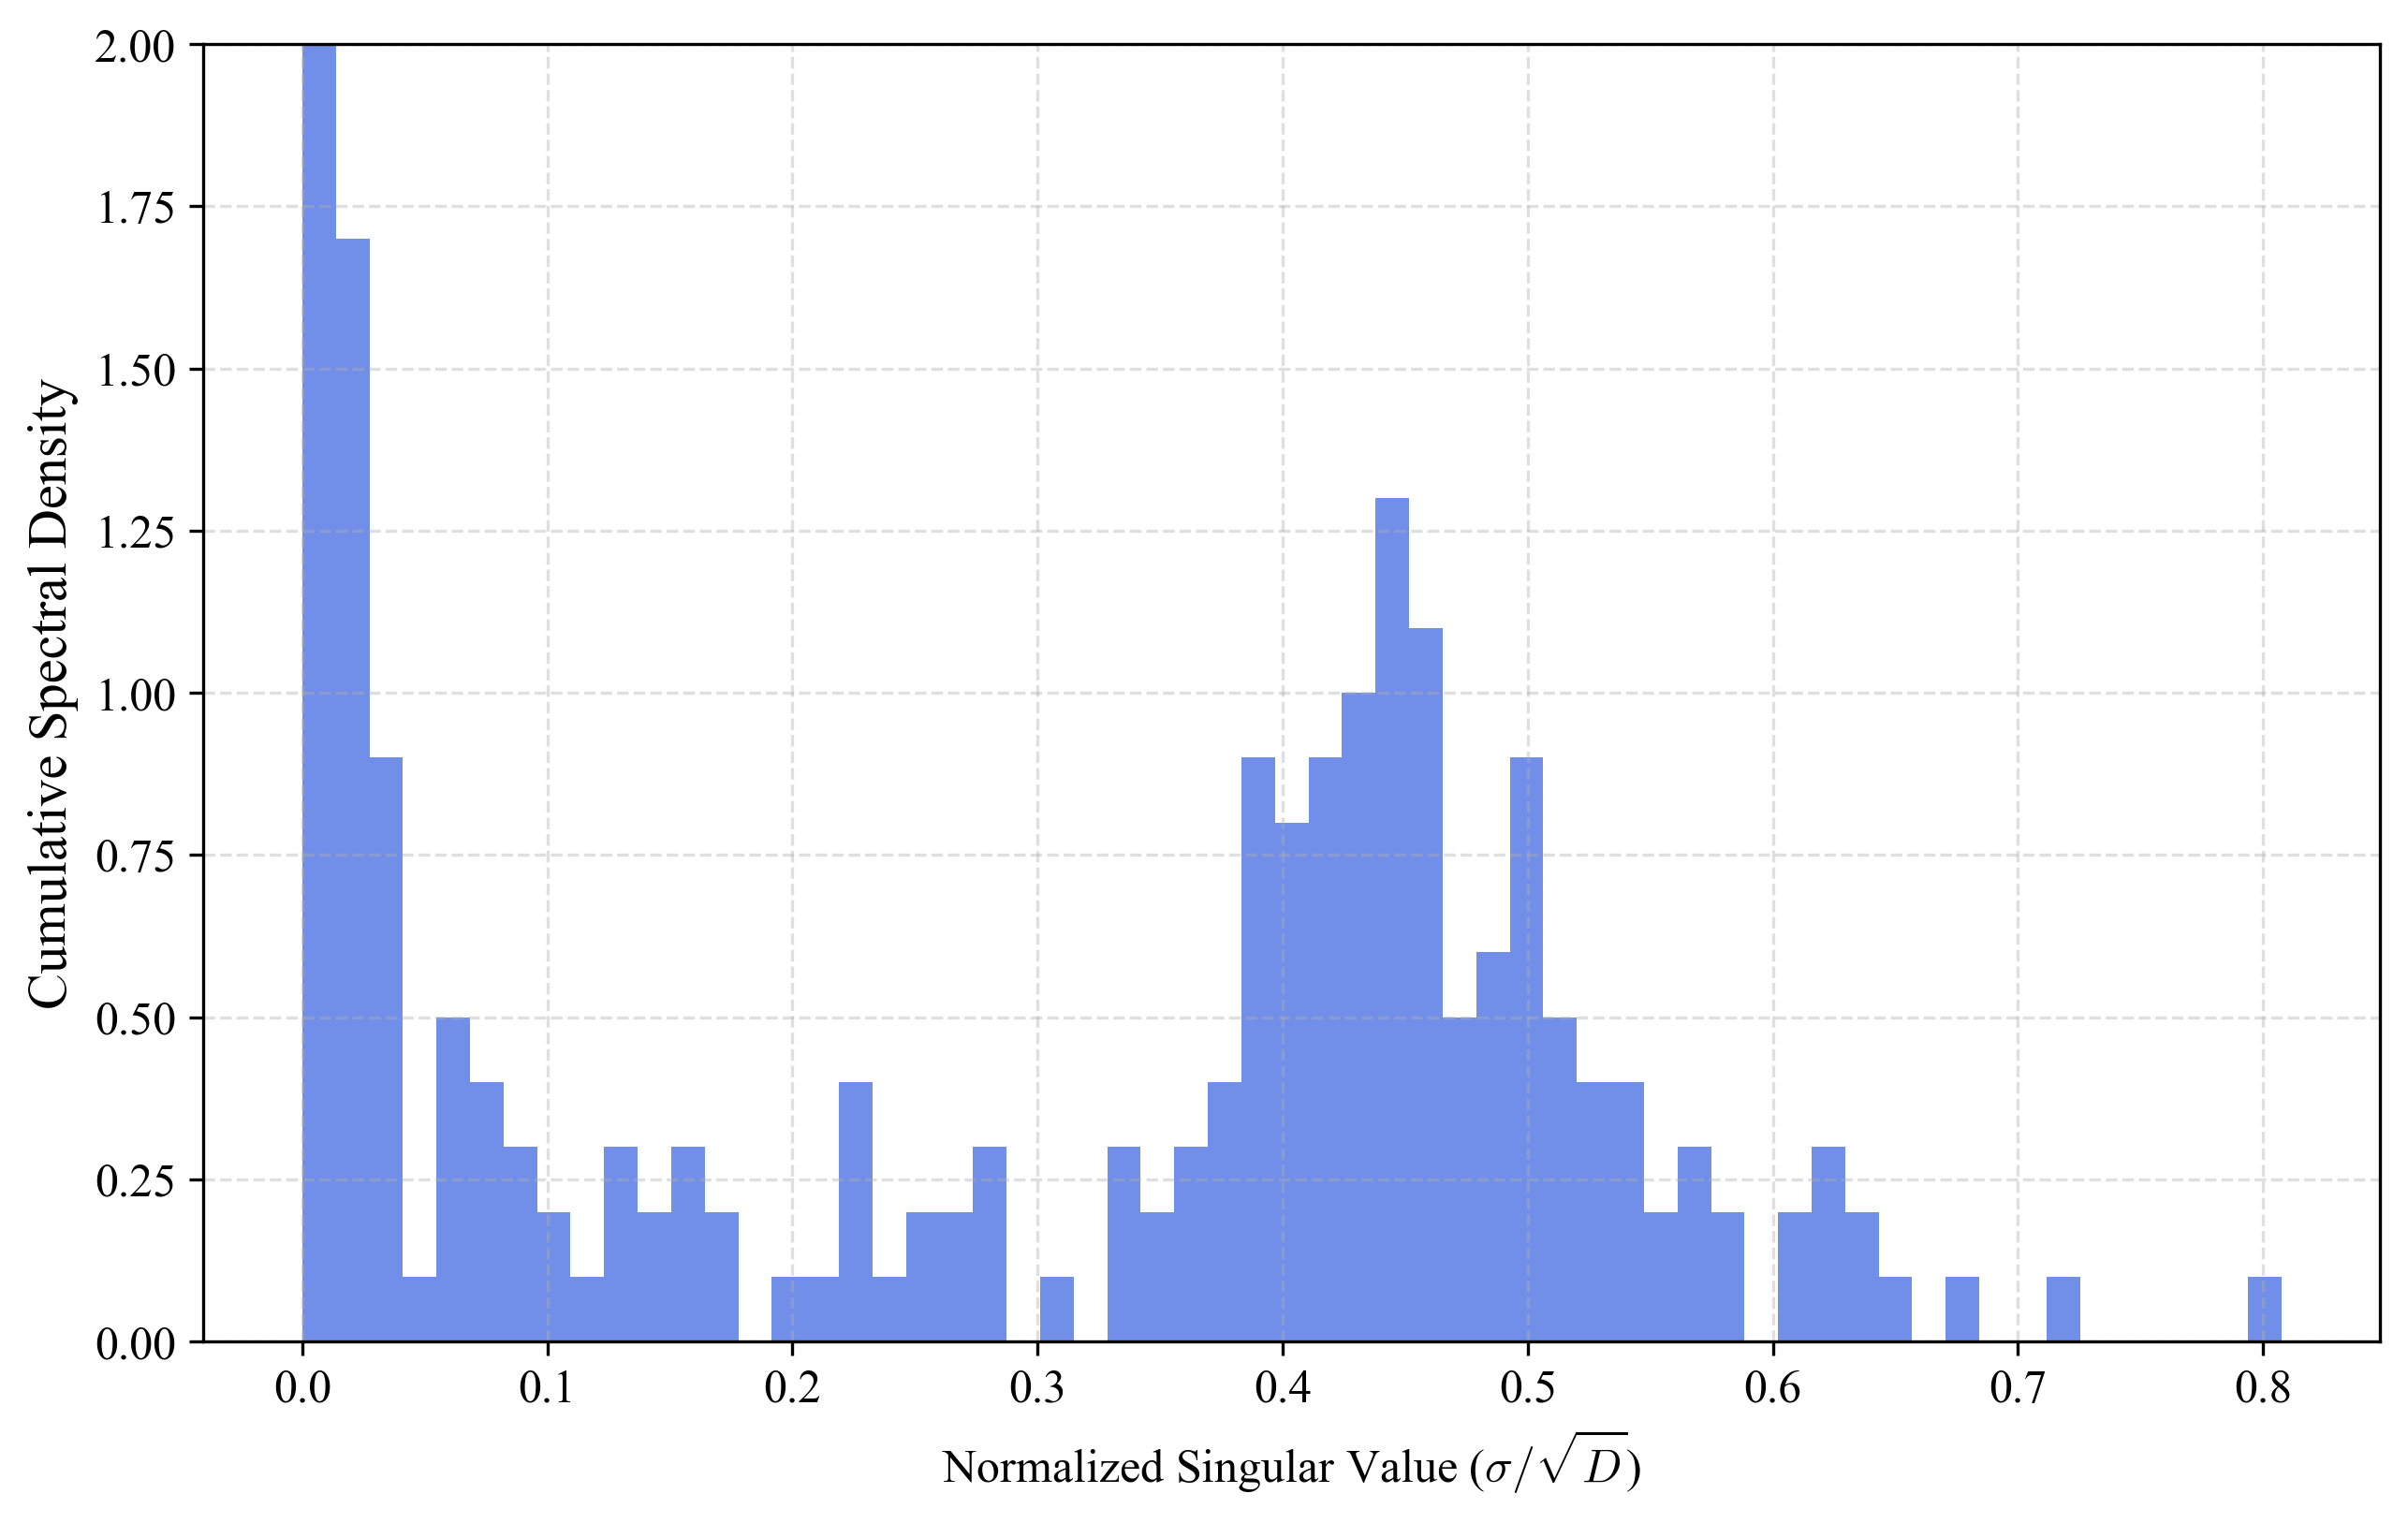

--- File: ../results/run_20251217_0723/heavy_data_12.pkl ---
Saved → ../results/run_20251217_0723/plots/Cumulative_Singular_Spectrum_heavy_data_12.pkl.png



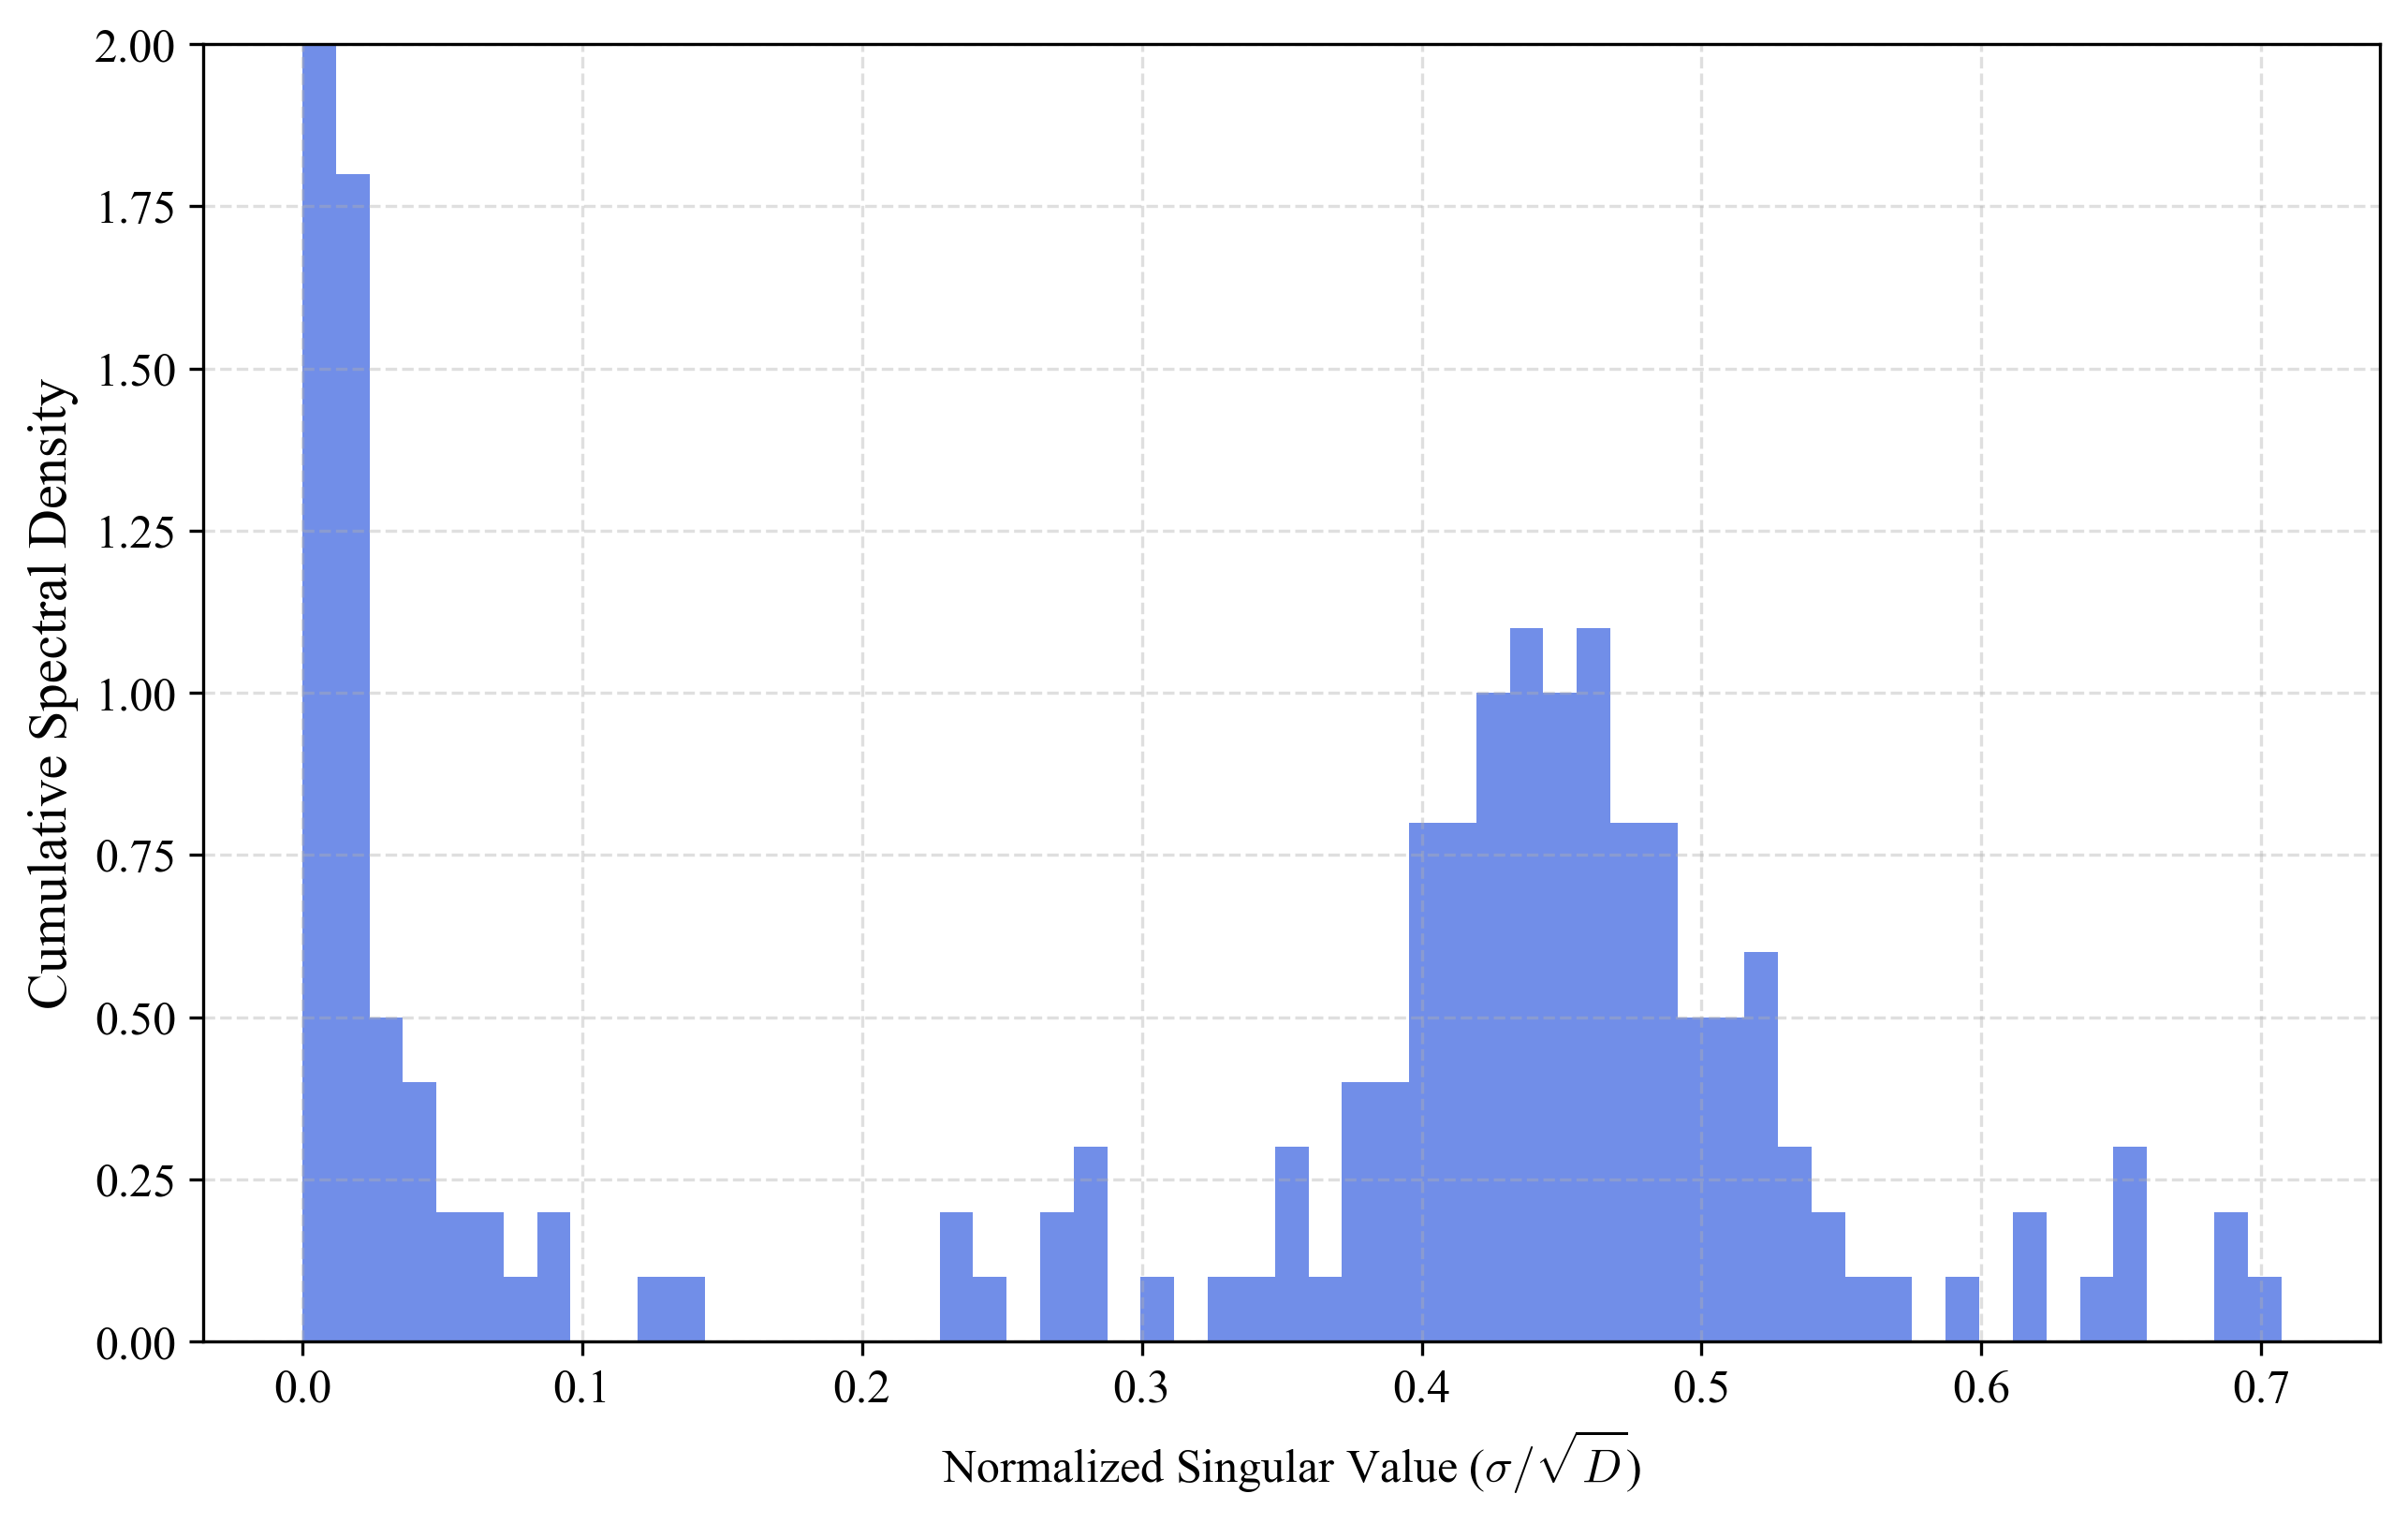

--- File: ../results/run_20251217_0723/heavy_data_13.pkl ---
Saved → ../results/run_20251217_0723/plots/Cumulative_Singular_Spectrum_heavy_data_13.pkl.png



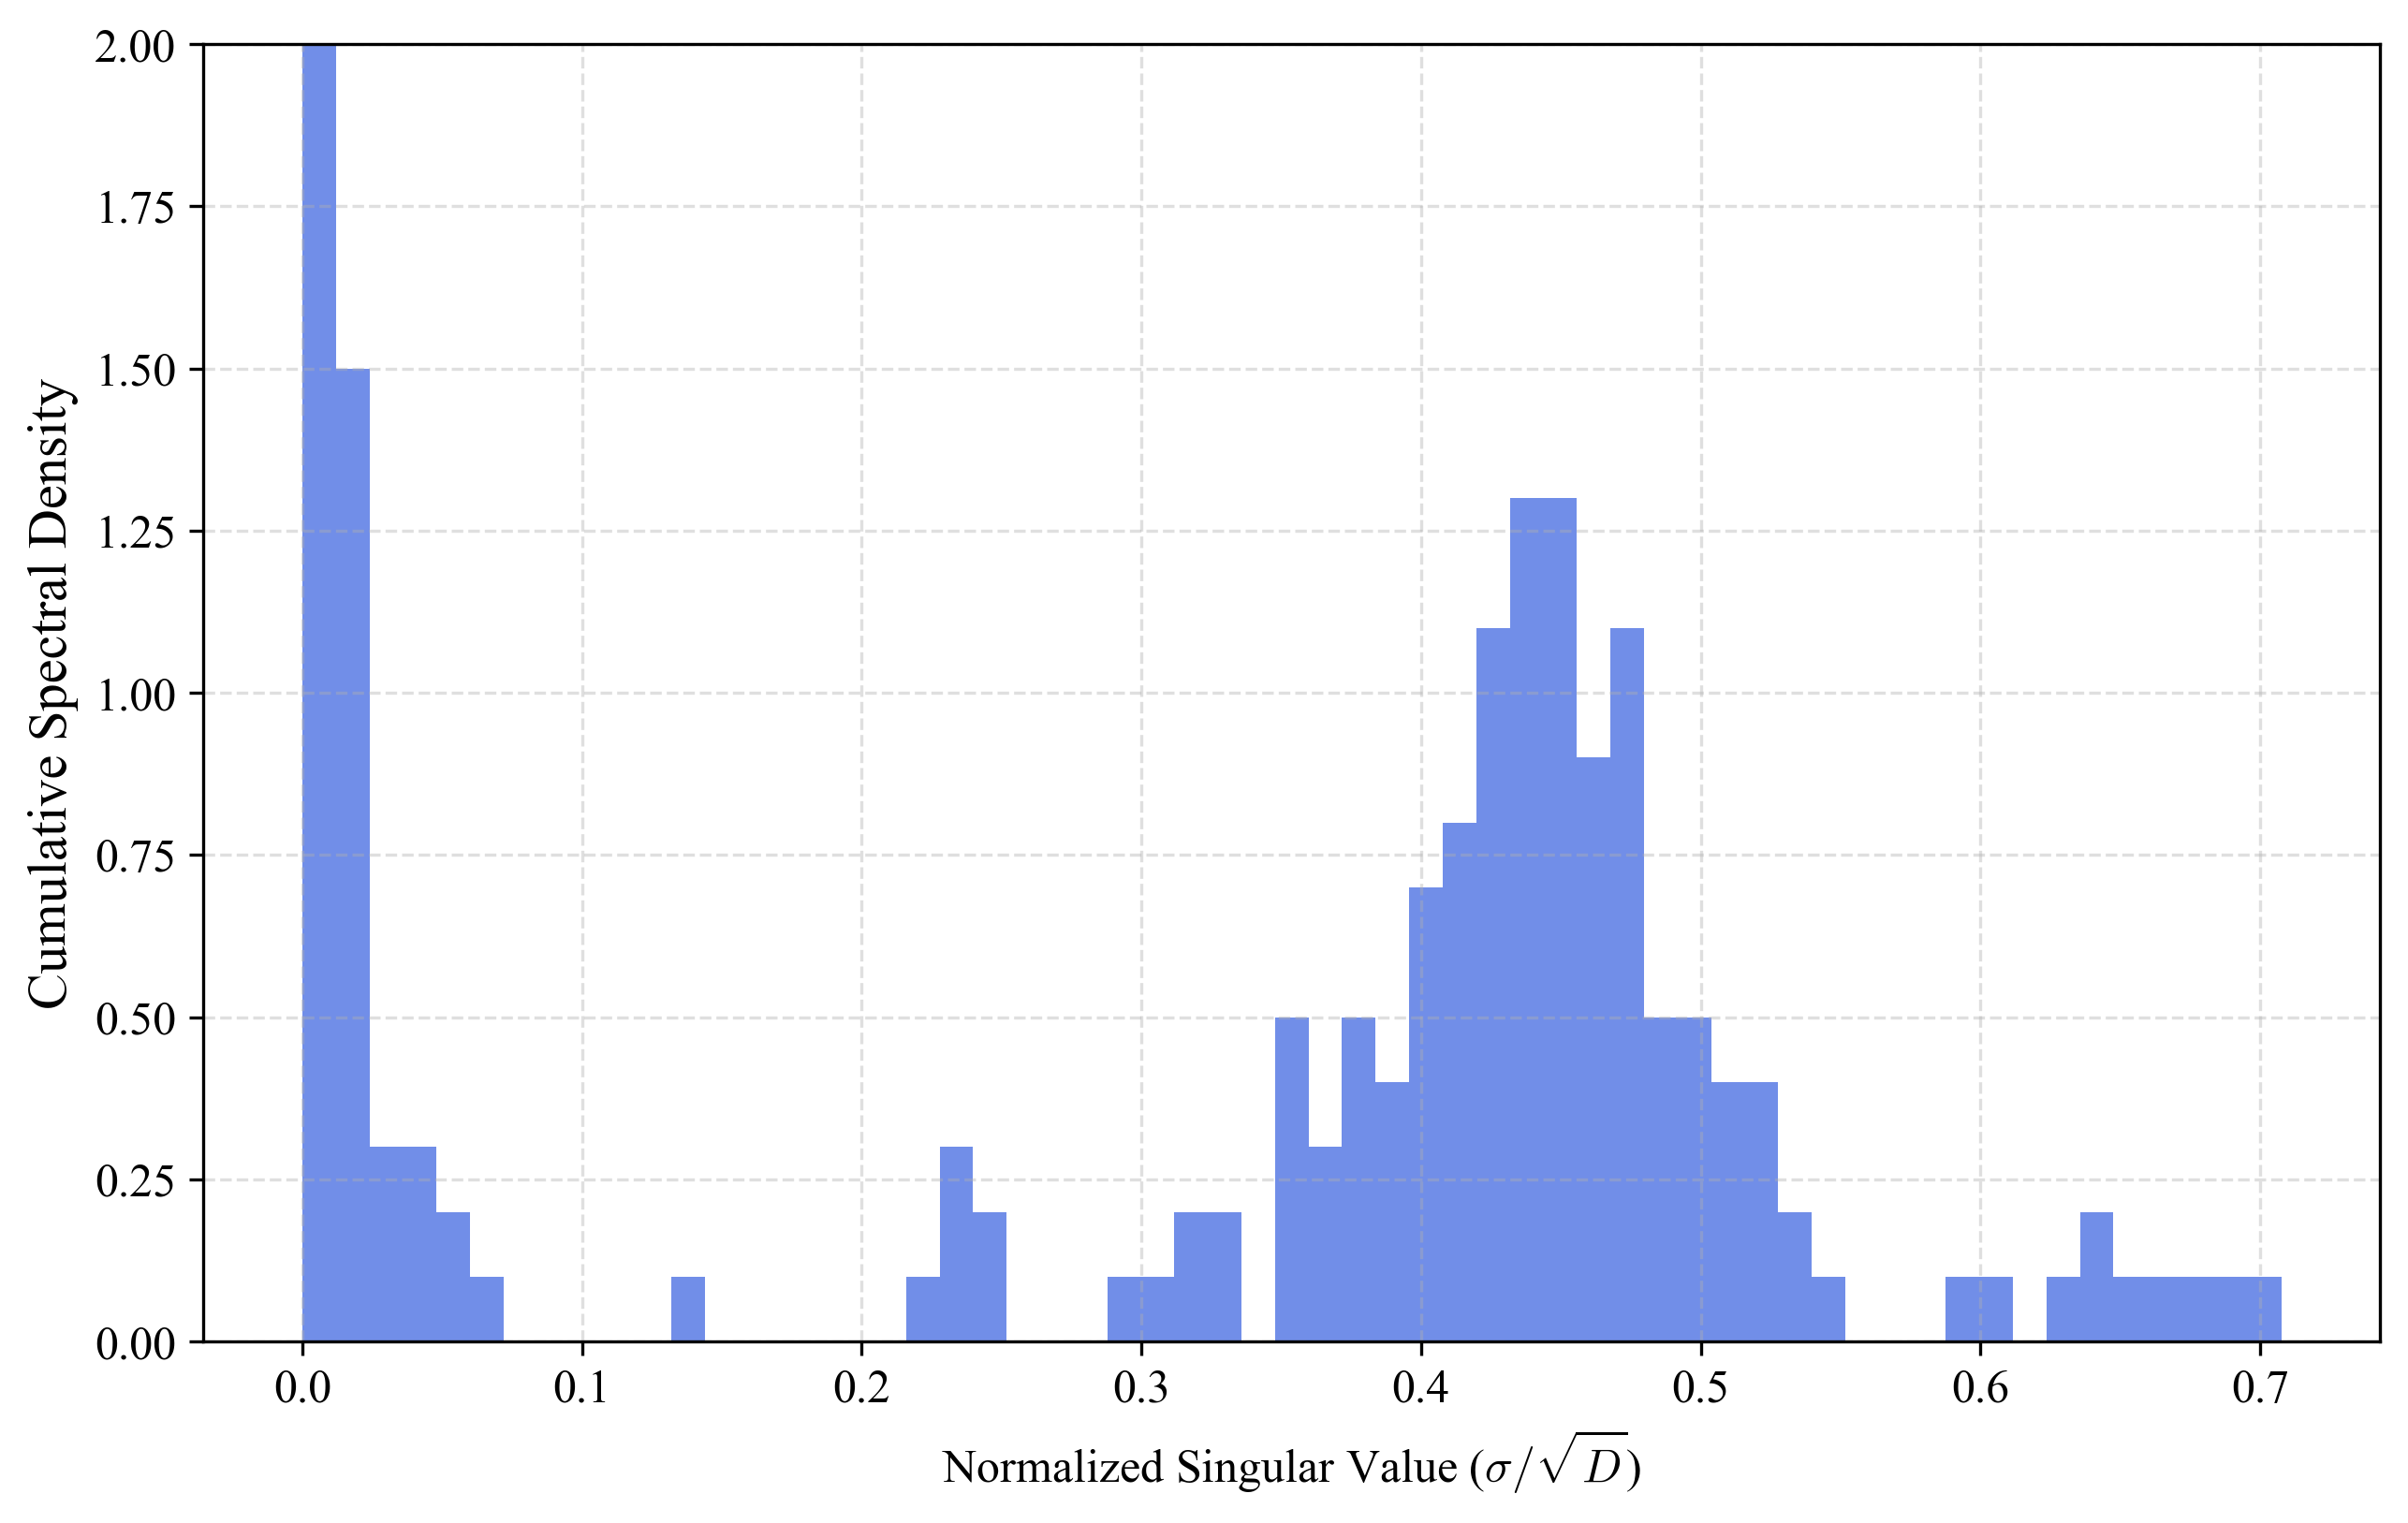

--- File: ../results/run_20251217_0723/heavy_data_14.pkl ---
Saved → ../results/run_20251217_0723/plots/Cumulative_Singular_Spectrum_heavy_data_14.pkl.png



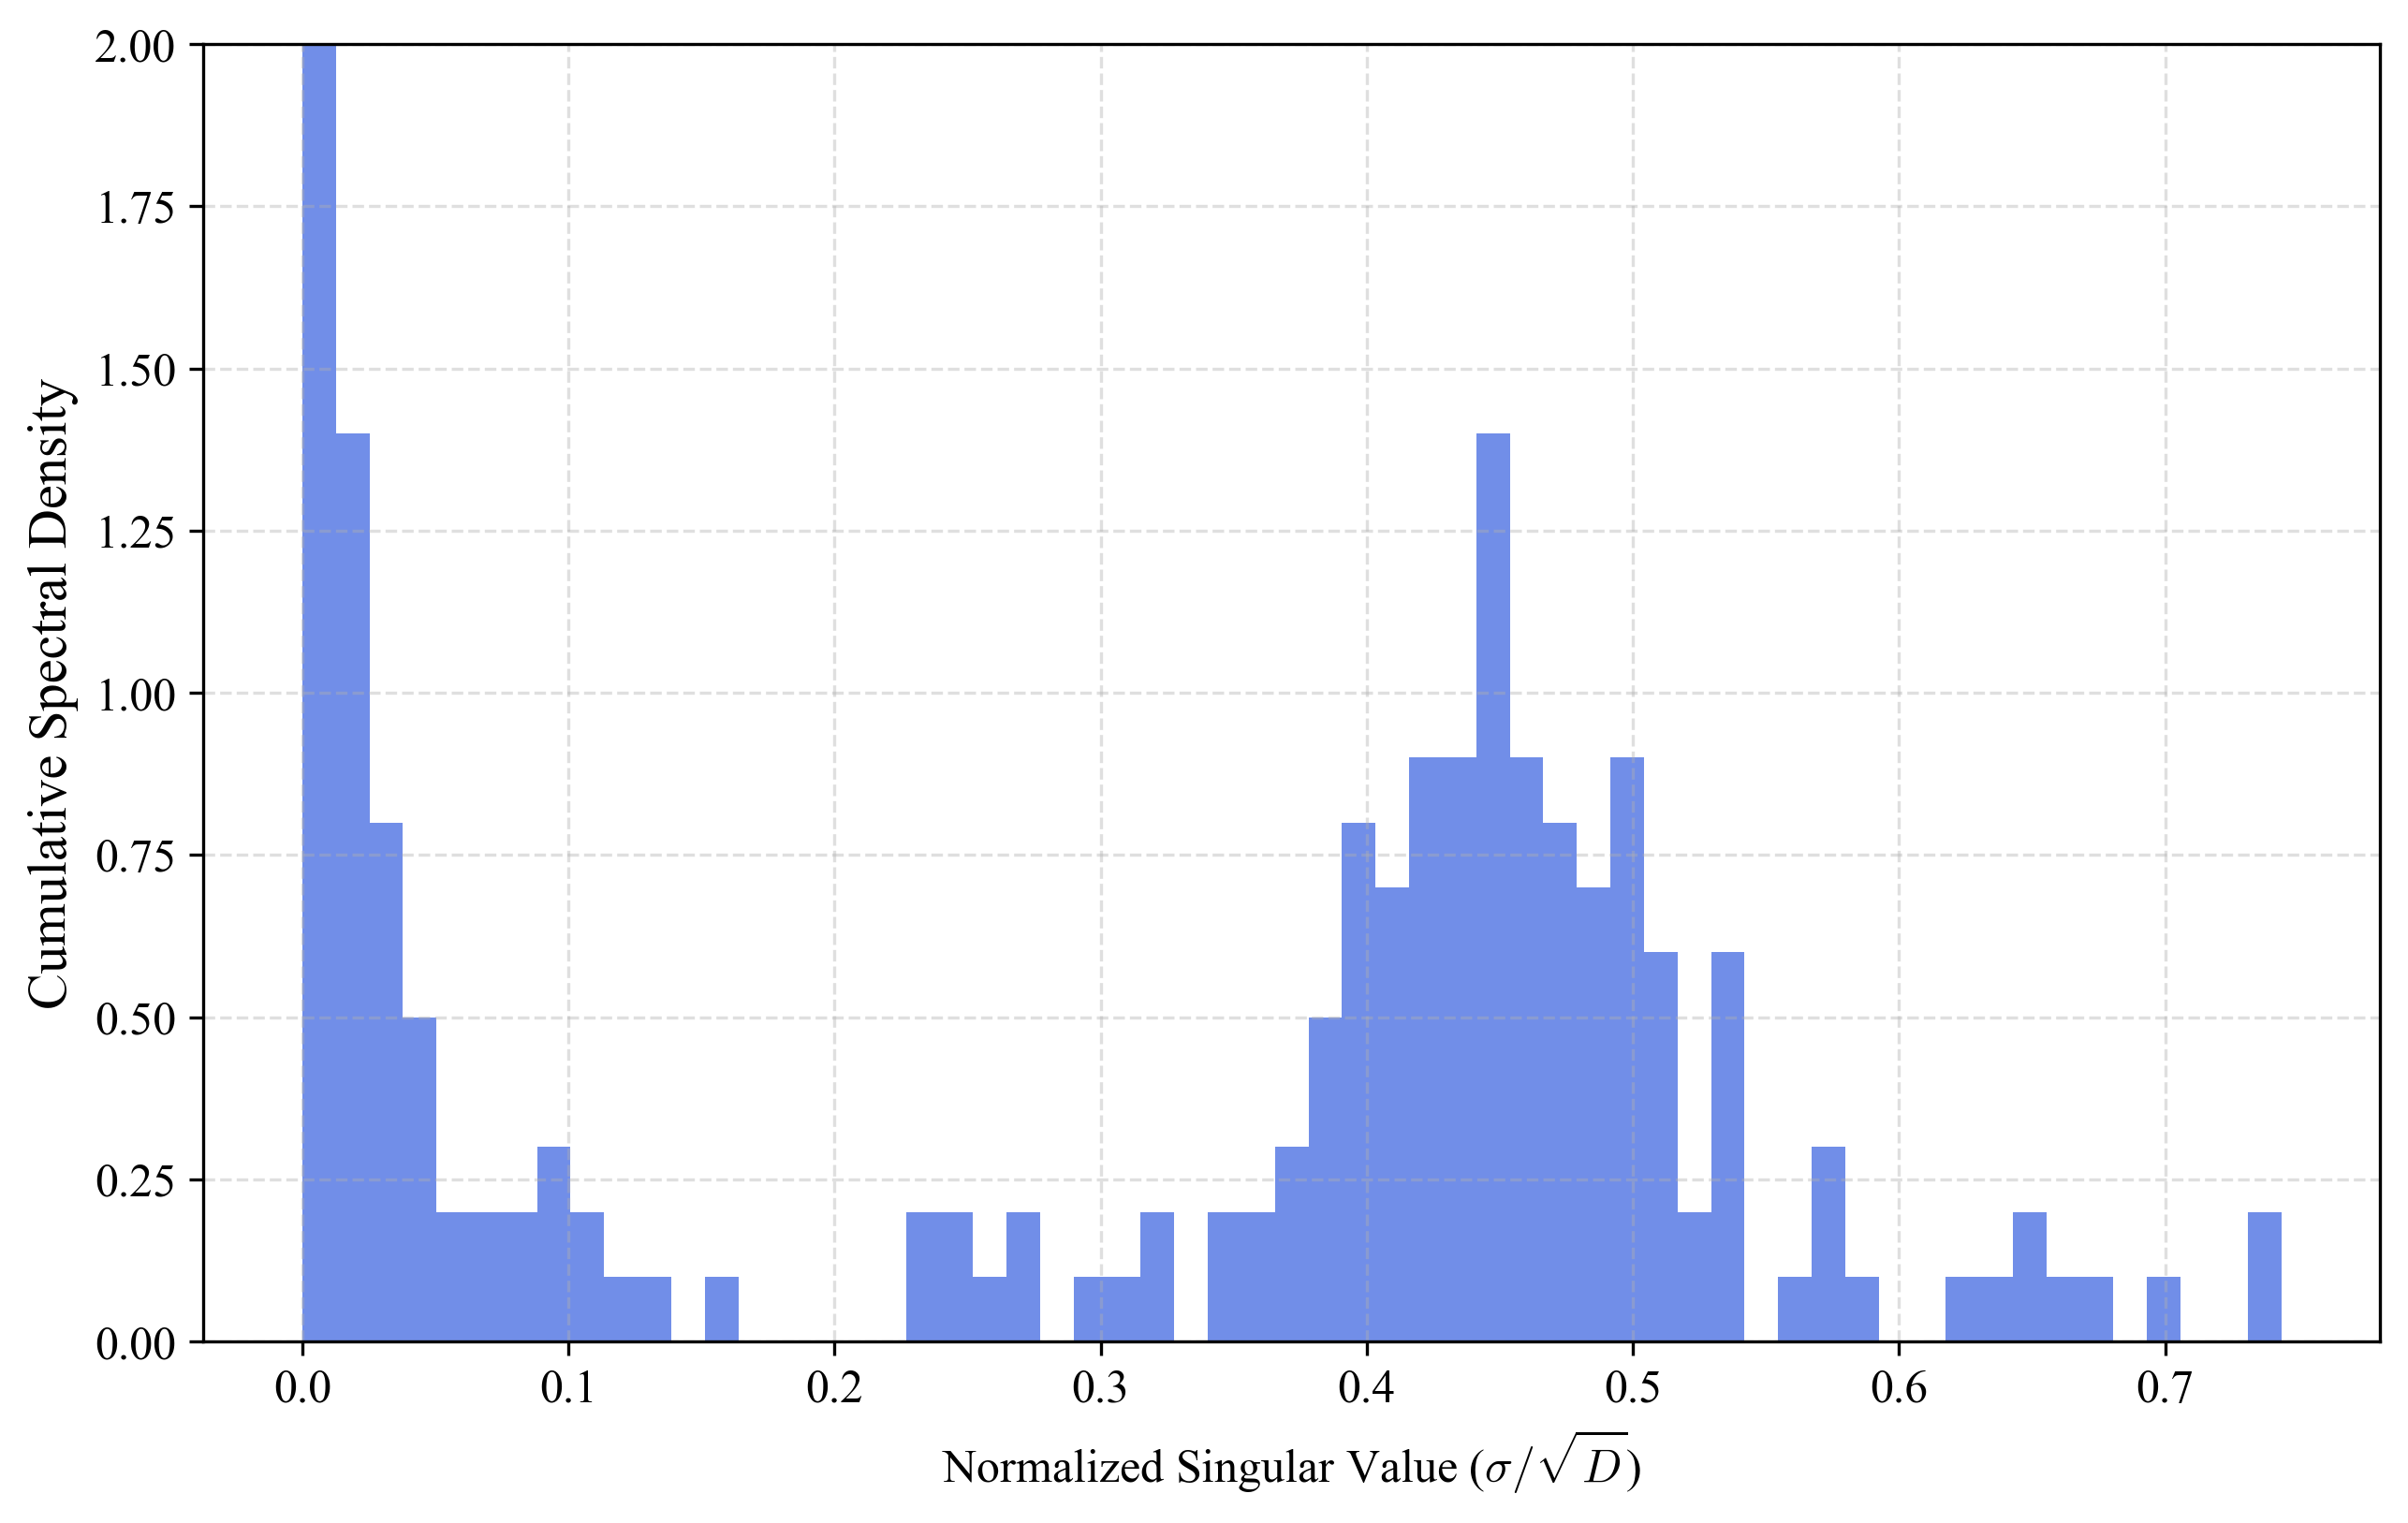

--- File: ../results/run_20251217_0723/heavy_data_2.pkl ---
Saved → ../results/run_20251217_0723/plots/Cumulative_Singular_Spectrum_heavy_data_2.pkl.png



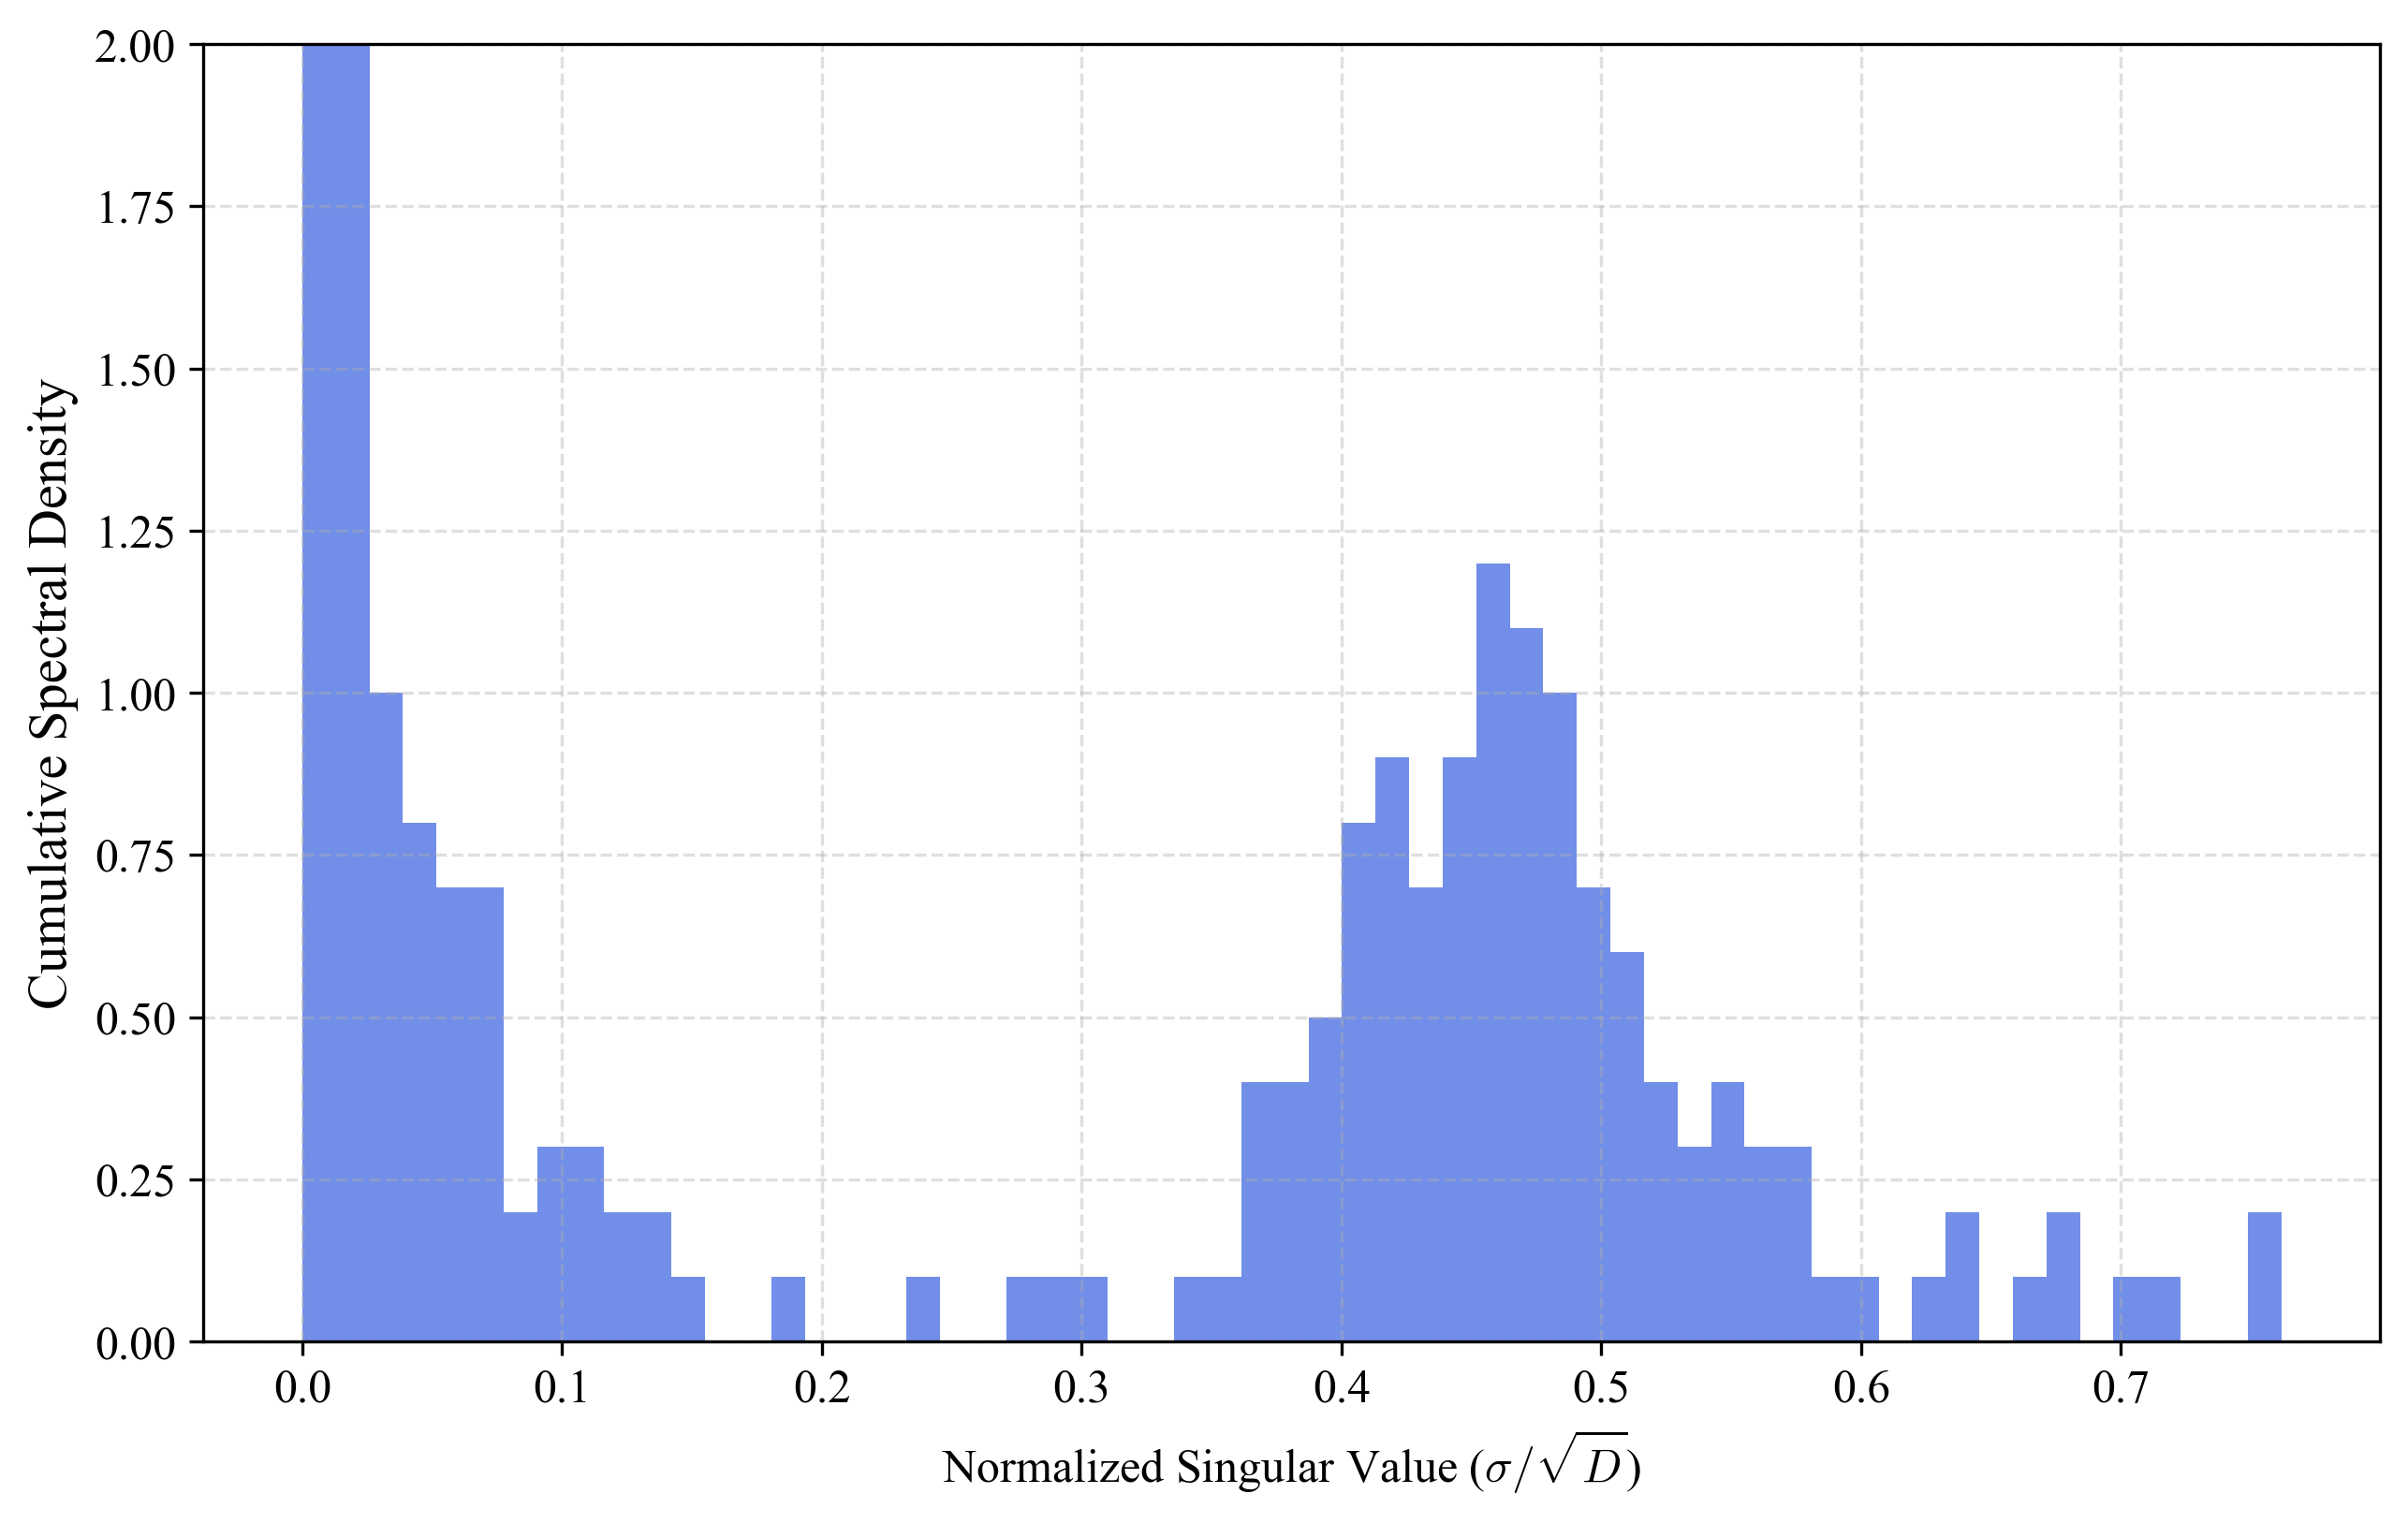

--- File: ../results/run_20251217_0723/heavy_data_3.pkl ---
Saved → ../results/run_20251217_0723/plots/Cumulative_Singular_Spectrum_heavy_data_3.pkl.png



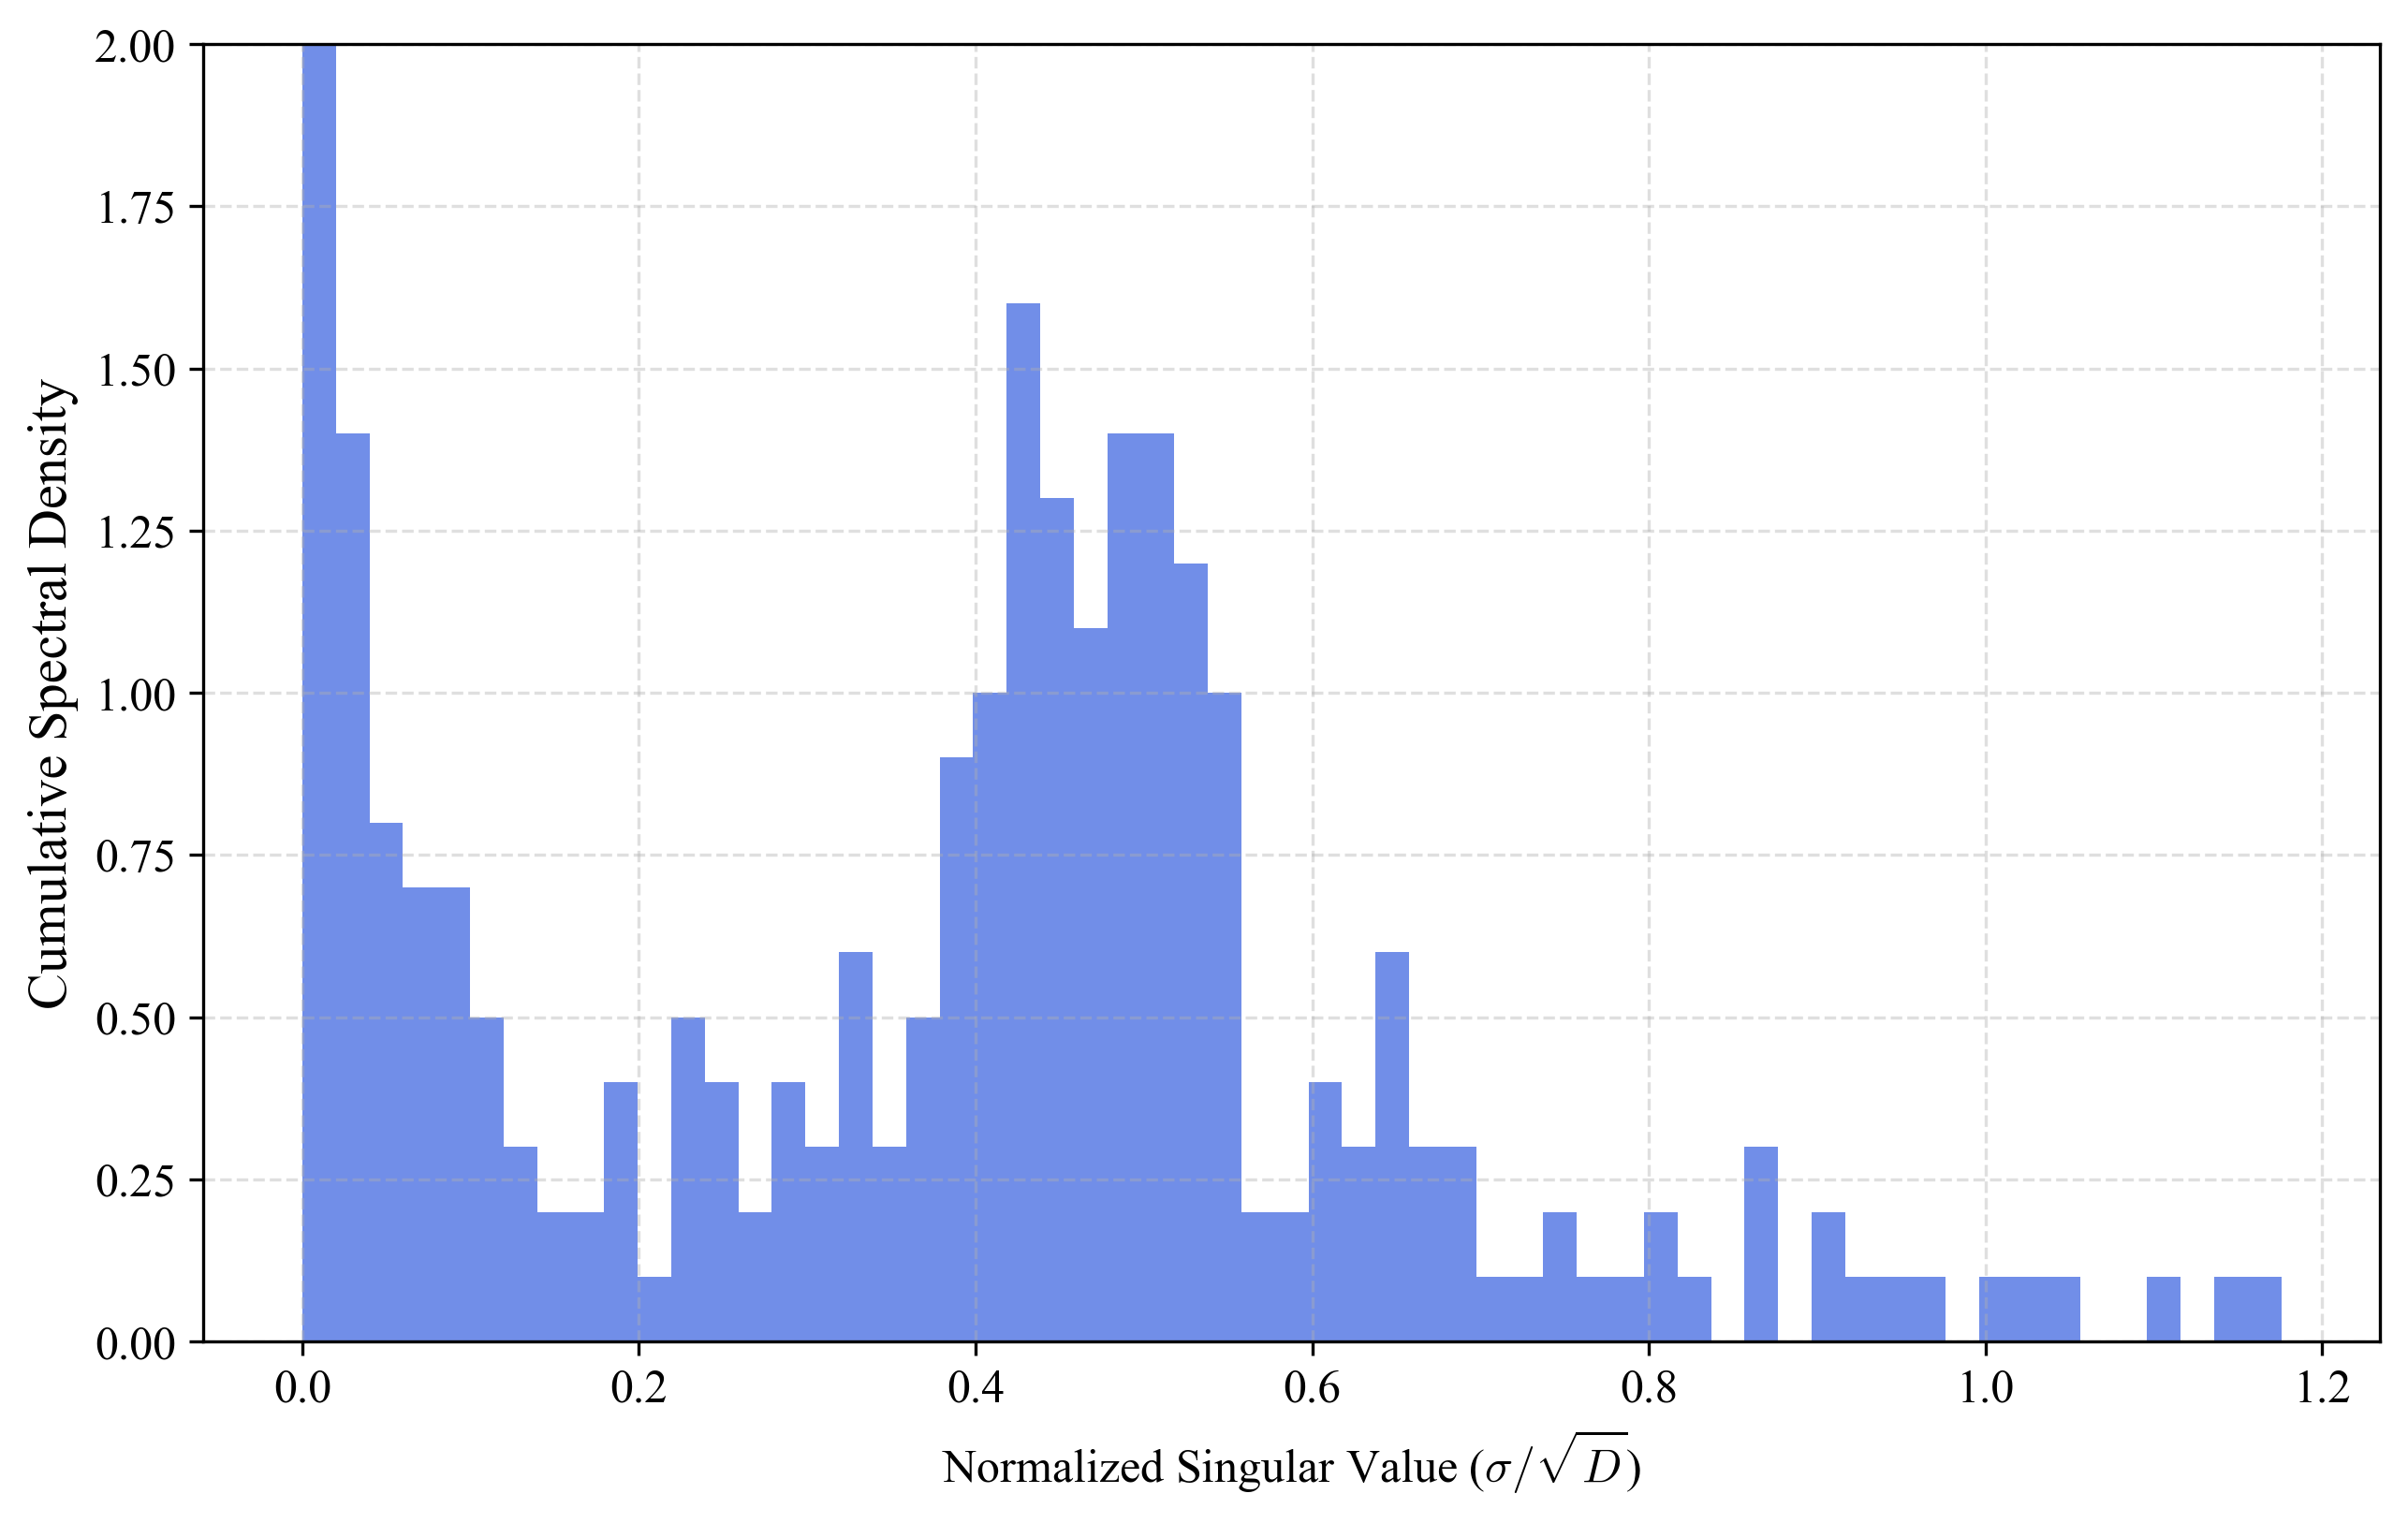

--- File: ../results/run_20251217_0723/heavy_data_4.pkl ---
Saved → ../results/run_20251217_0723/plots/Cumulative_Singular_Spectrum_heavy_data_4.pkl.png



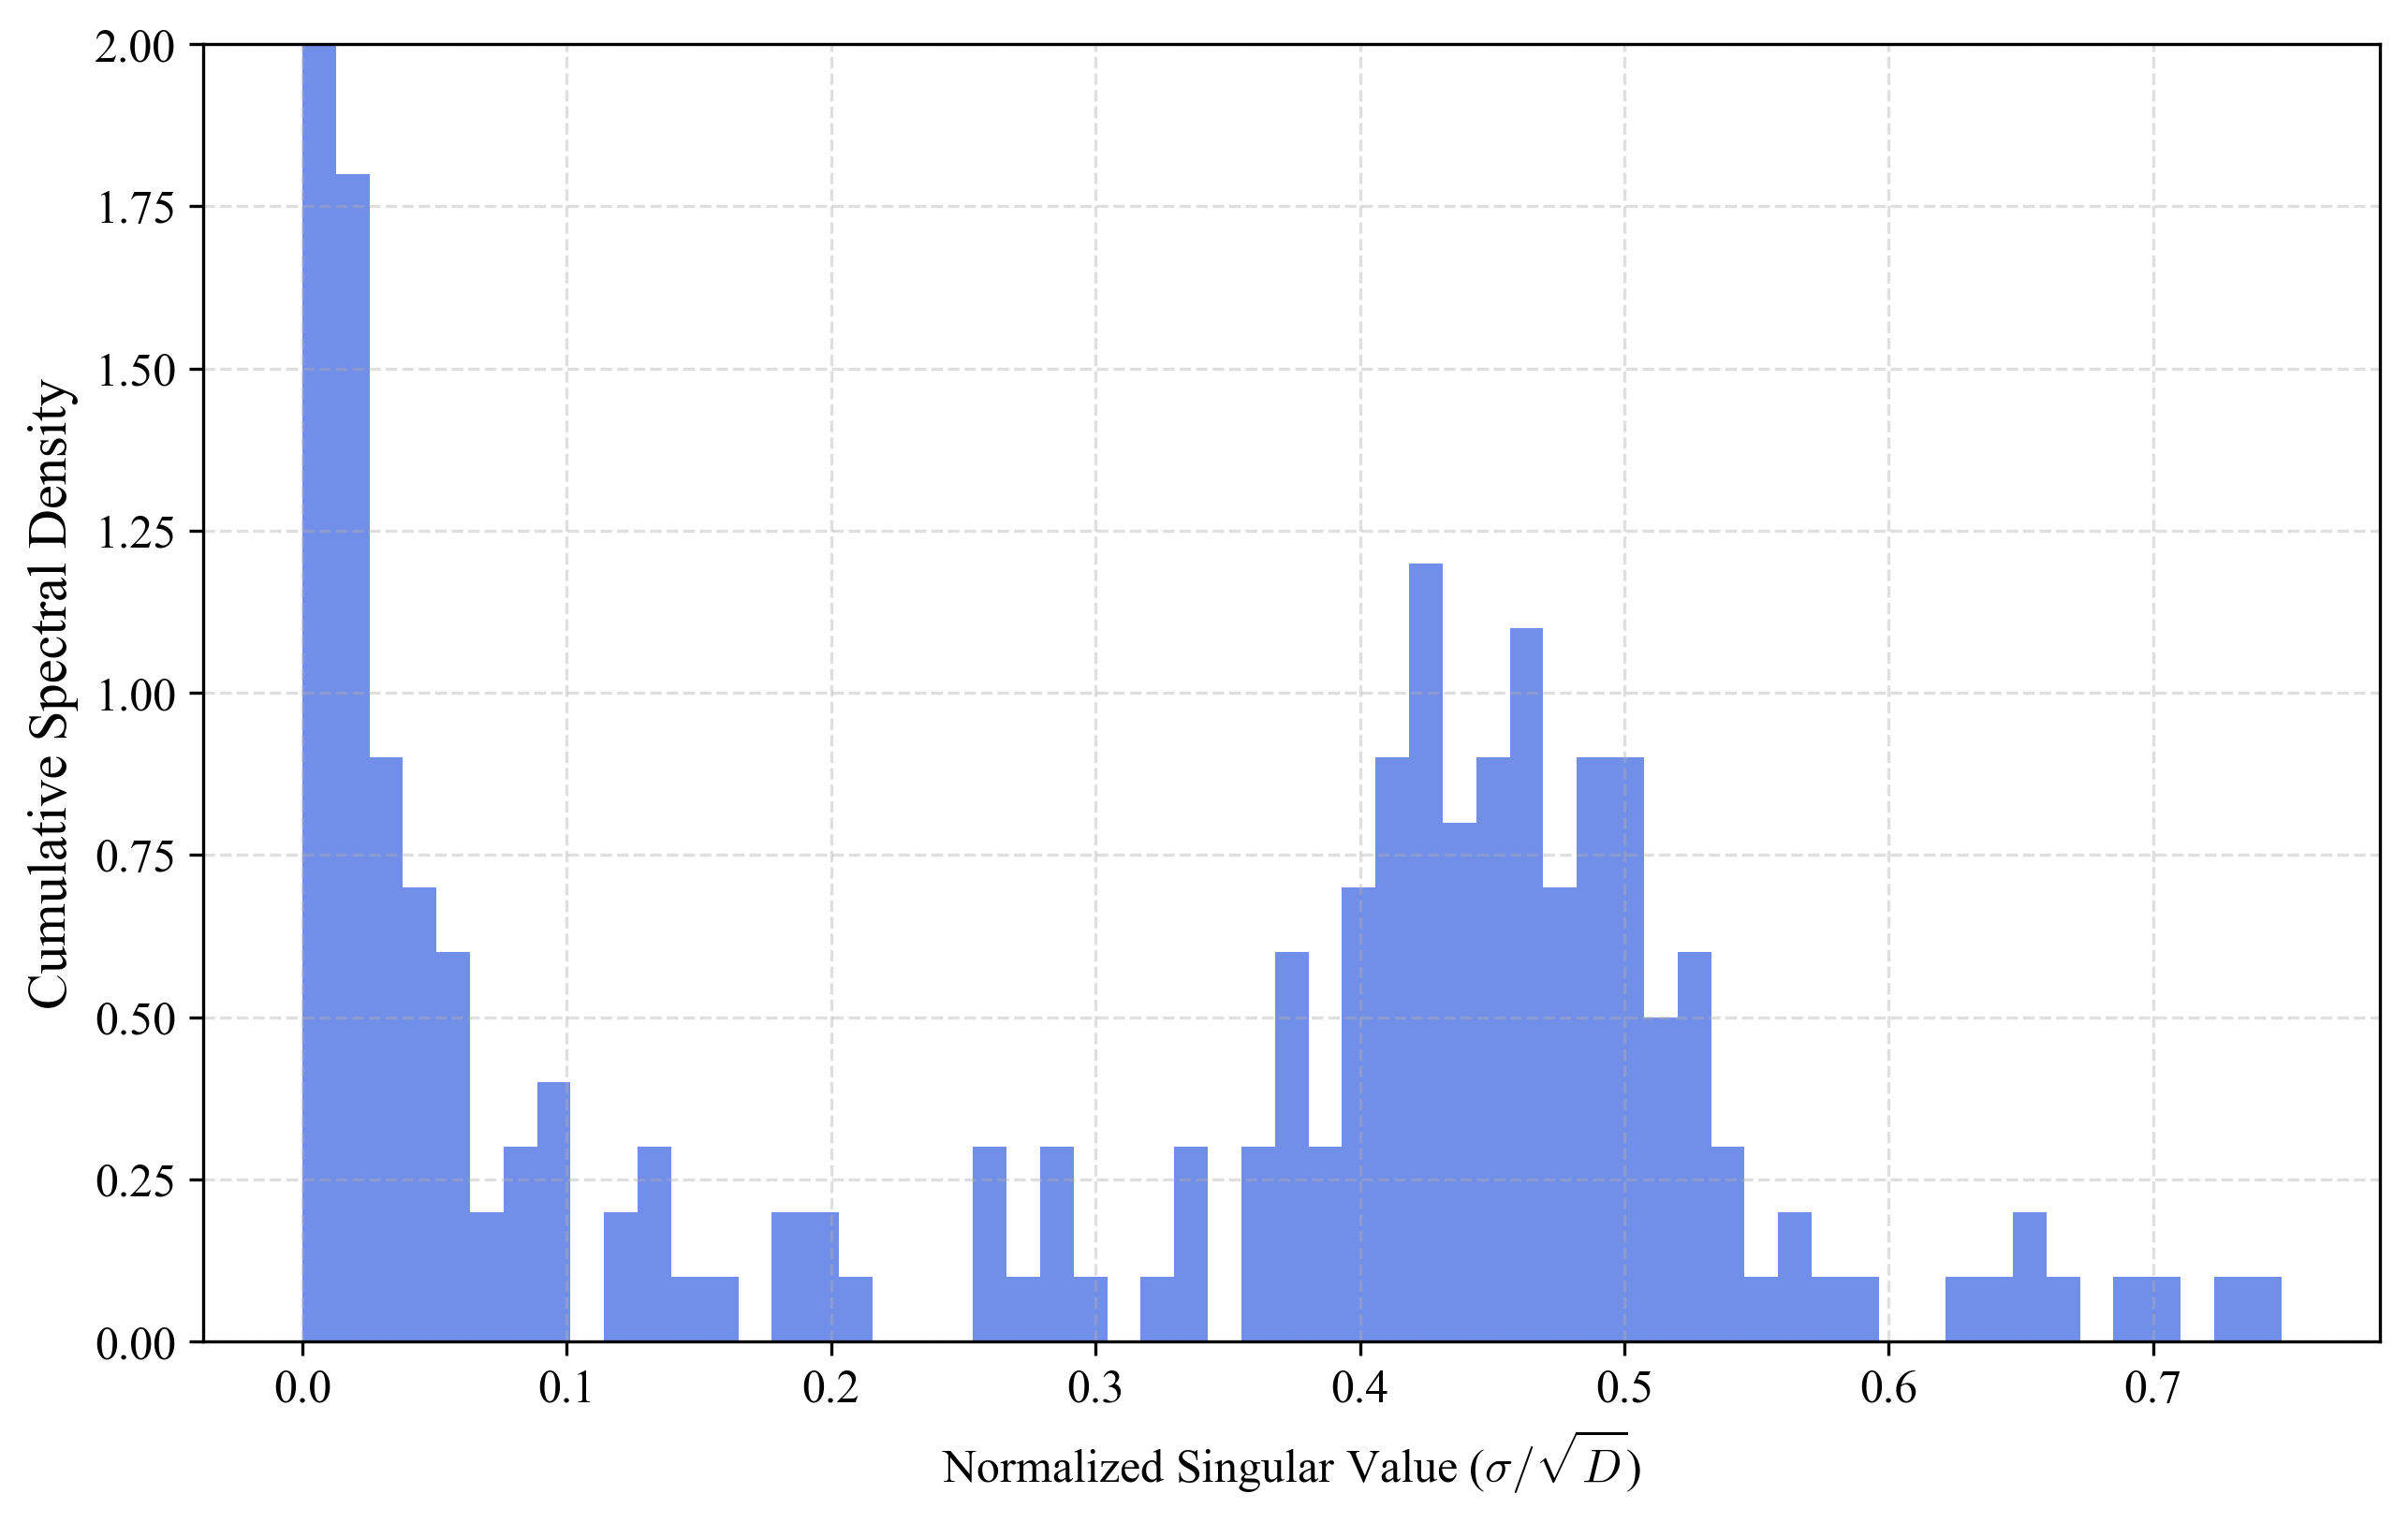

--- File: ../results/run_20251217_0723/heavy_data_5.pkl ---
Saved → ../results/run_20251217_0723/plots/Cumulative_Singular_Spectrum_heavy_data_5.pkl.png



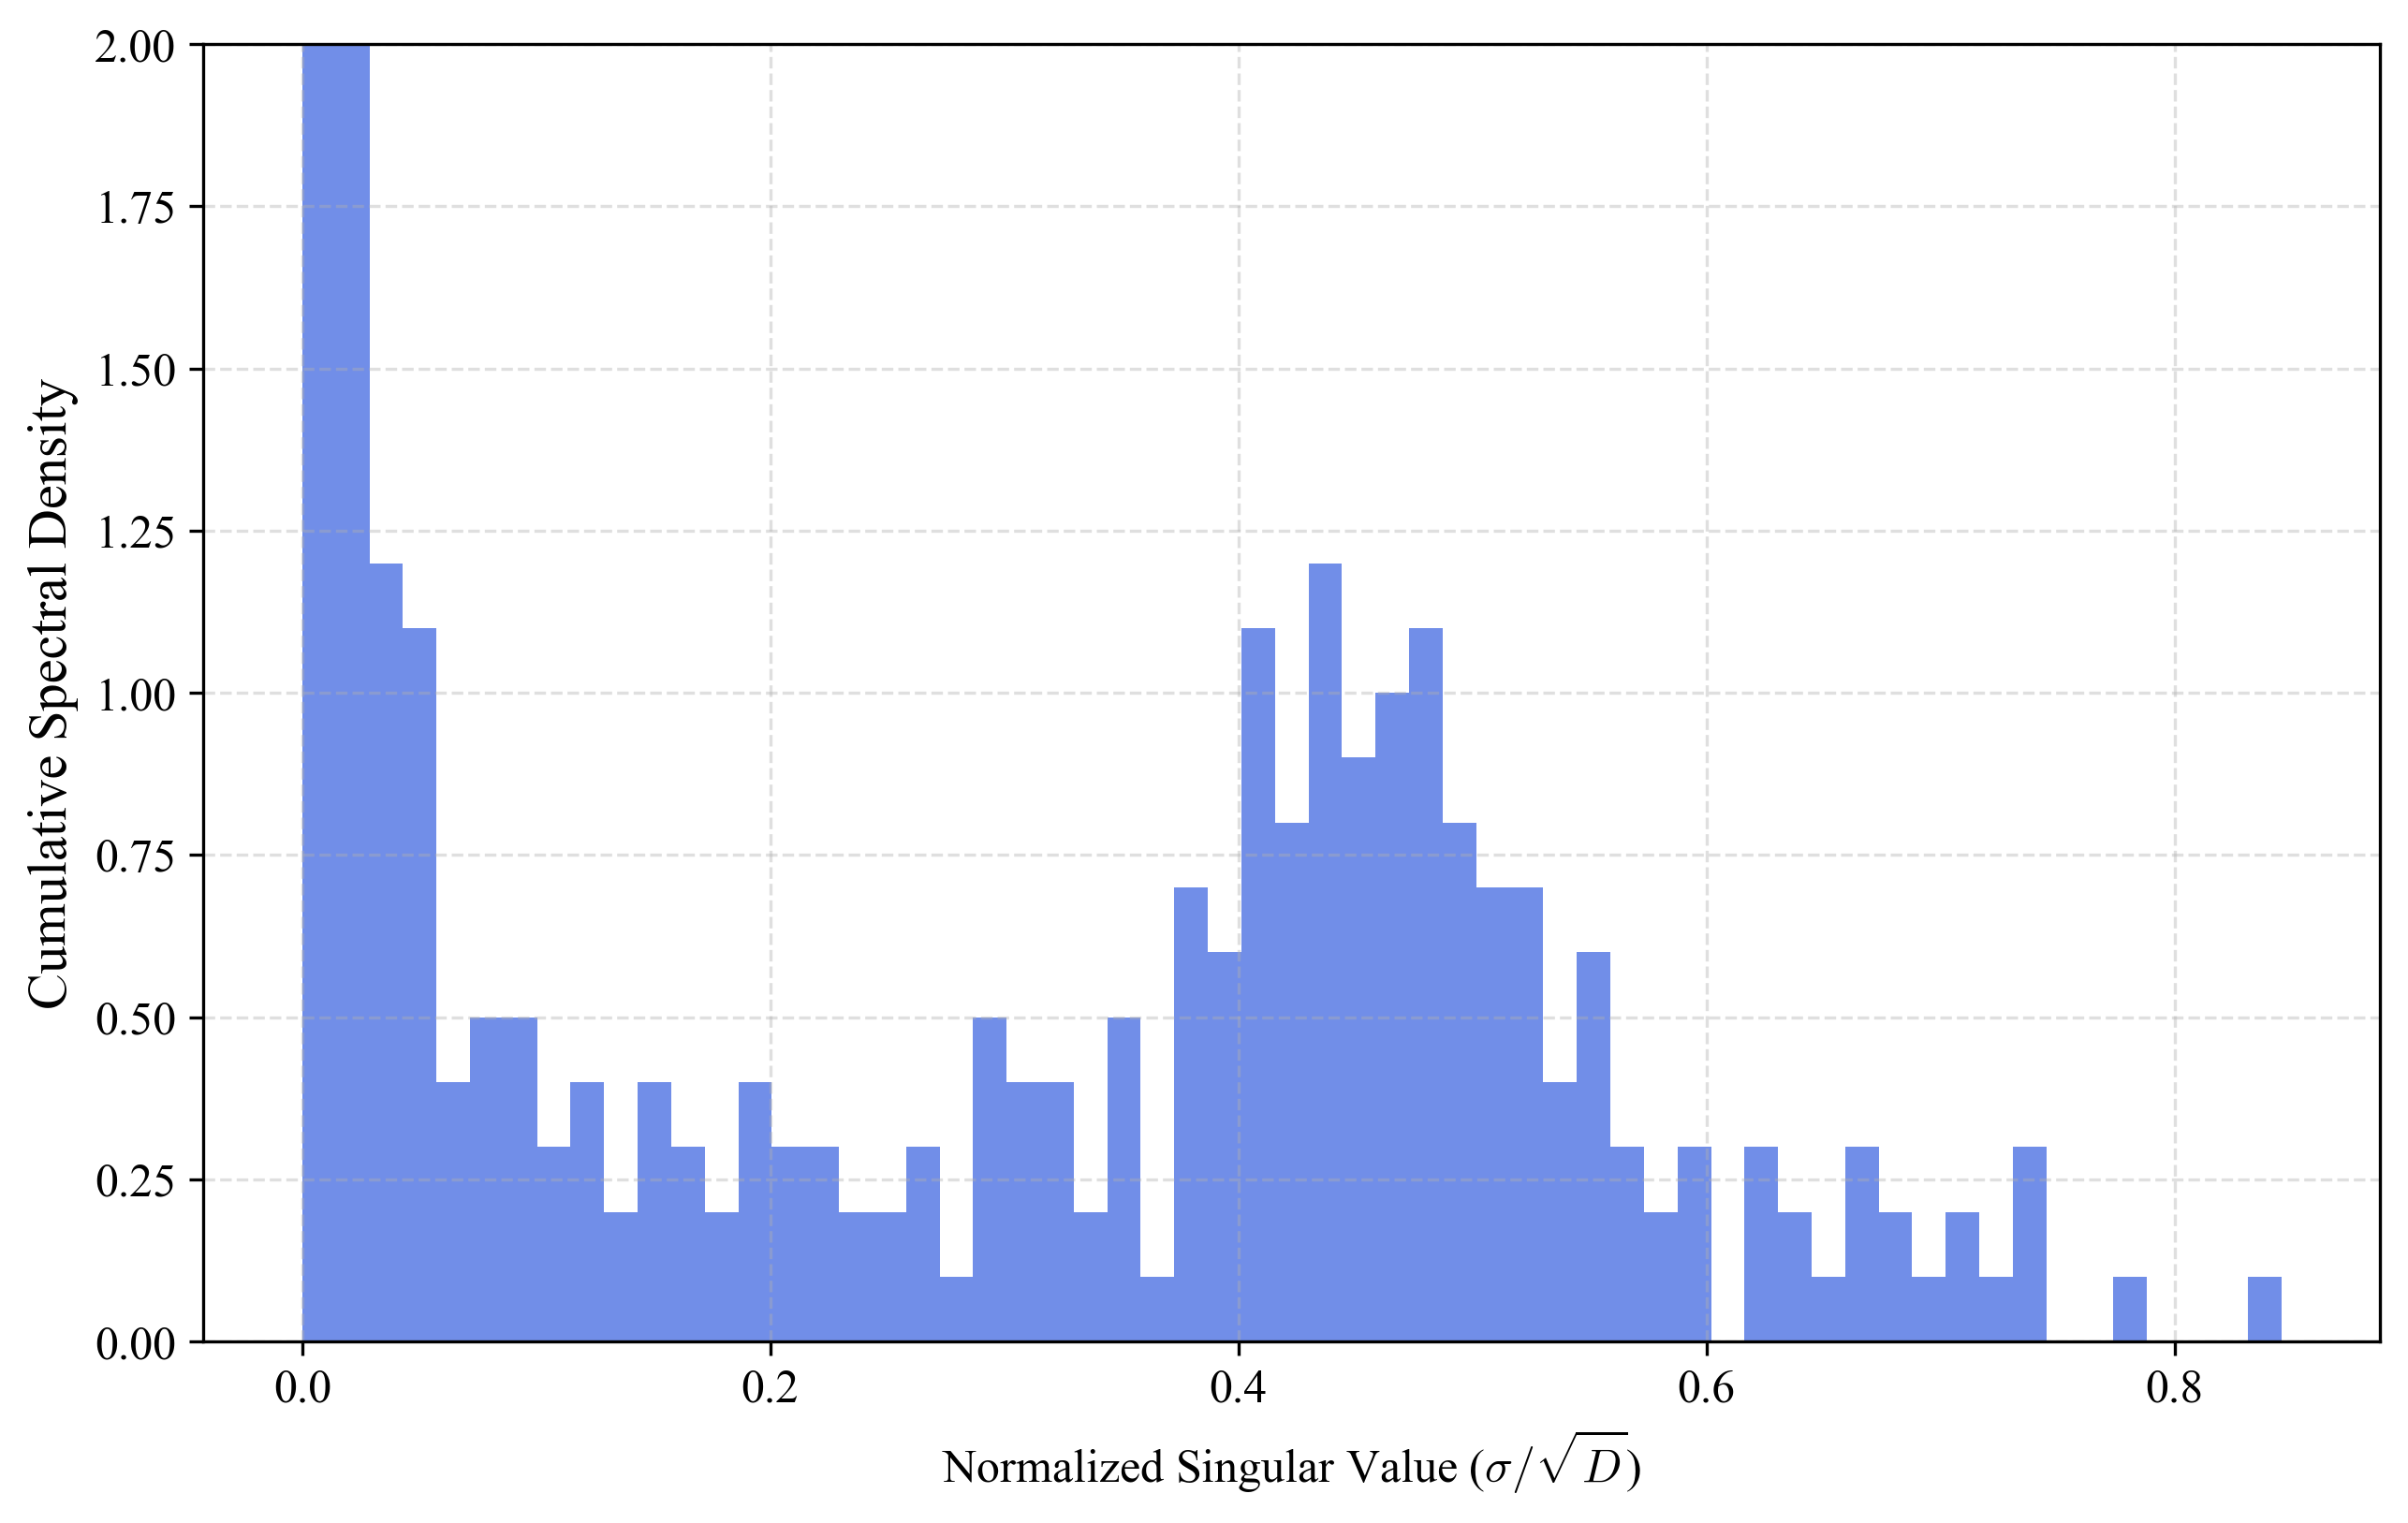

--- File: ../results/run_20251217_0723/heavy_data_6.pkl ---
Saved → ../results/run_20251217_0723/plots/Cumulative_Singular_Spectrum_heavy_data_6.pkl.png



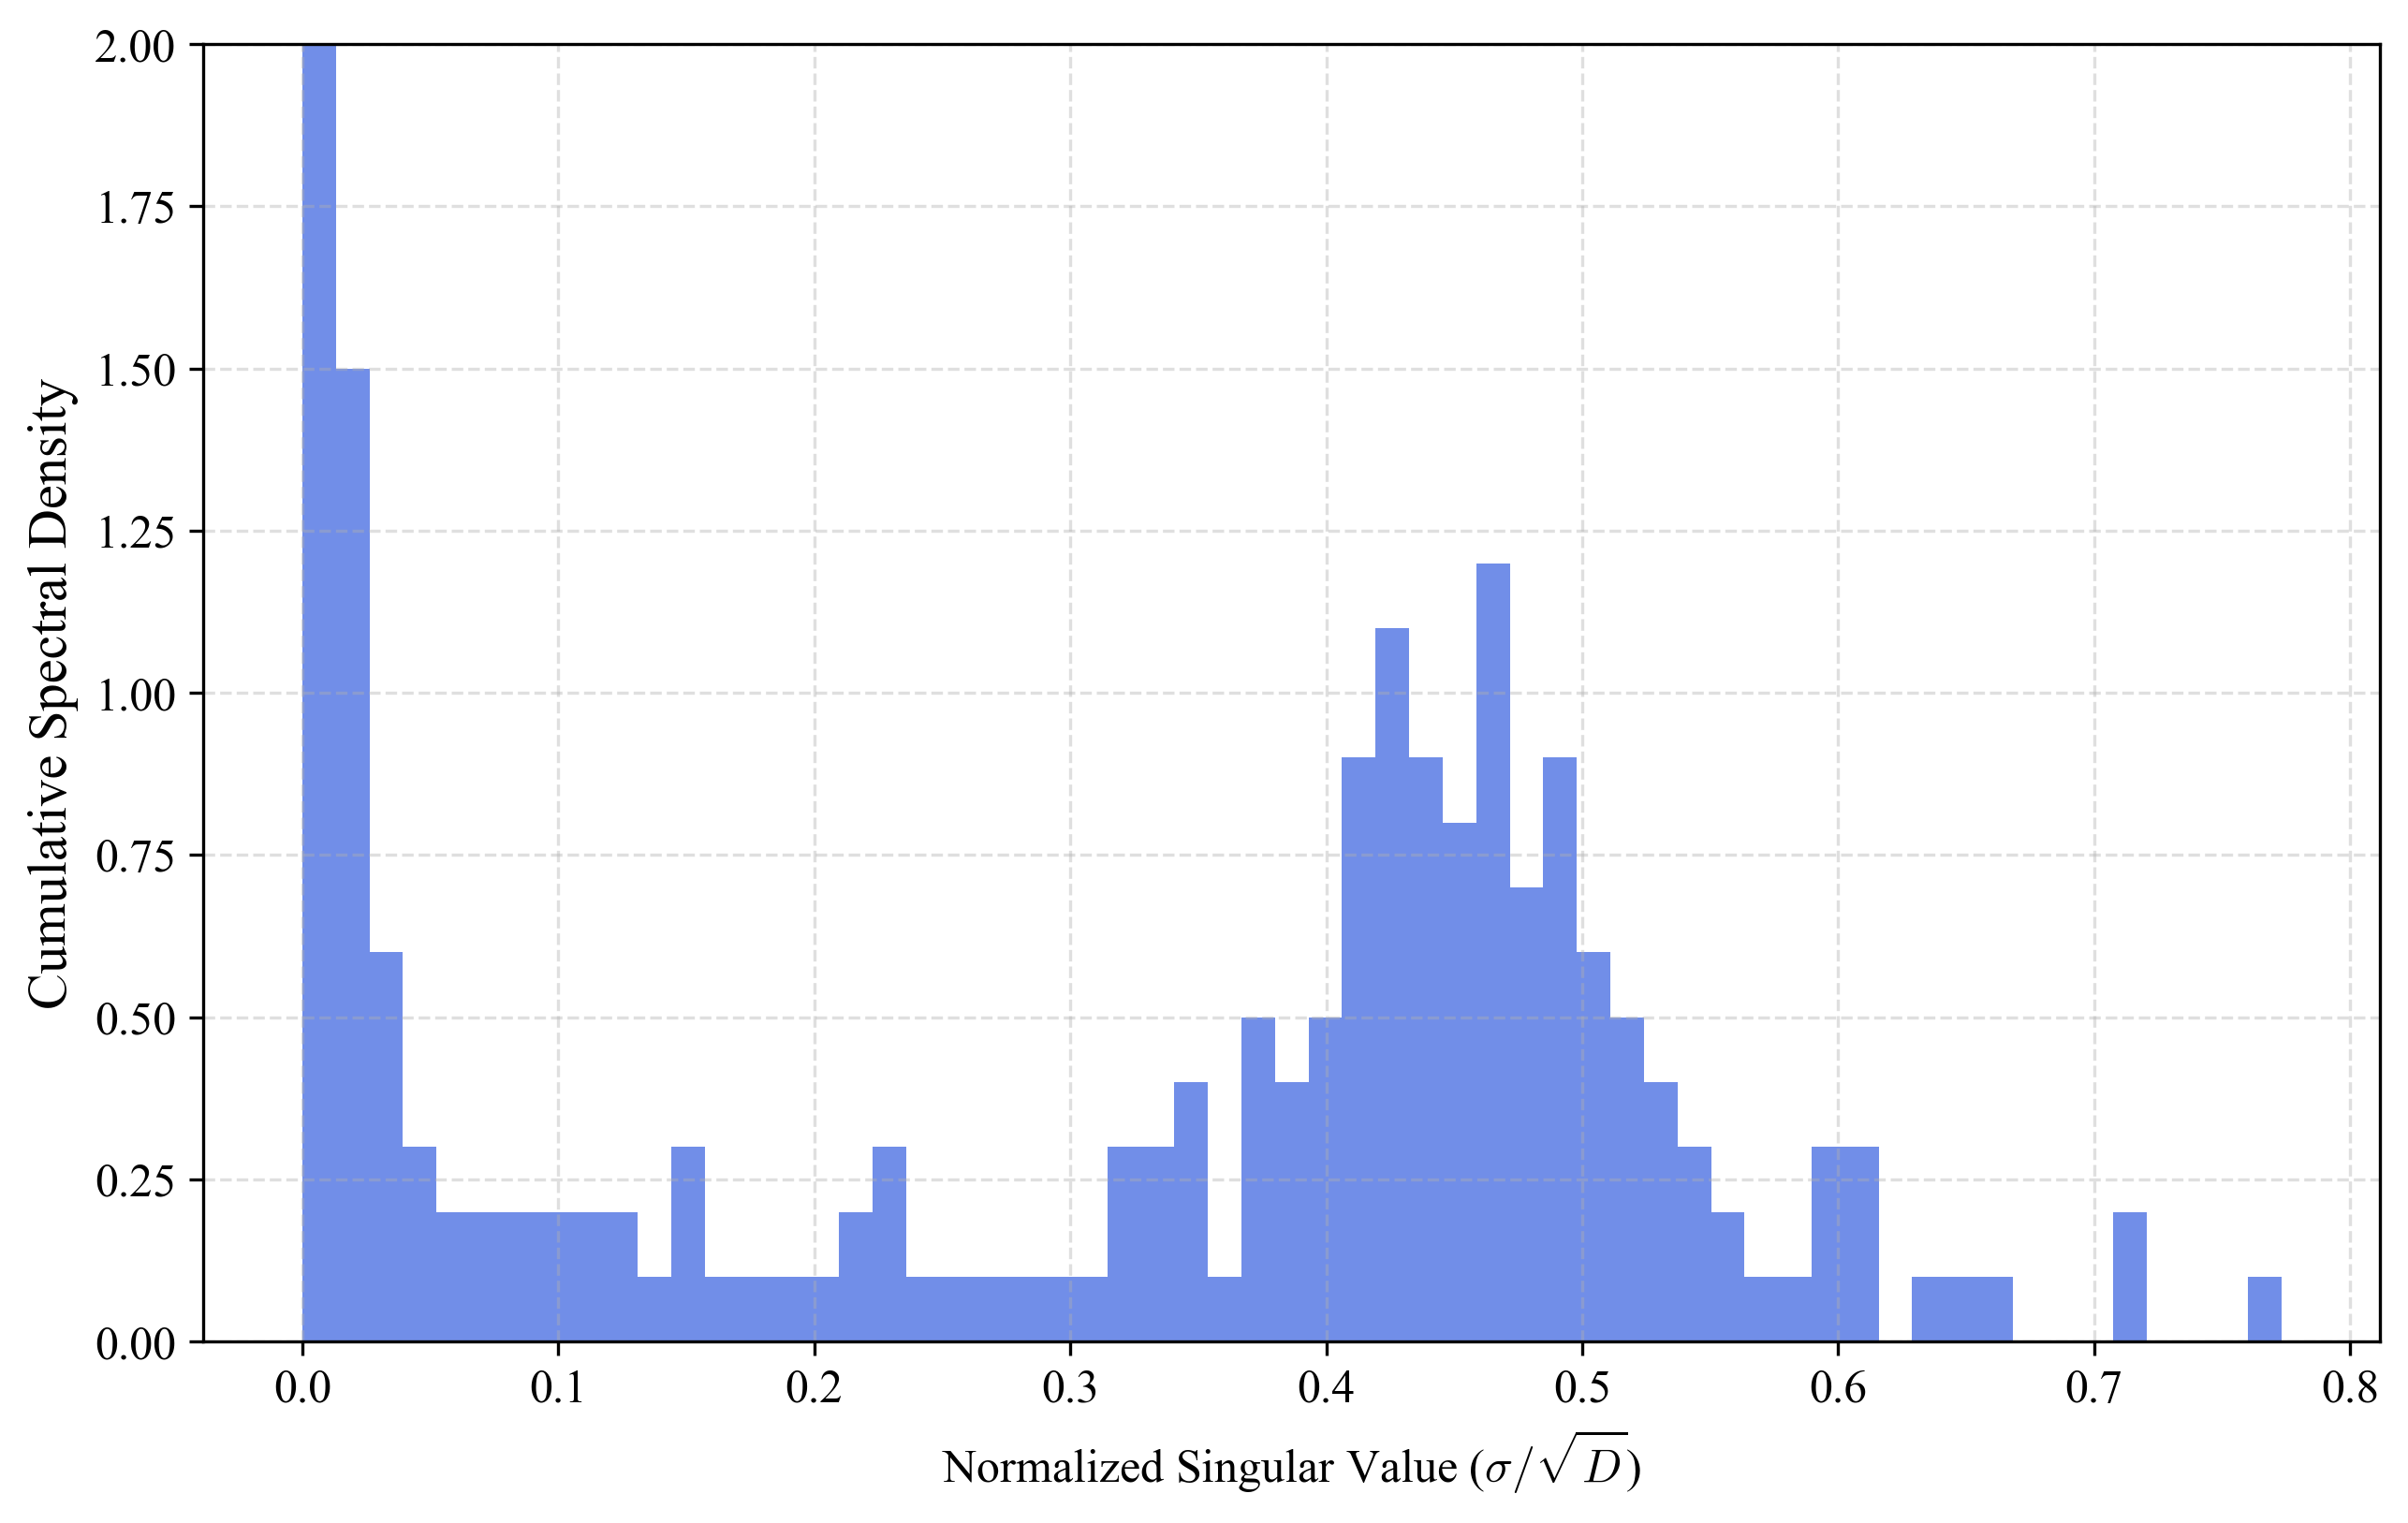

--- File: ../results/run_20251217_0723/heavy_data_7.pkl ---
Saved → ../results/run_20251217_0723/plots/Cumulative_Singular_Spectrum_heavy_data_7.pkl.png



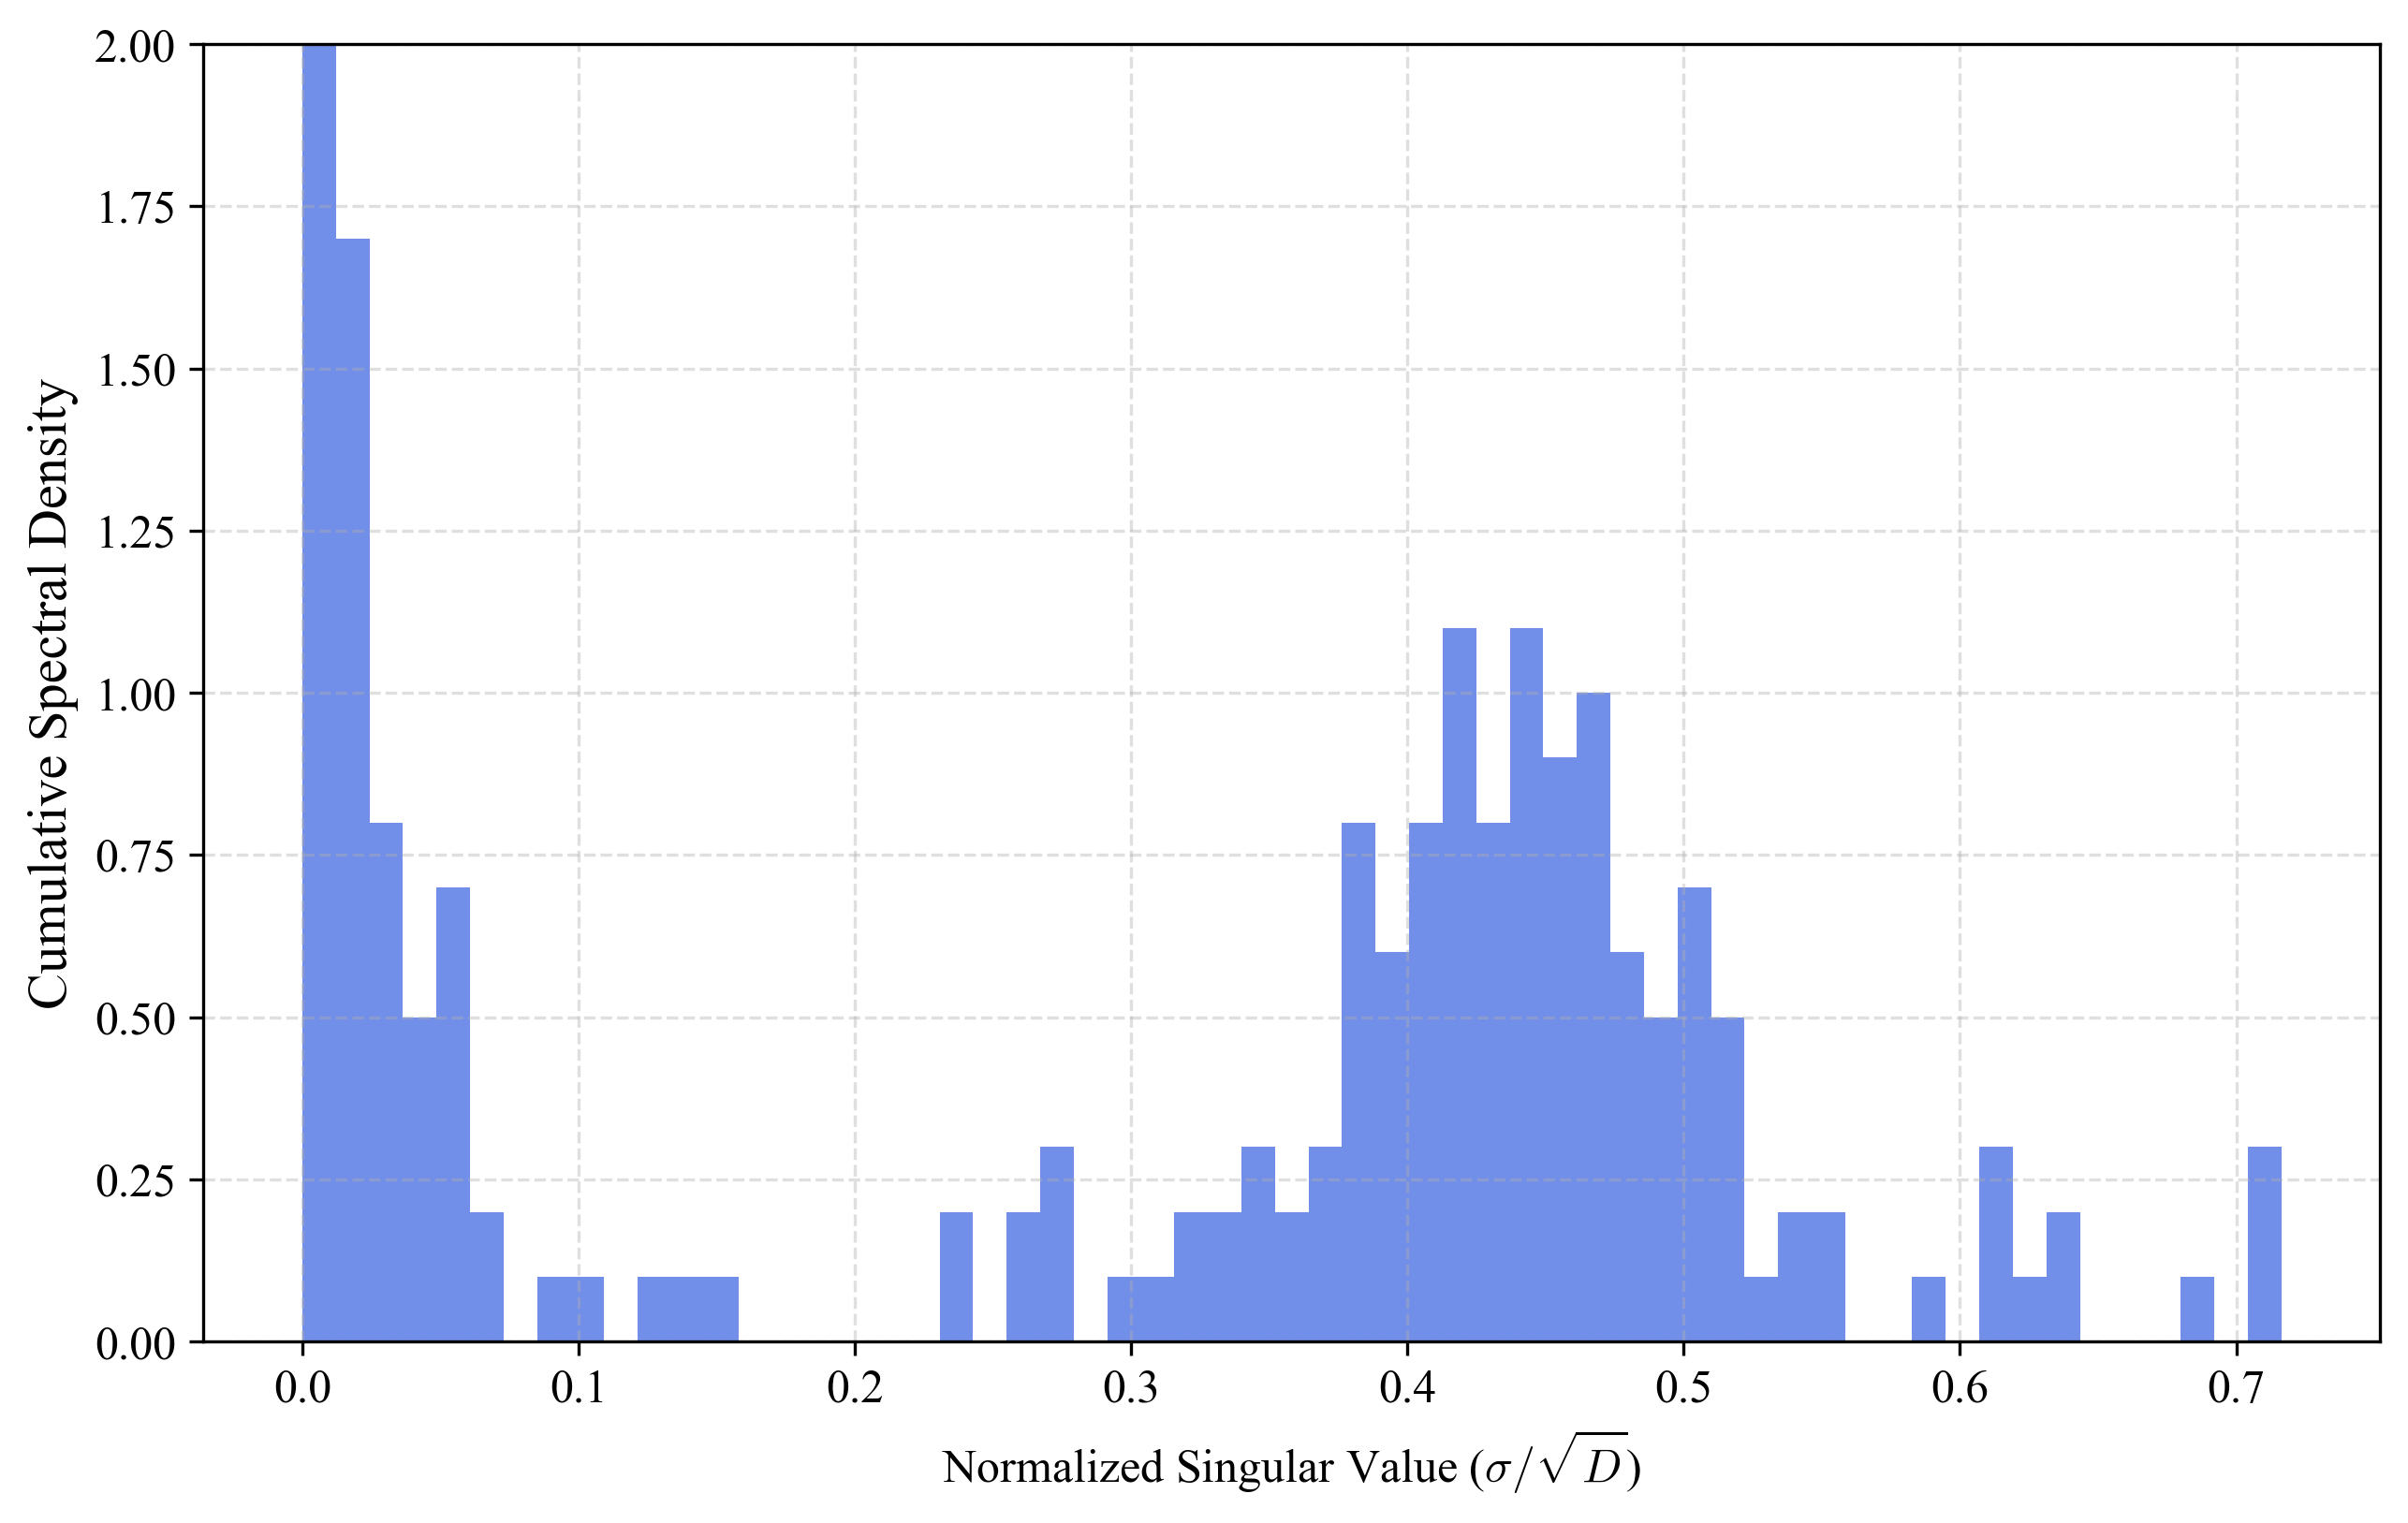

--- File: ../results/run_20251217_0723/heavy_data_8.pkl ---
Saved → ../results/run_20251217_0723/plots/Cumulative_Singular_Spectrum_heavy_data_8.pkl.png



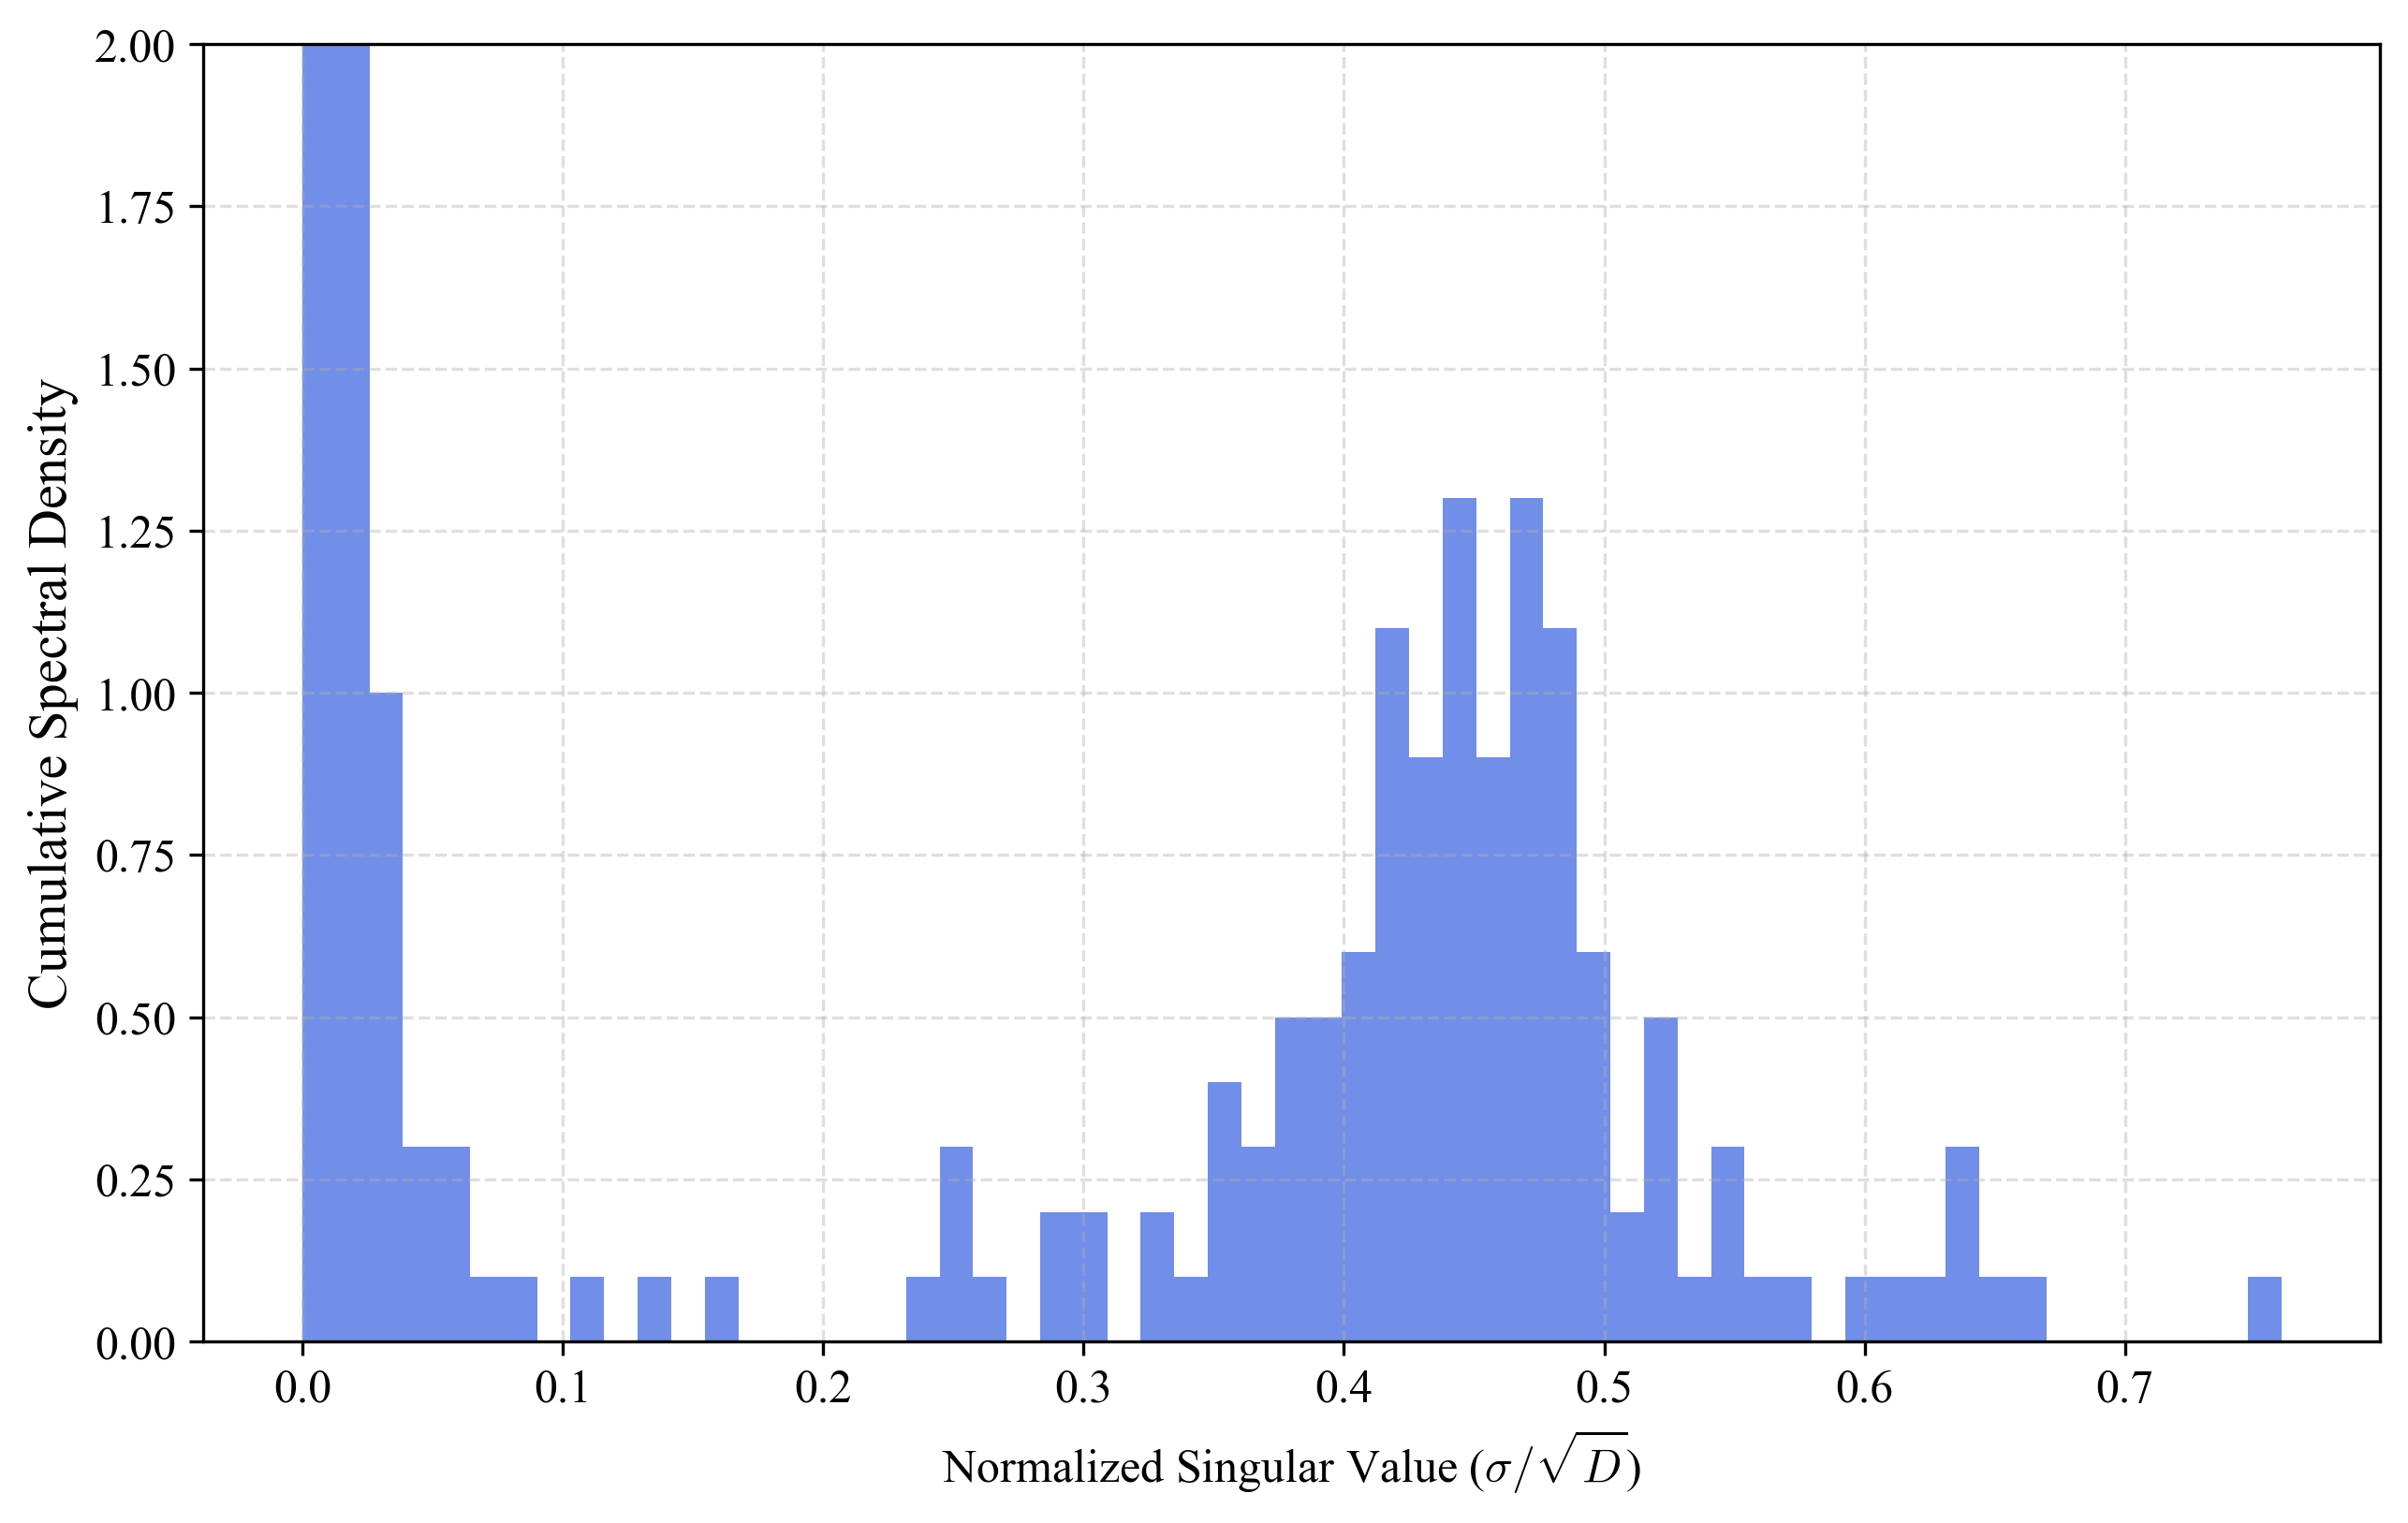

--- File: ../results/run_20251217_0723/heavy_data_9.pkl ---
Saved → ../results/run_20251217_0723/plots/Cumulative_Singular_Spectrum_heavy_data_9.pkl.png



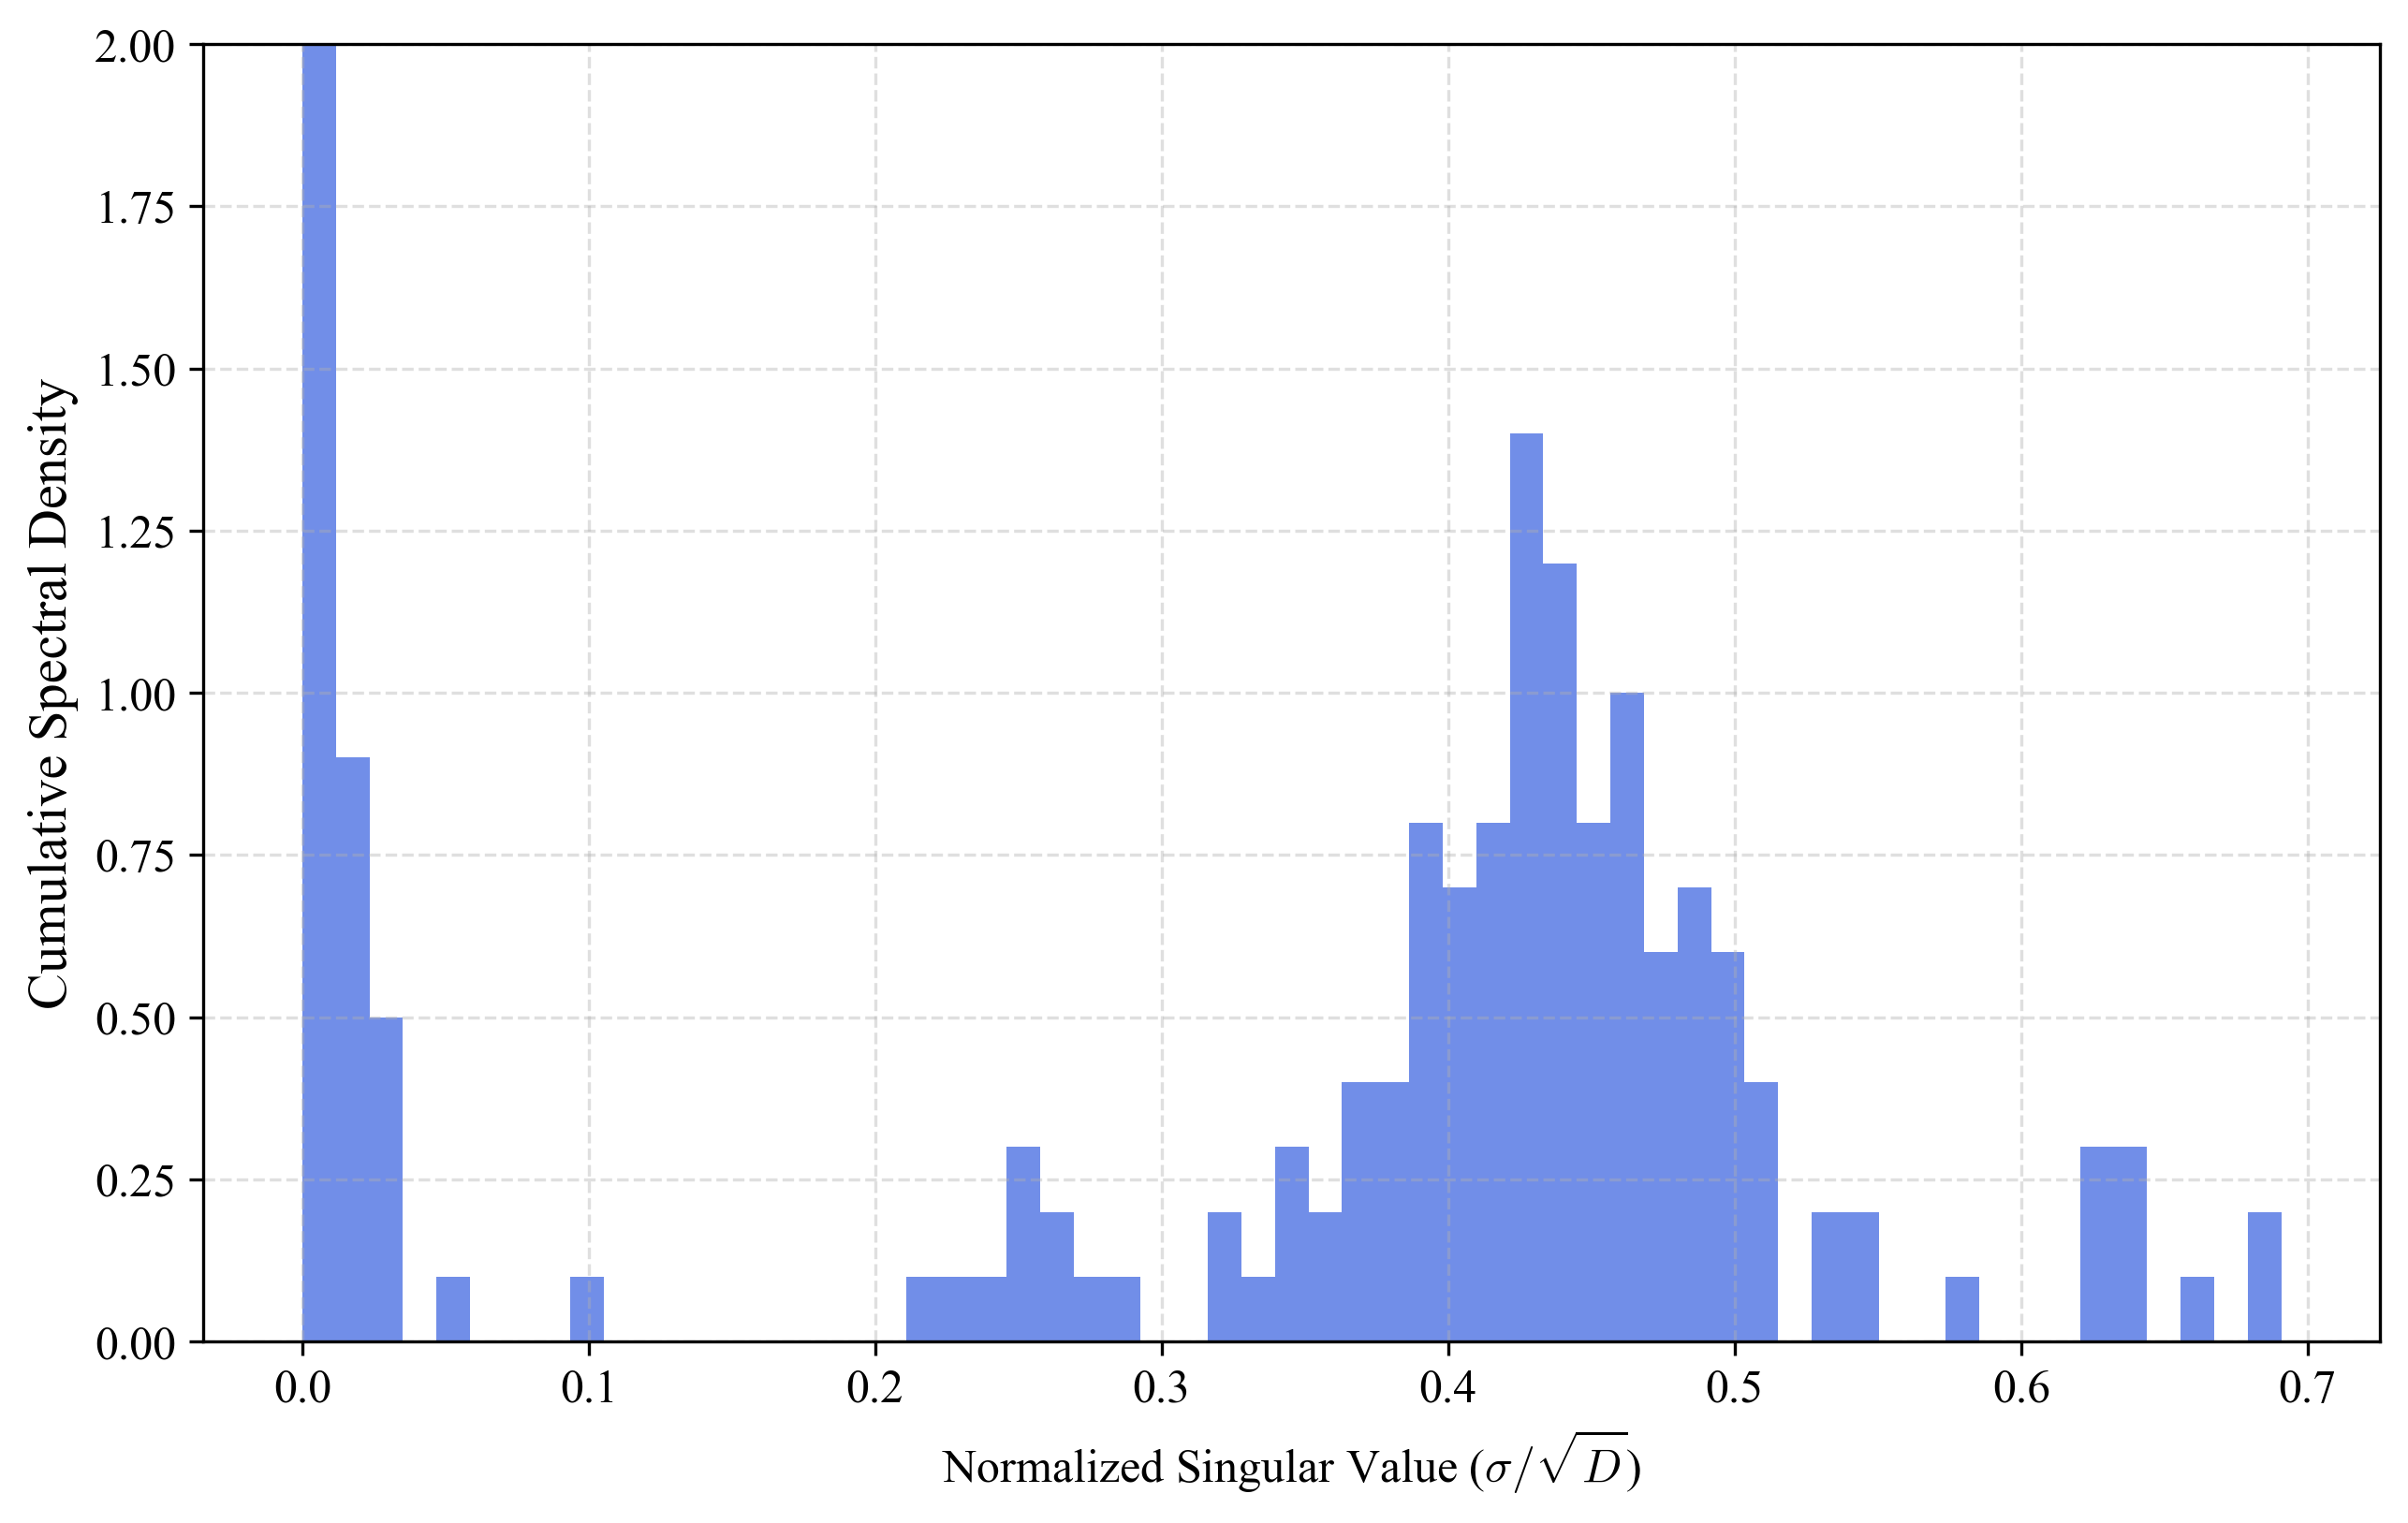

In [6]:
from networkx import density


def plot_singular_cumulative(run_dir, plot_path):
    heavy_files = sorted(glob.glob(os.path.join(run_dir, "heavy_data_*.pkl")))
    print(f"Found {len(heavy_files)} heavy_data files.\n")

    os.makedirs(plot_path, exist_ok=True)

    for heavy_file in heavy_files:
        print(f"--- File: {heavy_file} ---")

        # Load heavy_data
        with open(heavy_file, "rb") as f:
            data = pickle.load(f)

        W_runs_all = data.get("W_runs", [])
        if len(W_runs_all) == 0:
            print("⚠ No W_runs in this file.\n")
            continue

        # --- Compute singular values for each W ---
        all_singvals = []

        for W in W_runs_all:
            # singular values of W / sqrt(D*R) (normalization)
            s = np.linalg.svd(W, compute_uv=False) / np.sqrt(W.shape[0])
            all_singvals.append(s)

        # flatten all singular values into a long vector
        all_singvals = np.concatenate(all_singvals)

        # build histogram bins
        bins = np.linspace(all_singvals.min(), all_singvals.max(), 60)

        # cumulative histogram
        hist, _ = np.histogram(all_singvals, bins=bins)
        n_samples = len(W_runs_all)
        hist = hist / n_samples

        plt.figure(figsize=(10, 6))
        plt.bar(
            (bins[:-1] + bins[1:]) / 2,
            hist,
            width=np.diff(bins),
            alpha=0.75,
            color="royalblue",
        )

        plt.xlabel(r"Normalized Singular Value ($\sigma / \sqrt{D}$)", fontsize=12)
        plt.ylabel("Cumulative Spectral Density", fontsize=14)
        plt.grid(True, linestyle="--", alpha=0.4)
        # plt.title(f"Cumulative Singular Value Spectrum – {os.path.basename(heavy_file)}")
        plt.ylim(0, 2)

        out_path = os.path.join(
            plot_path,
            f"Cumulative_Singular_Spectrum_{os.path.basename(heavy_file)}.png"
        )
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"Saved → {out_path}\n")

        plt.show()


# Usage:
plot_singular_cumulative(run_dir, plot_path)

Found 15 attention files and 15 preds files
Les images seront sauvegardées dans : ../results/run_20251217_0723/plots
Processing file: attn_0.pkl
✅ Saved plot: ../results/run_20251217_0723/plots/attn_0_run3.png


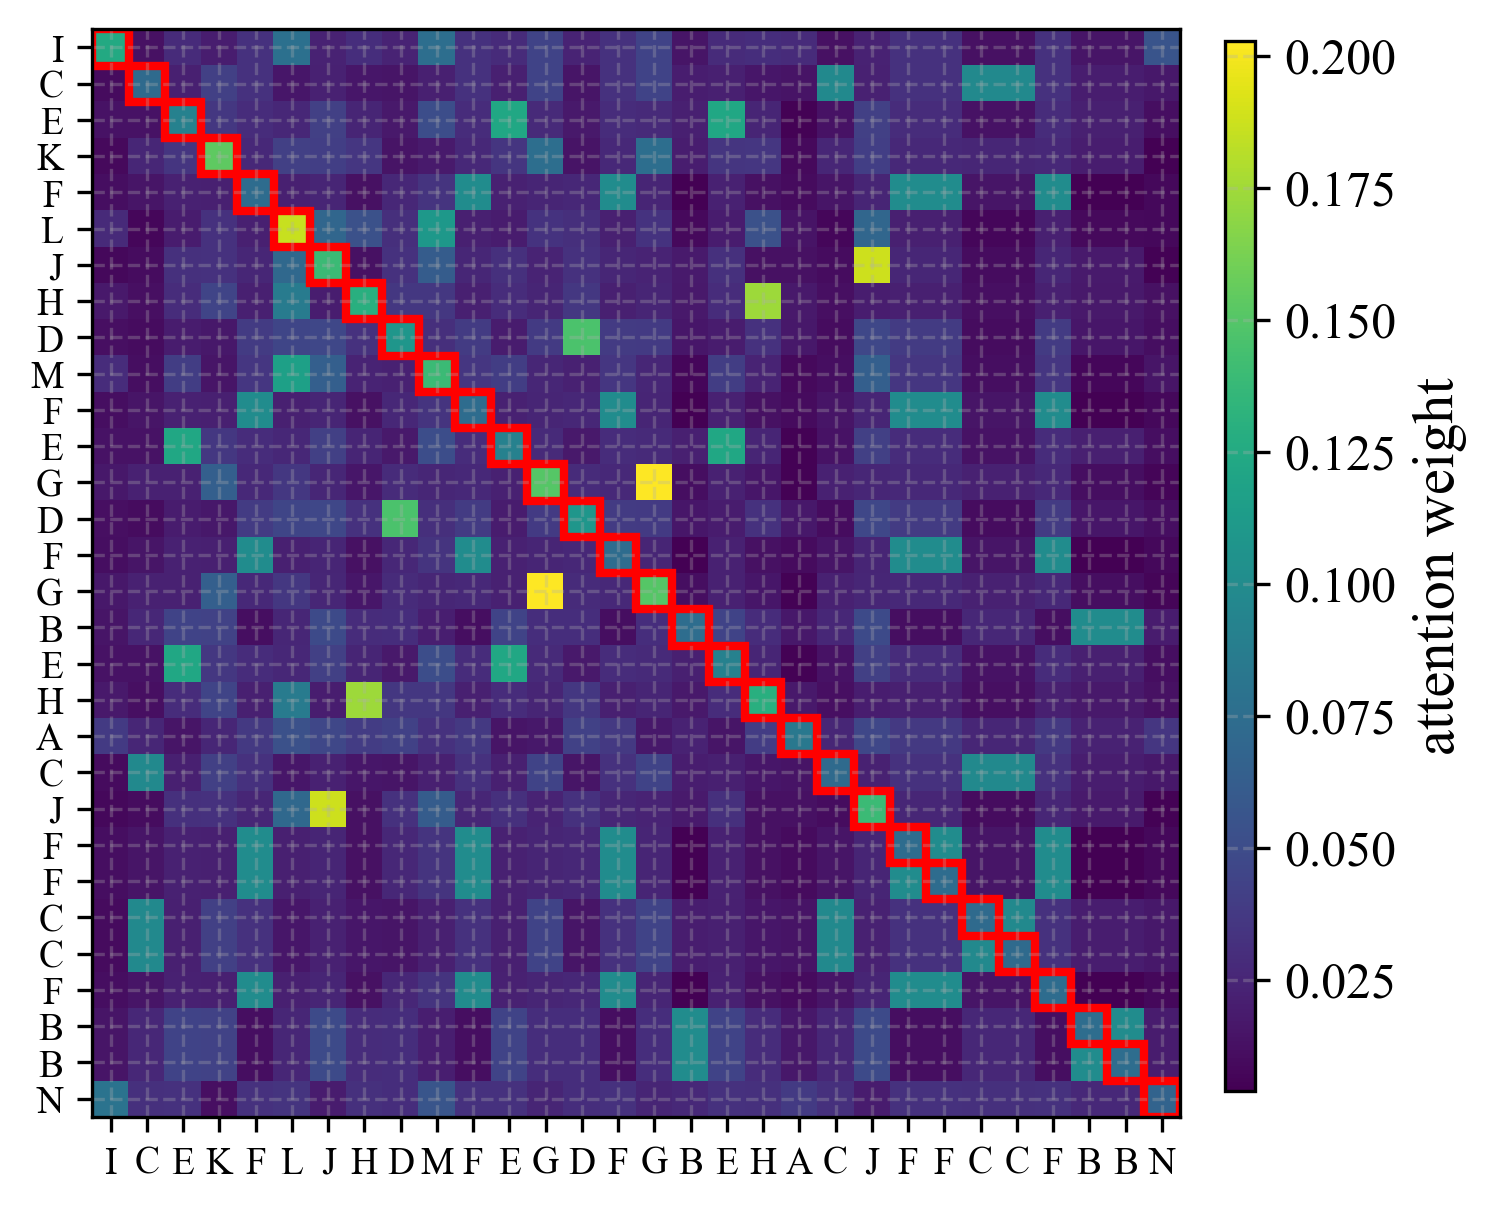

Processing file: attn_1.pkl
✅ Saved plot: ../results/run_20251217_0723/plots/attn_1_run3.png


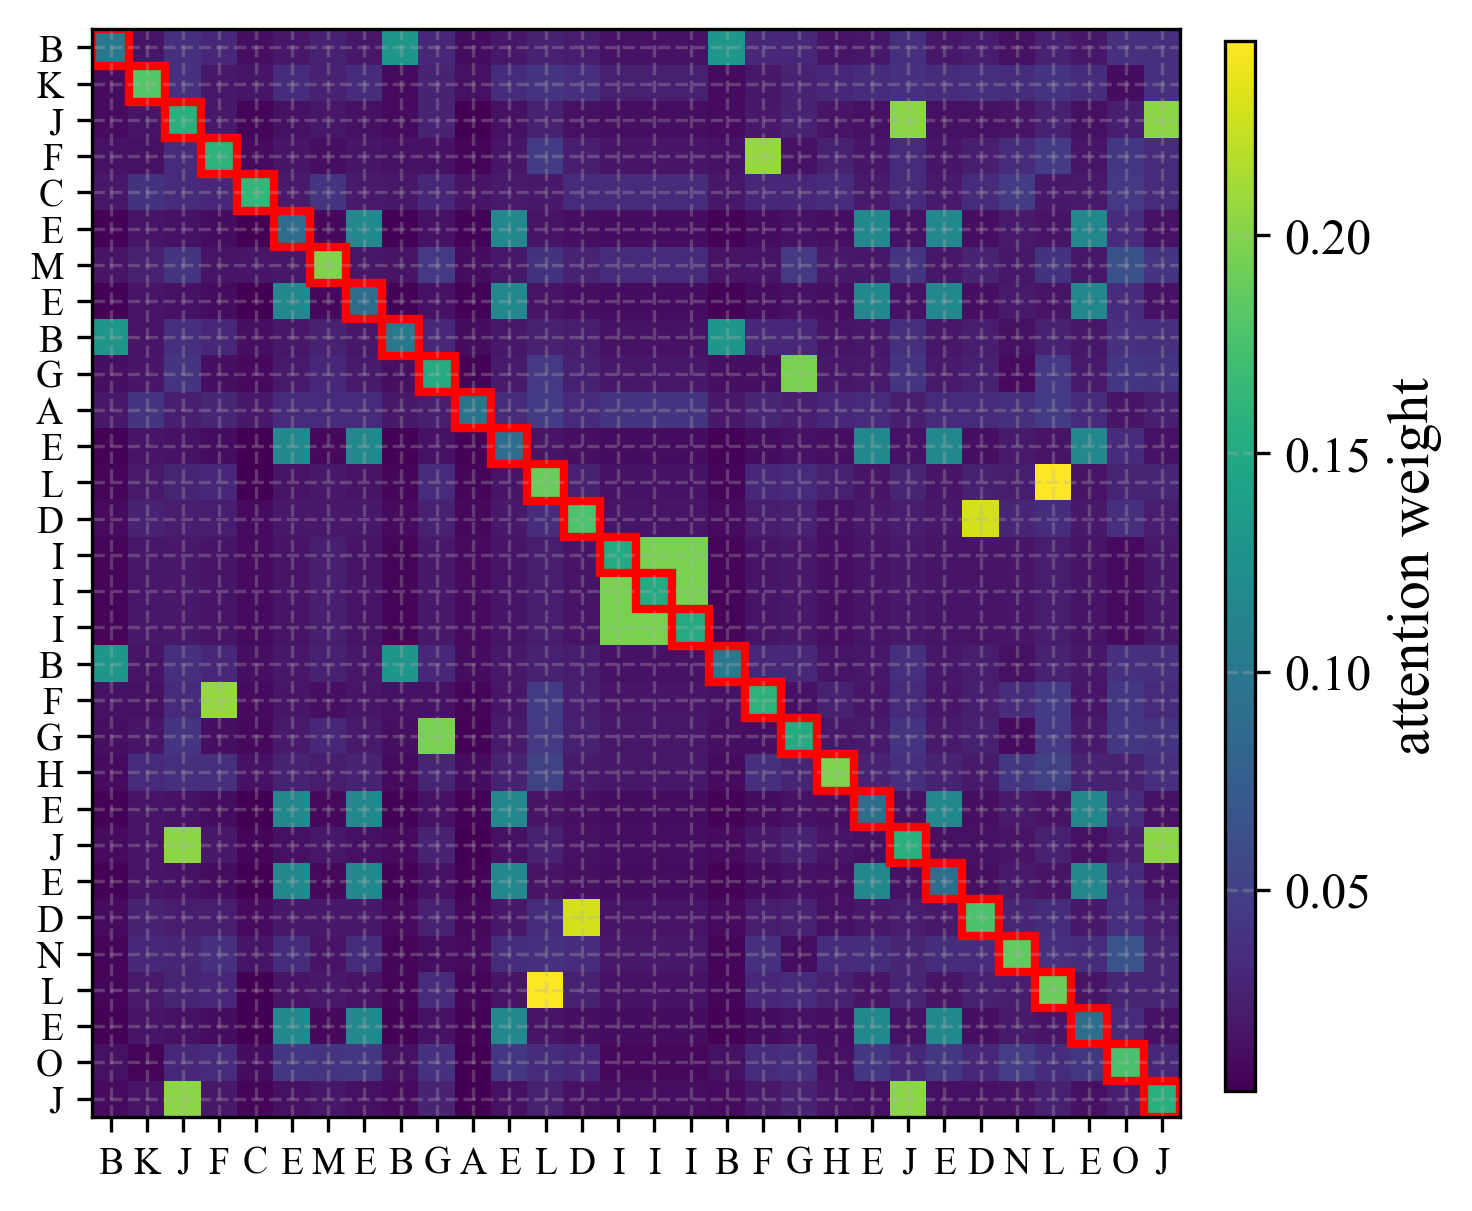

Processing file: attn_10.pkl
✅ Saved plot: ../results/run_20251217_0723/plots/attn_10_run3.png


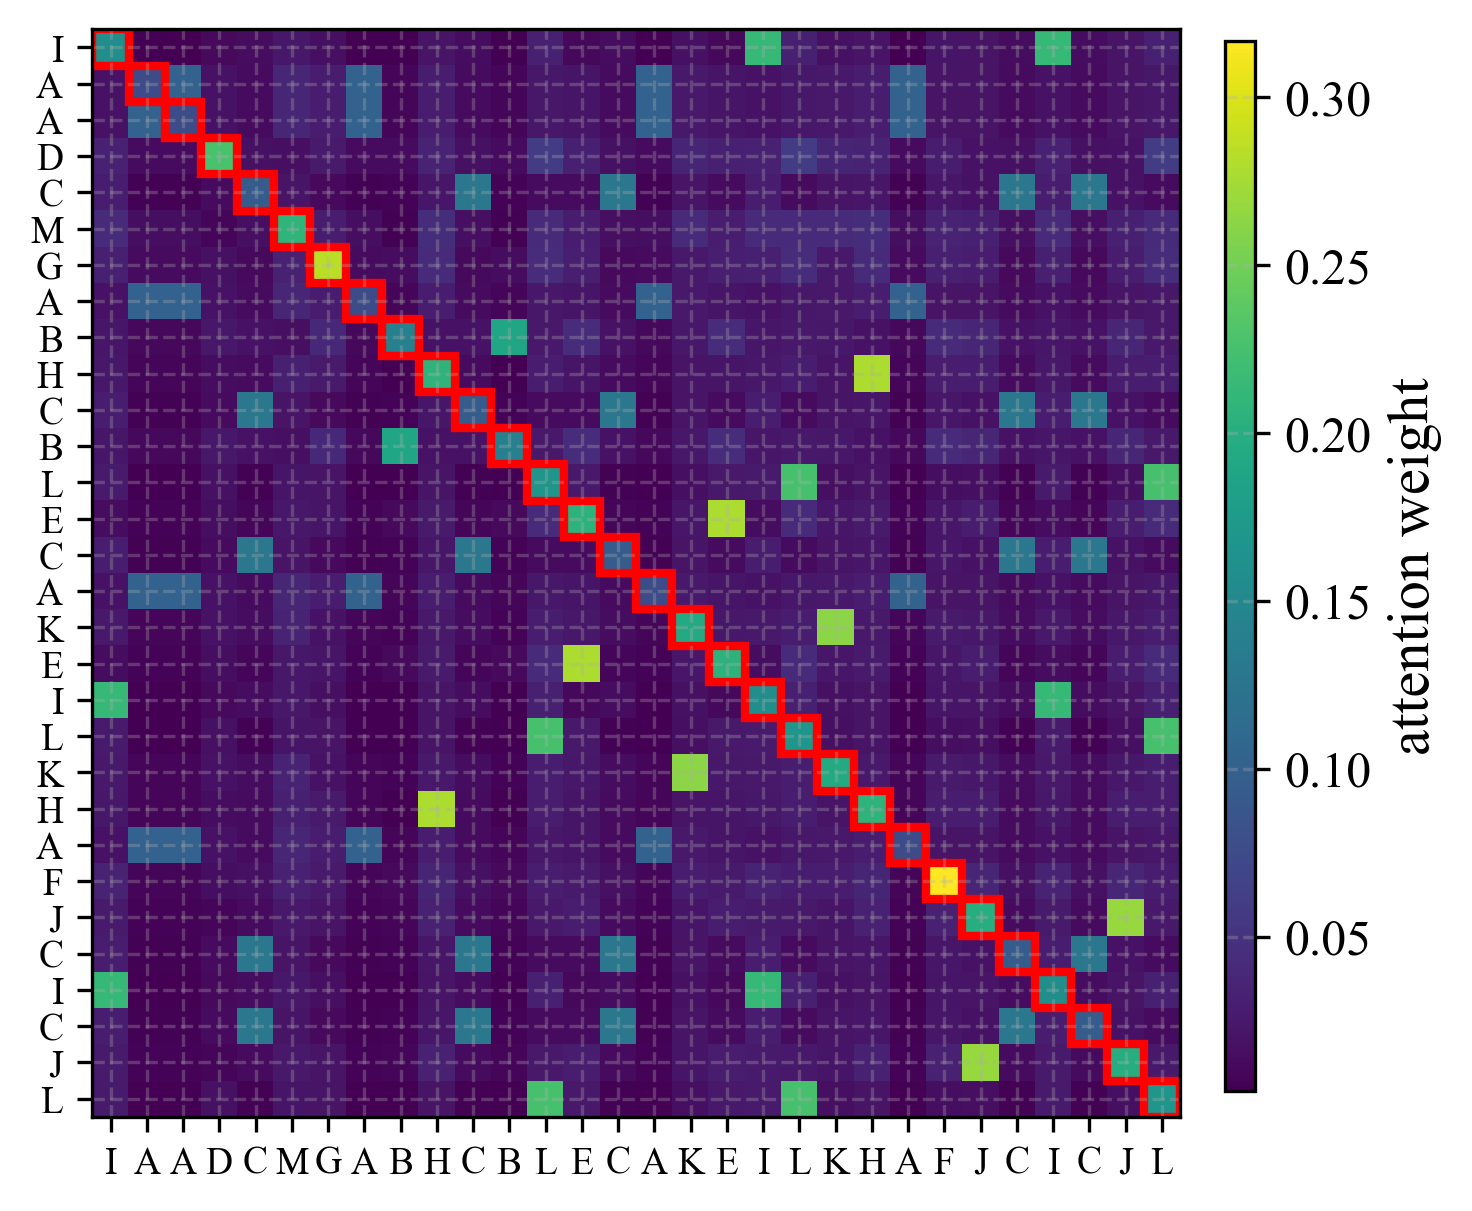

Processing file: attn_11.pkl
✅ Saved plot: ../results/run_20251217_0723/plots/attn_11_run3.png


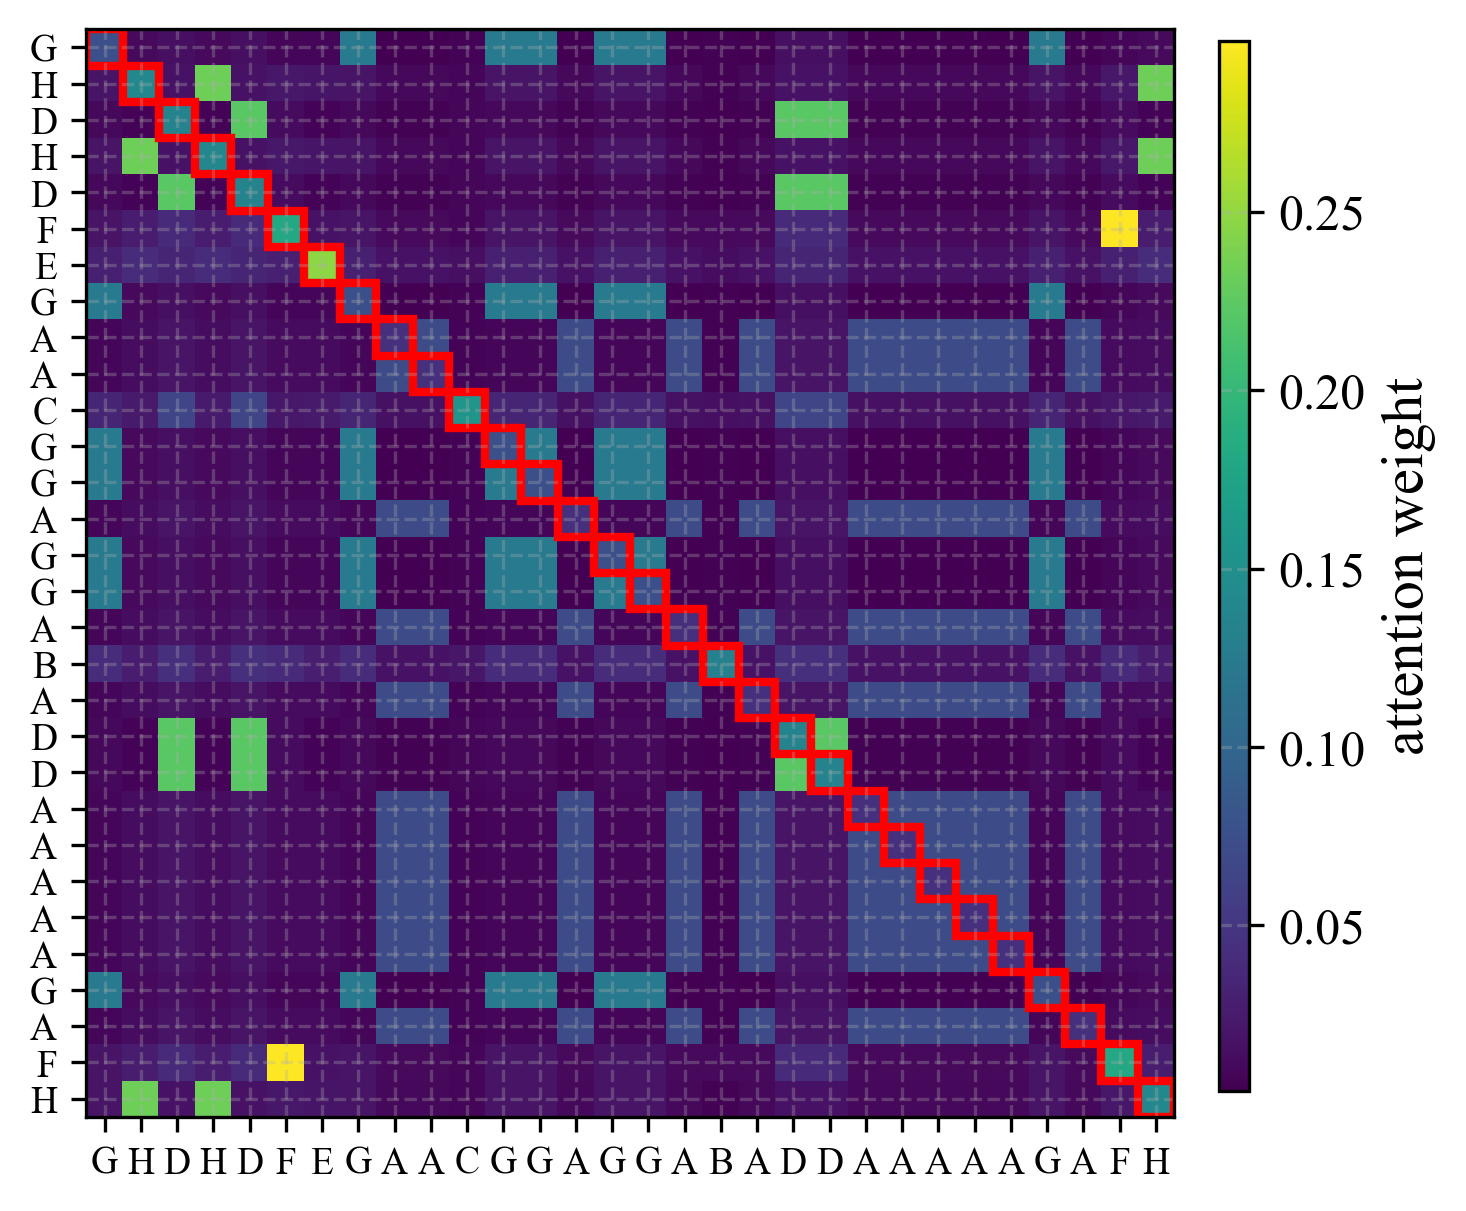

Processing file: attn_12.pkl
✅ Saved plot: ../results/run_20251217_0723/plots/attn_12_run3.png


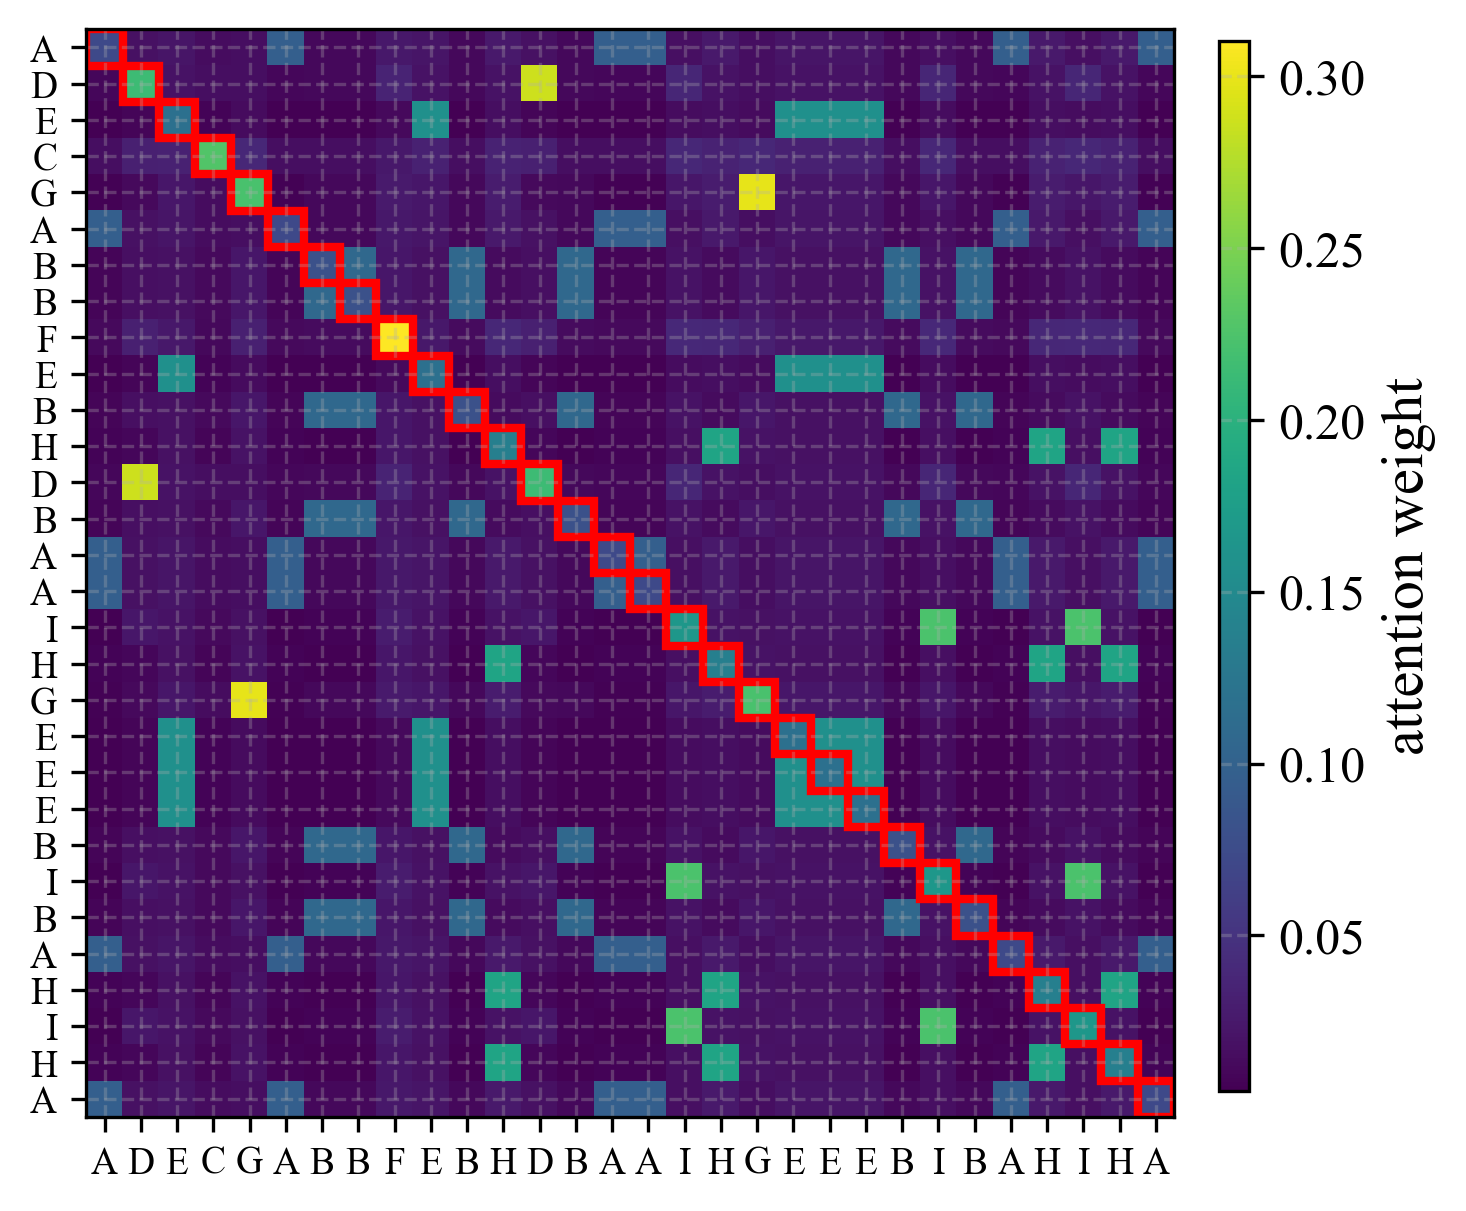

Processing file: attn_13.pkl
✅ Saved plot: ../results/run_20251217_0723/plots/attn_13_run3.png


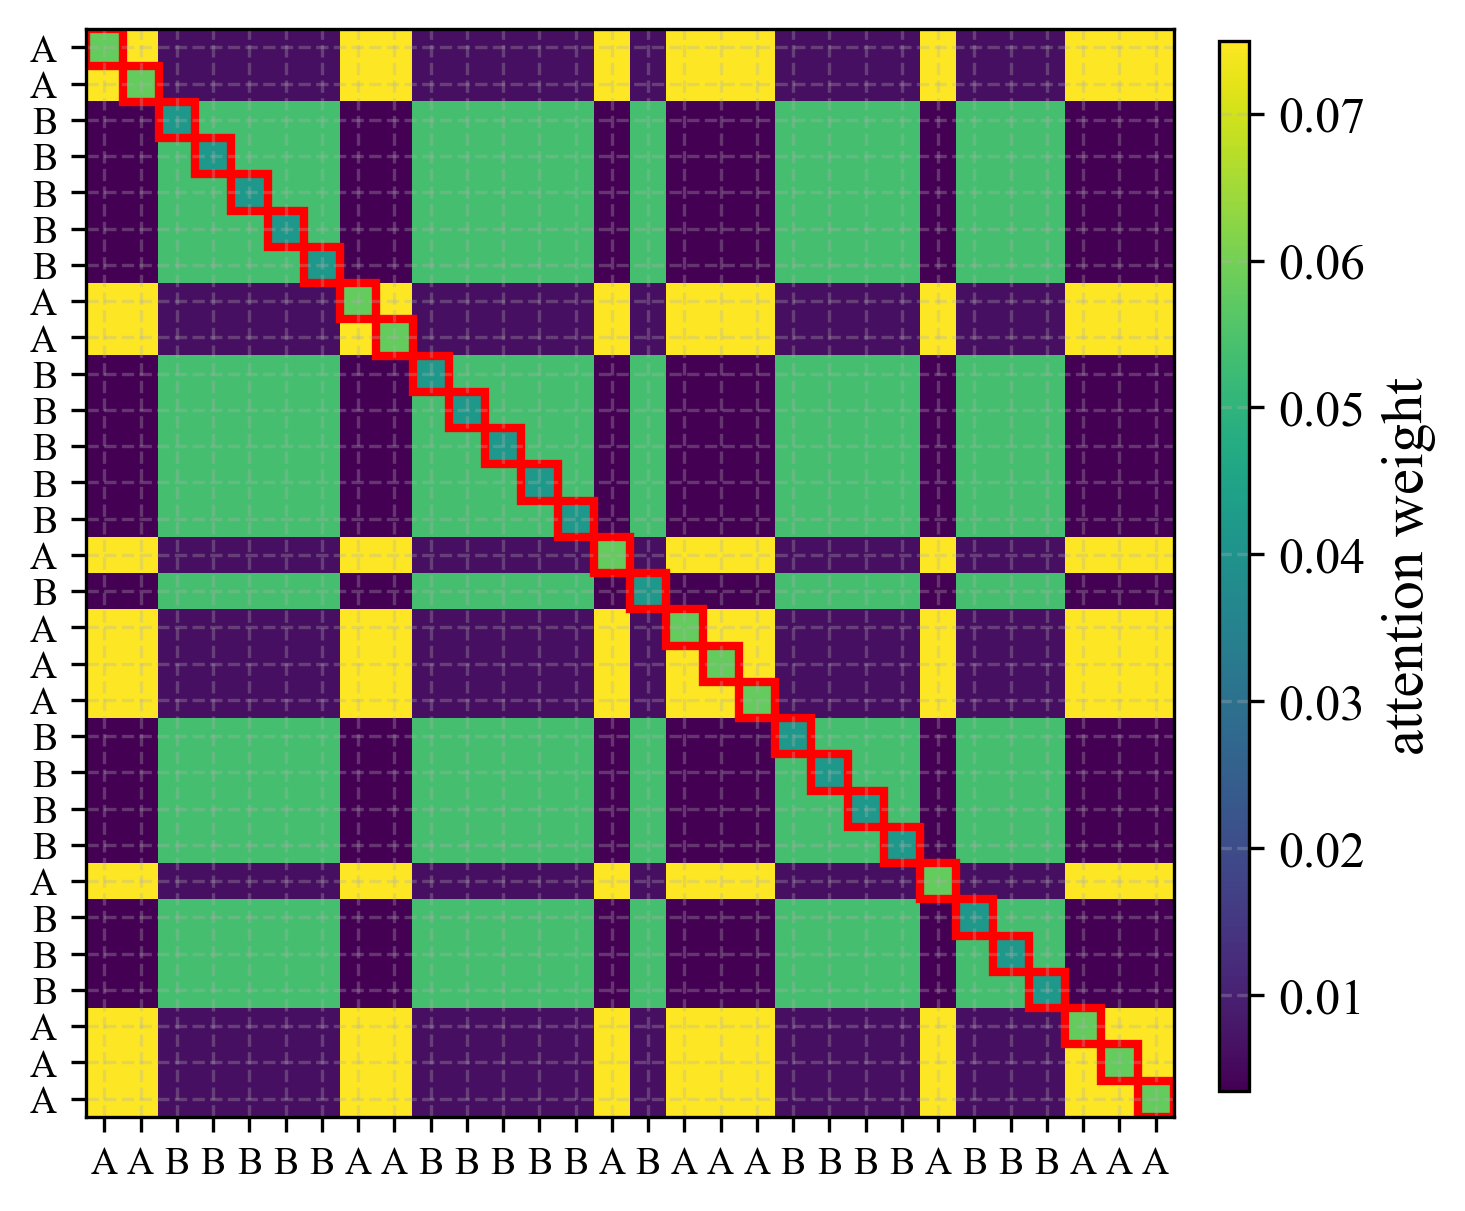

Processing file: attn_14.pkl
✅ Saved plot: ../results/run_20251217_0723/plots/attn_14_run3.png


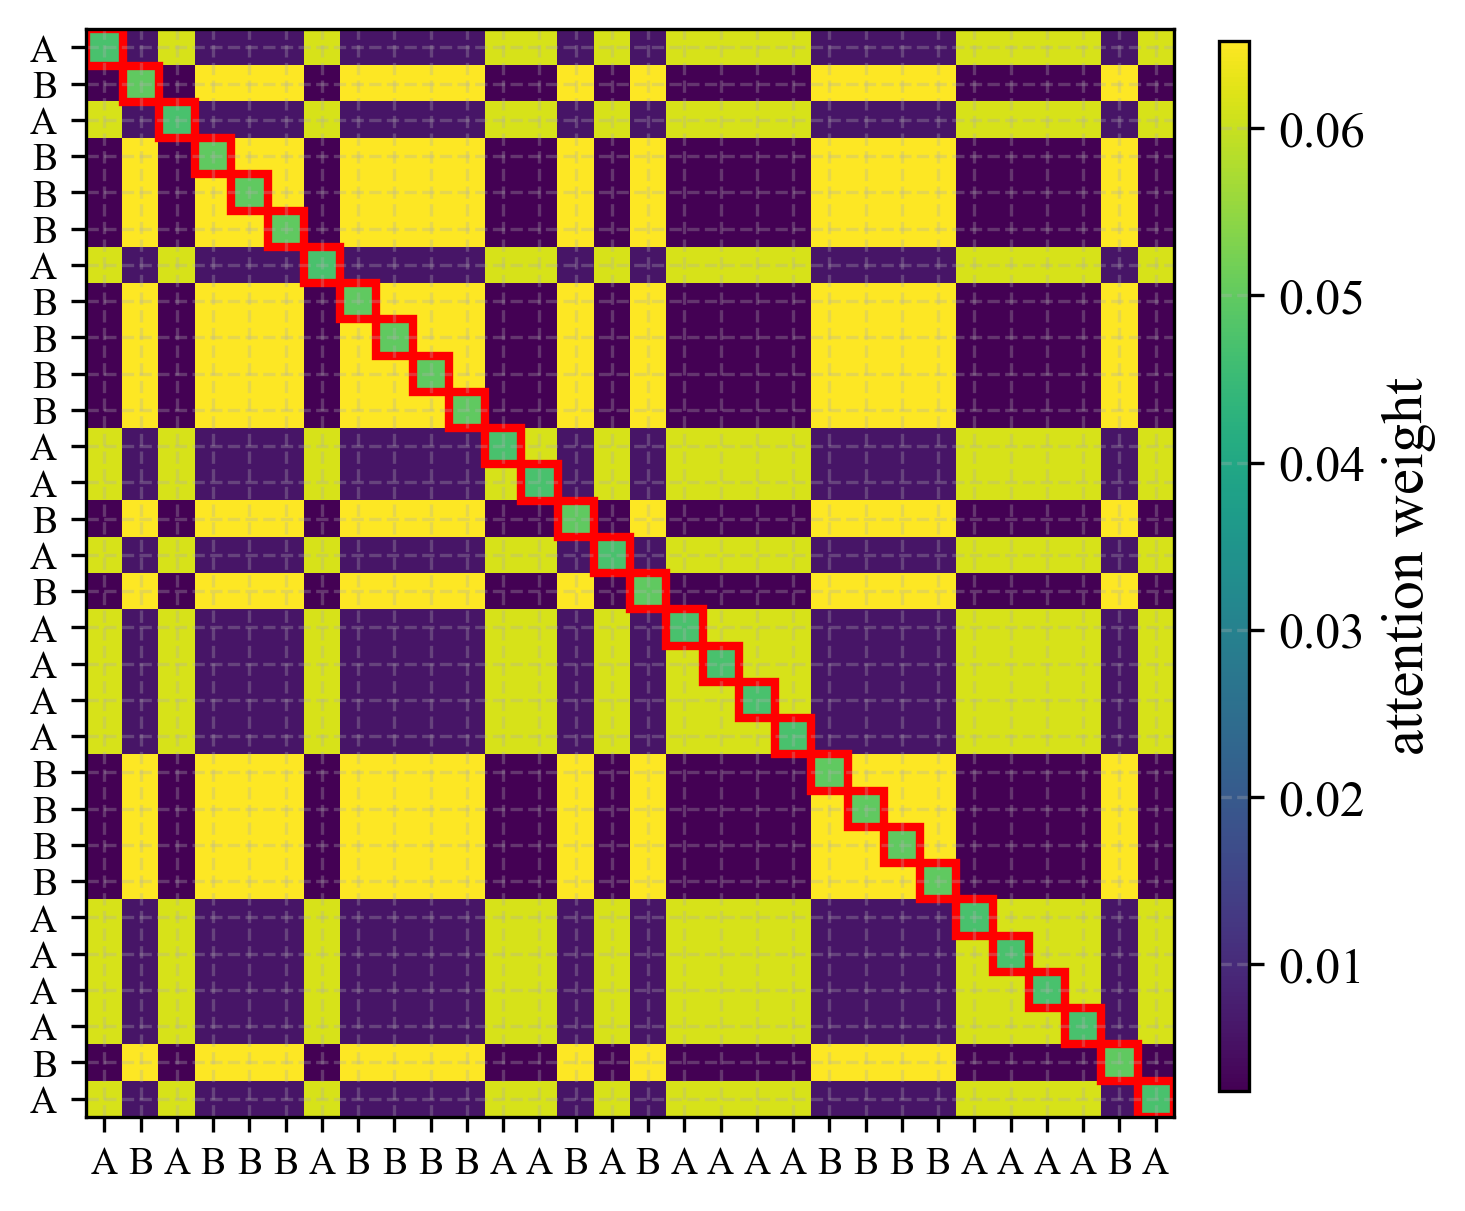

Processing file: attn_2.pkl
✅ Saved plot: ../results/run_20251217_0723/plots/attn_2_run3.png


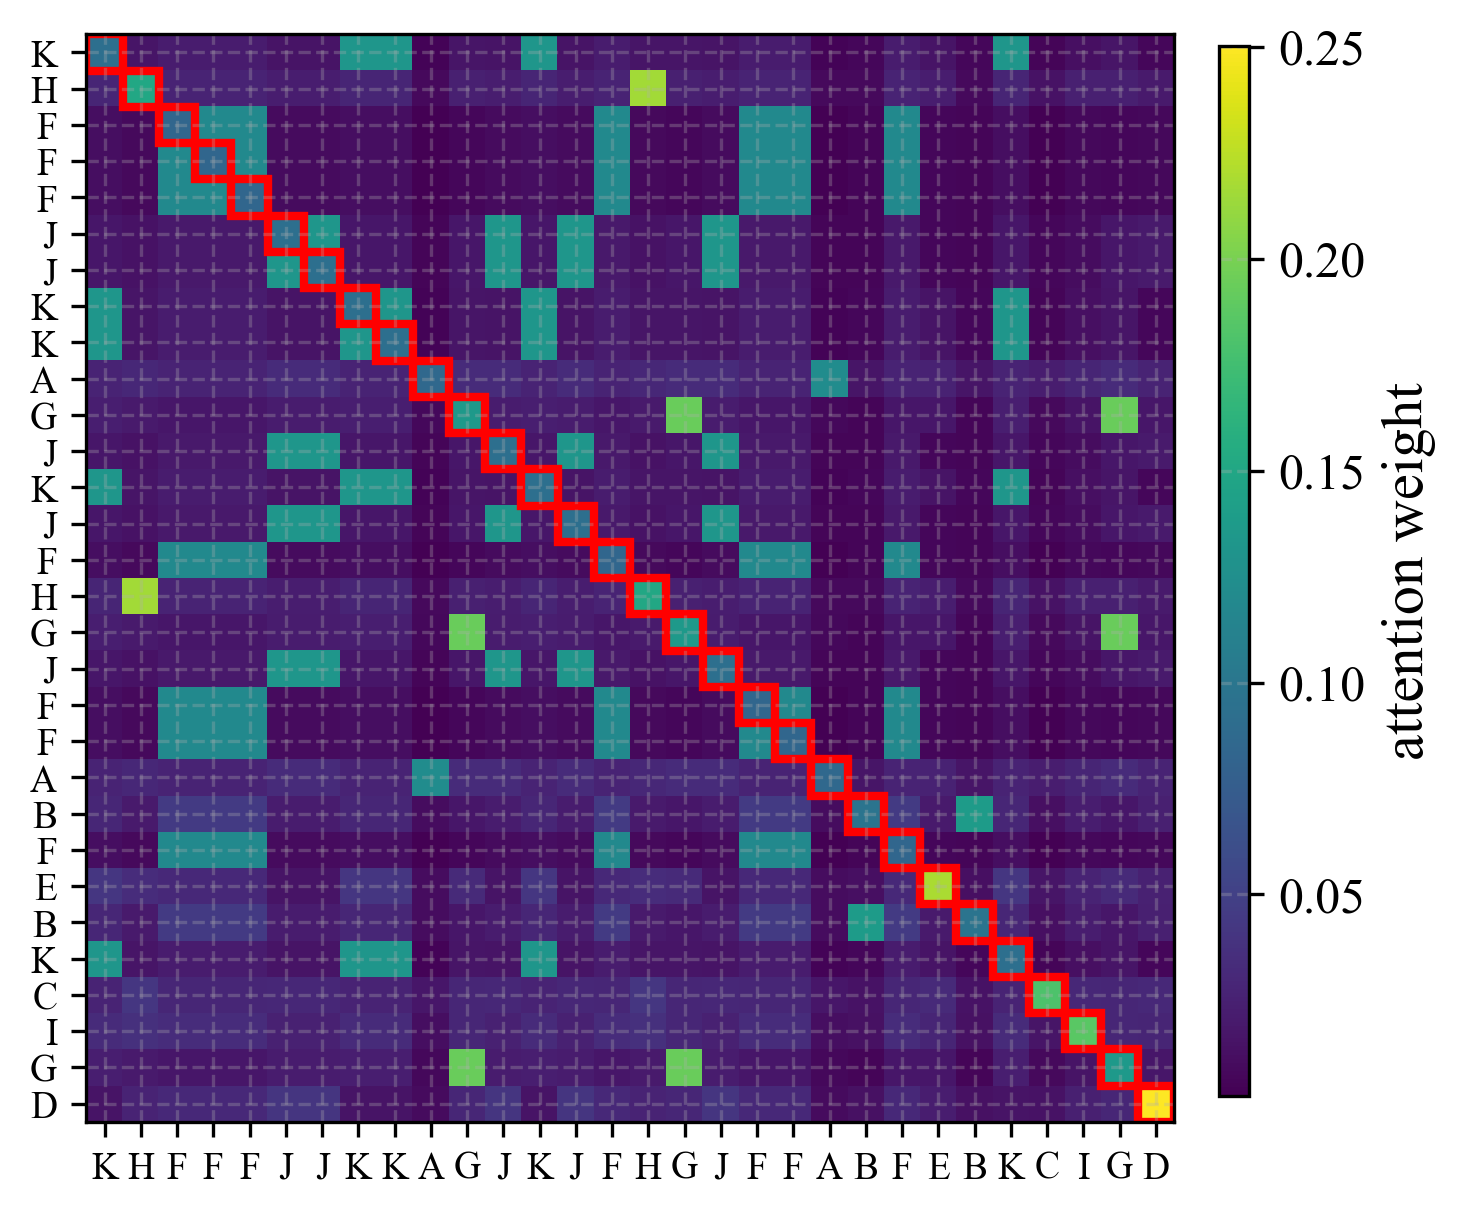

Processing file: attn_3.pkl
✅ Saved plot: ../results/run_20251217_0723/plots/attn_3_run3.png


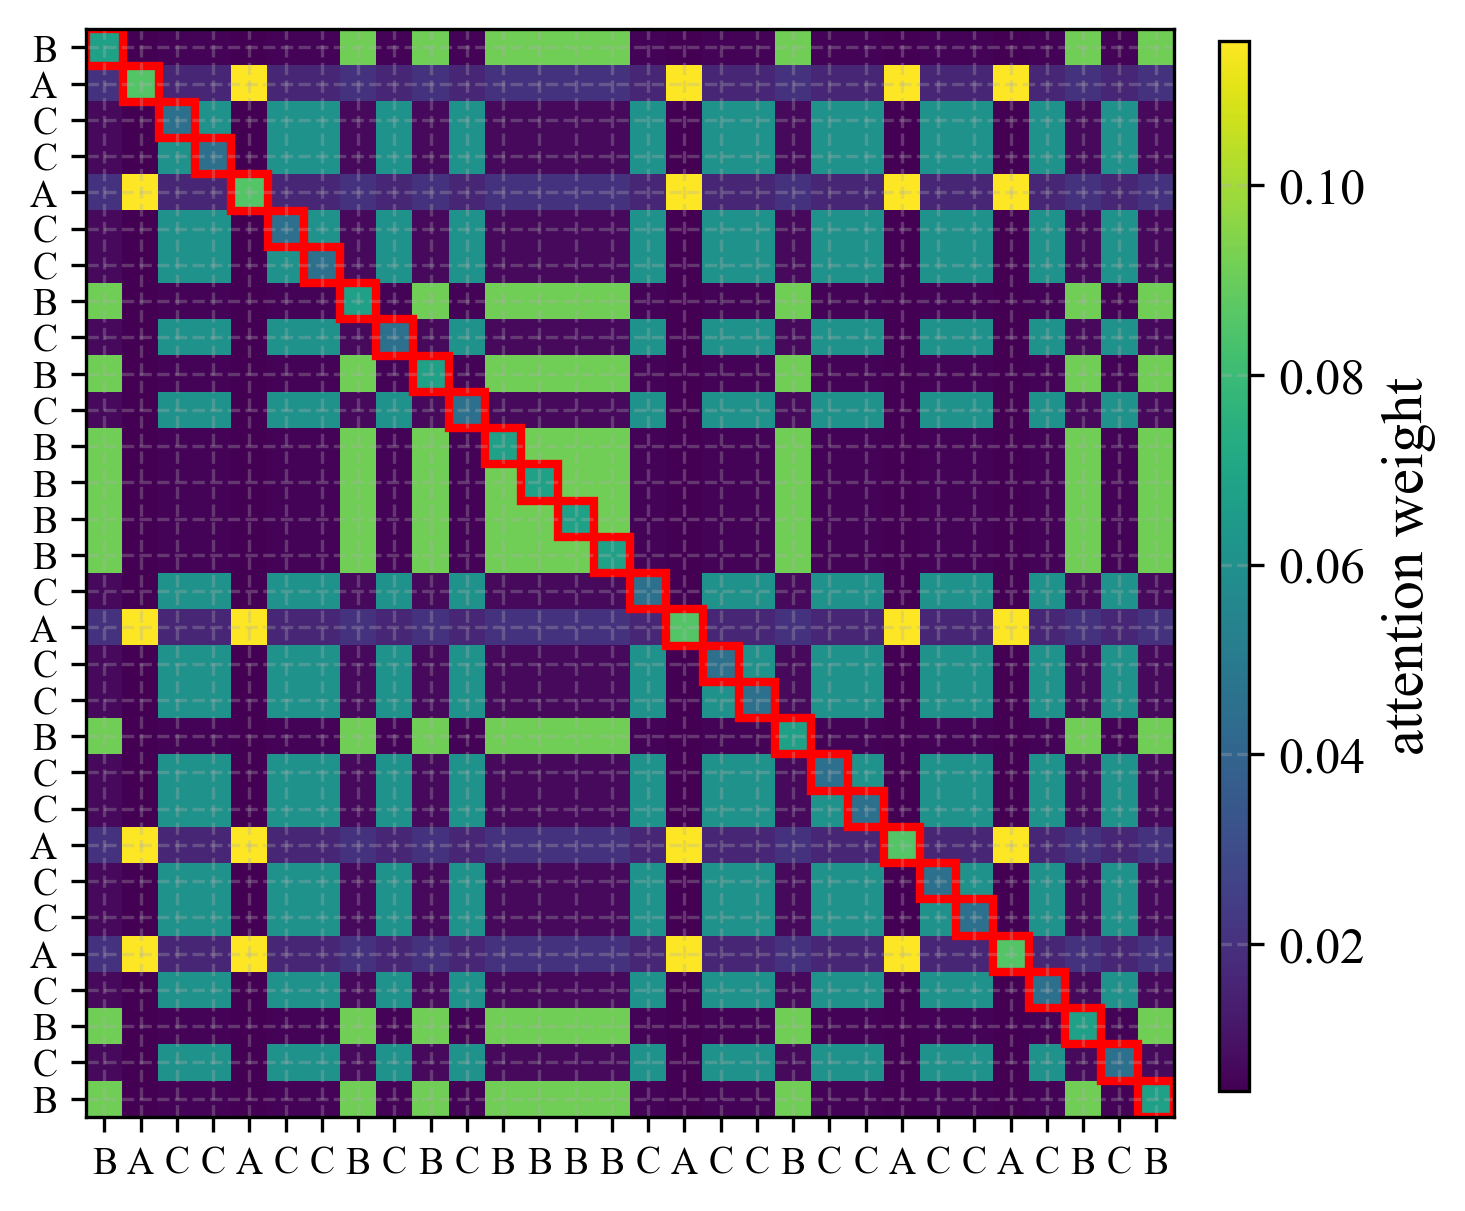

Processing file: attn_4.pkl
✅ Saved plot: ../results/run_20251217_0723/plots/attn_4_run3.png


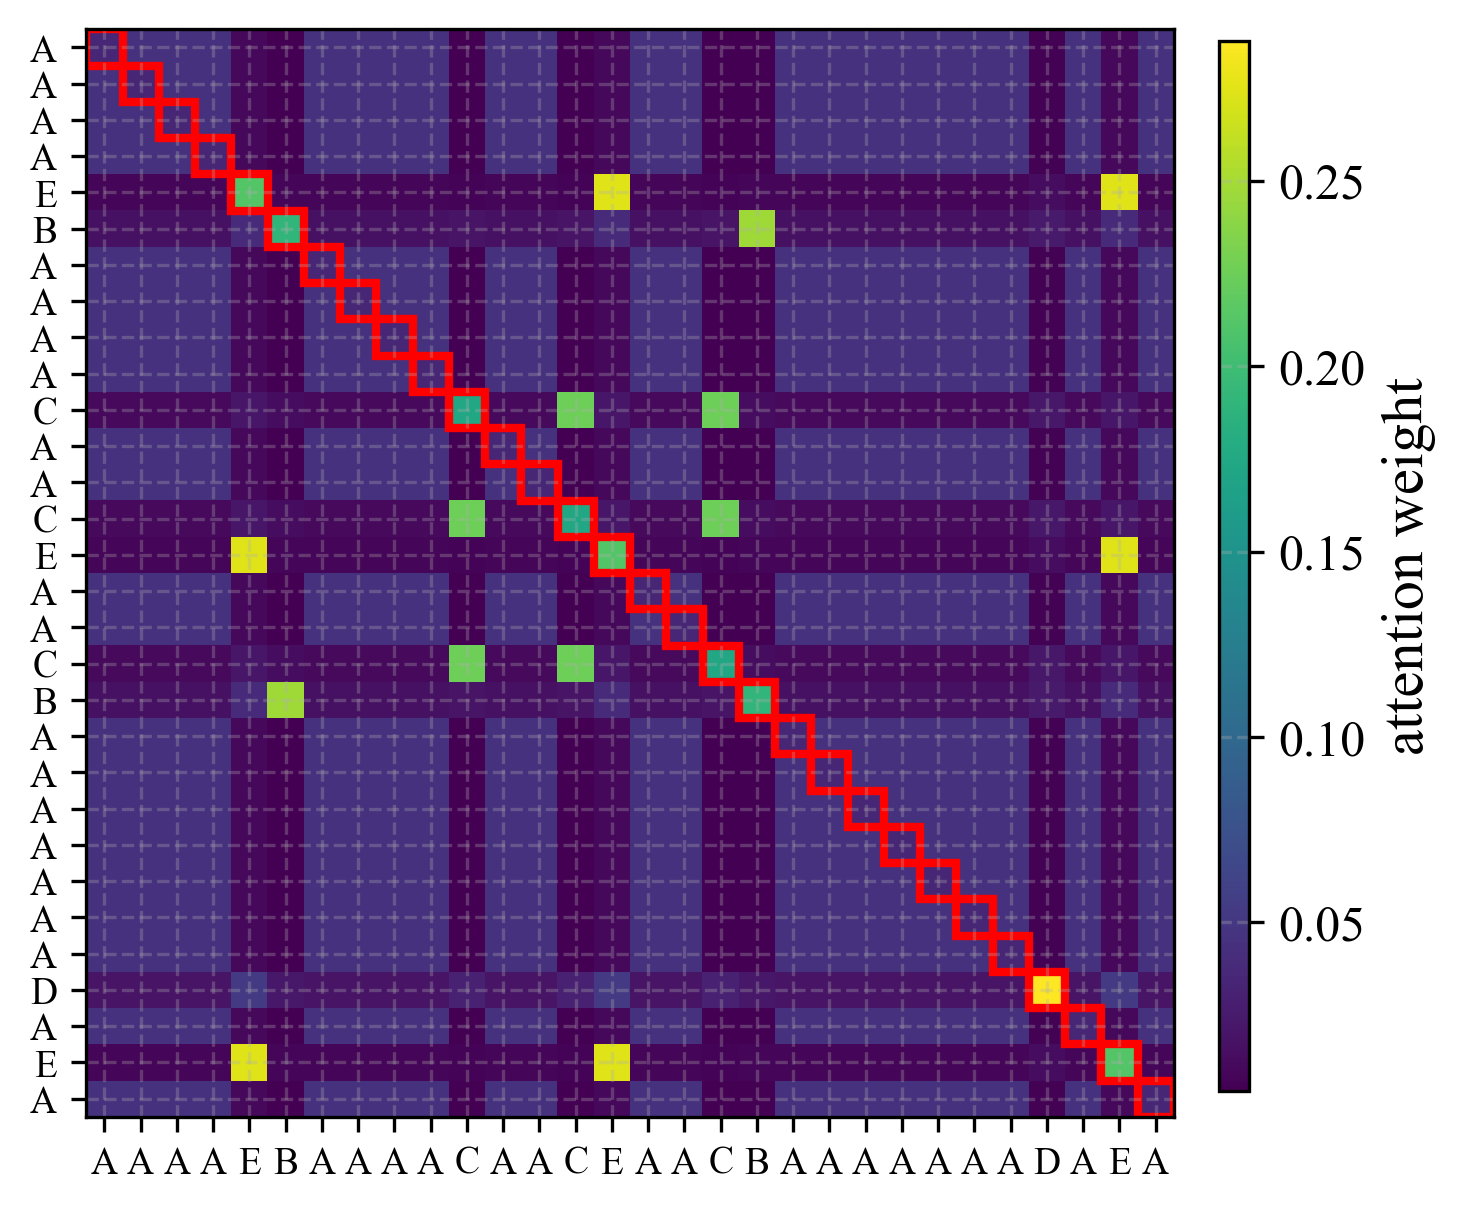

Processing file: attn_5.pkl
✅ Saved plot: ../results/run_20251217_0723/plots/attn_5_run3.png


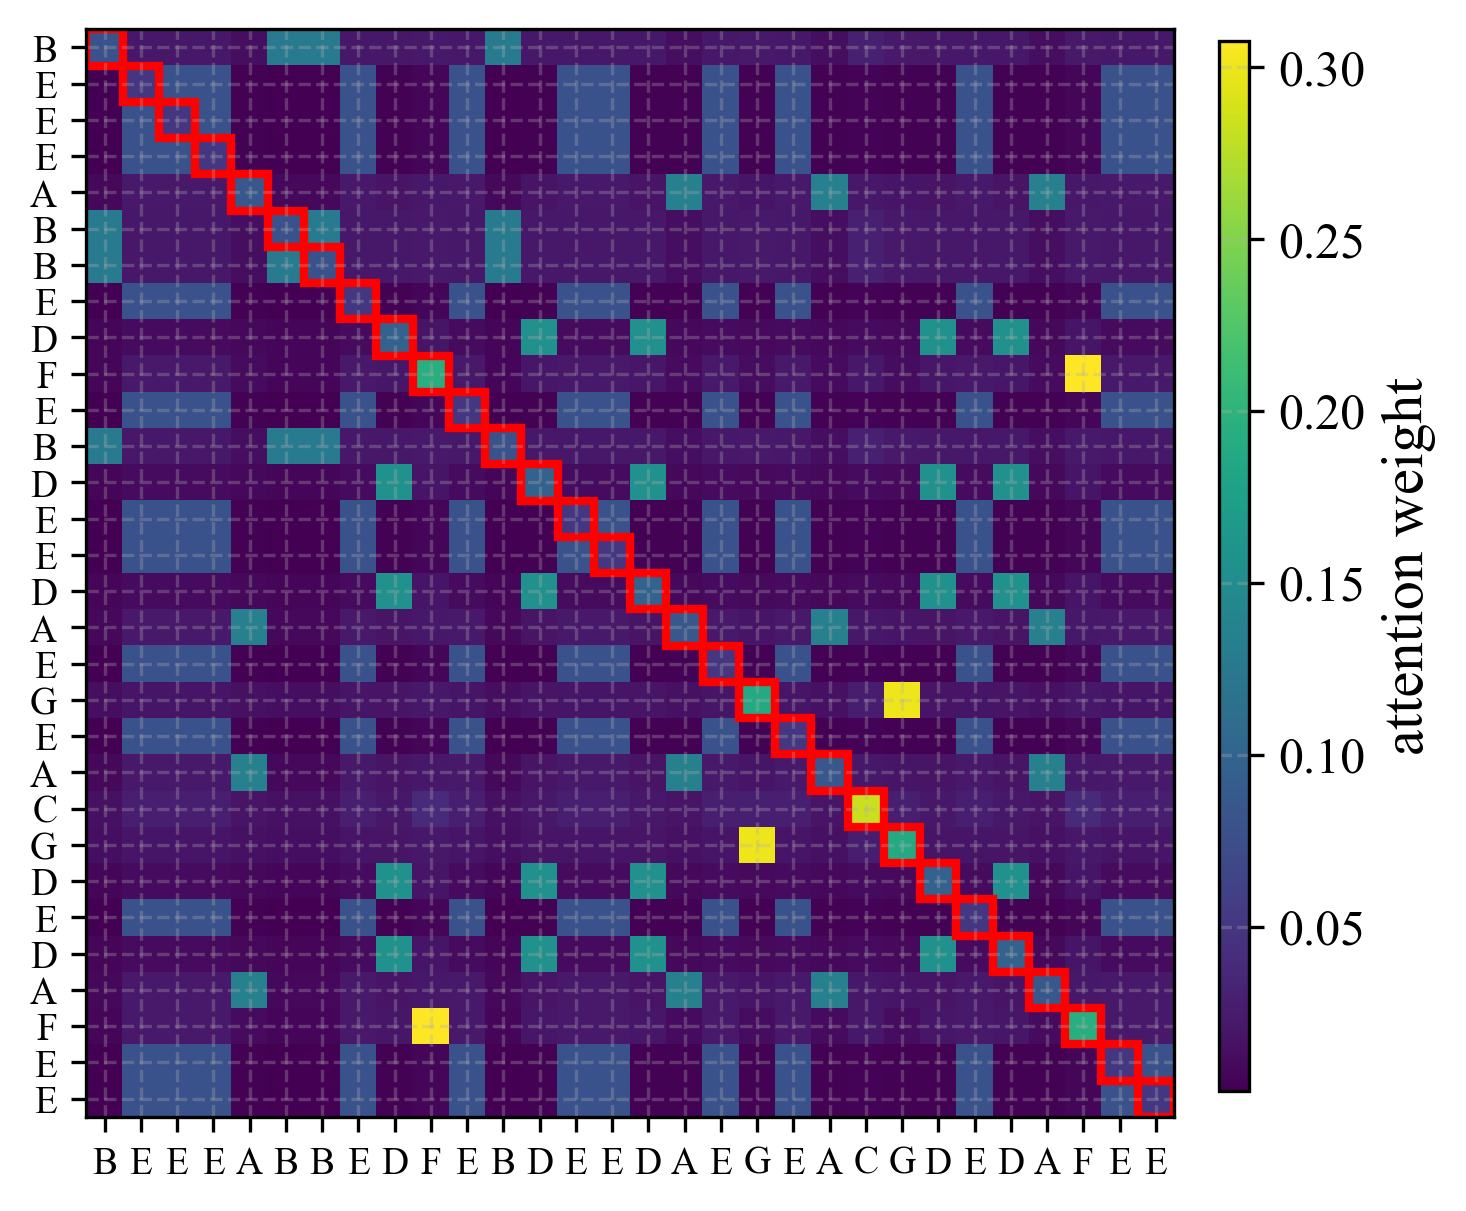

Processing file: attn_6.pkl
✅ Saved plot: ../results/run_20251217_0723/plots/attn_6_run3.png


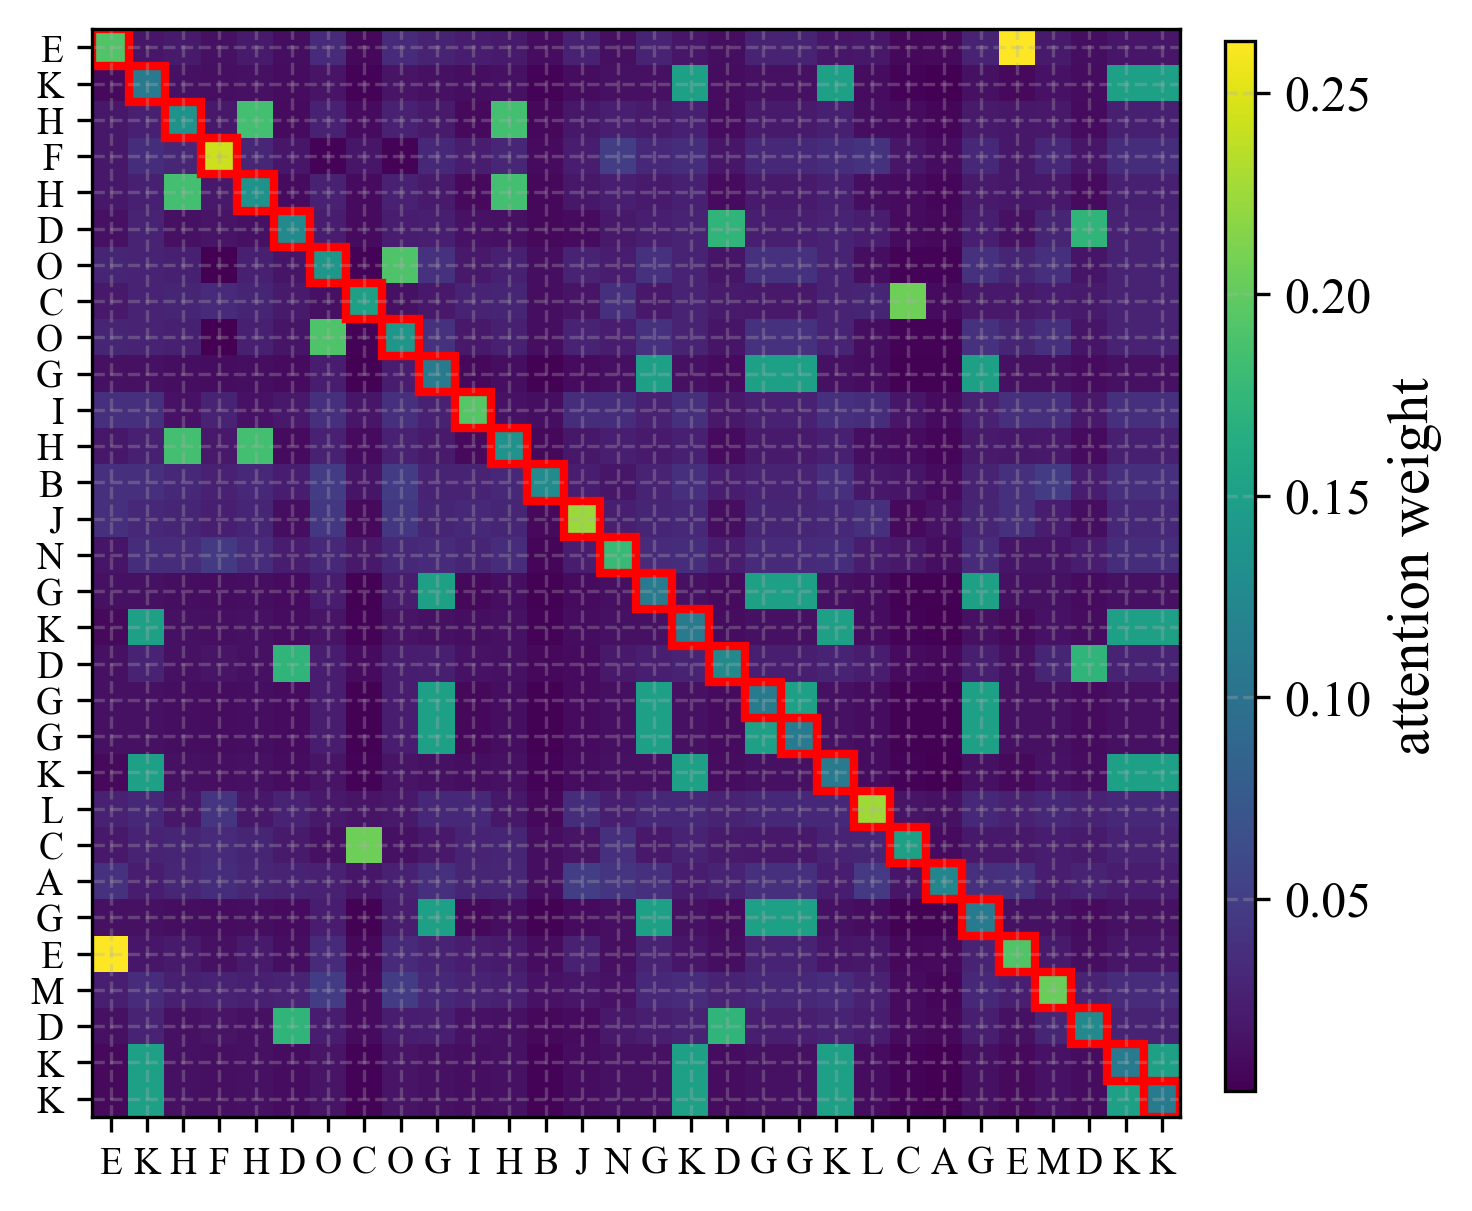

Processing file: attn_7.pkl
✅ Saved plot: ../results/run_20251217_0723/plots/attn_7_run3.png


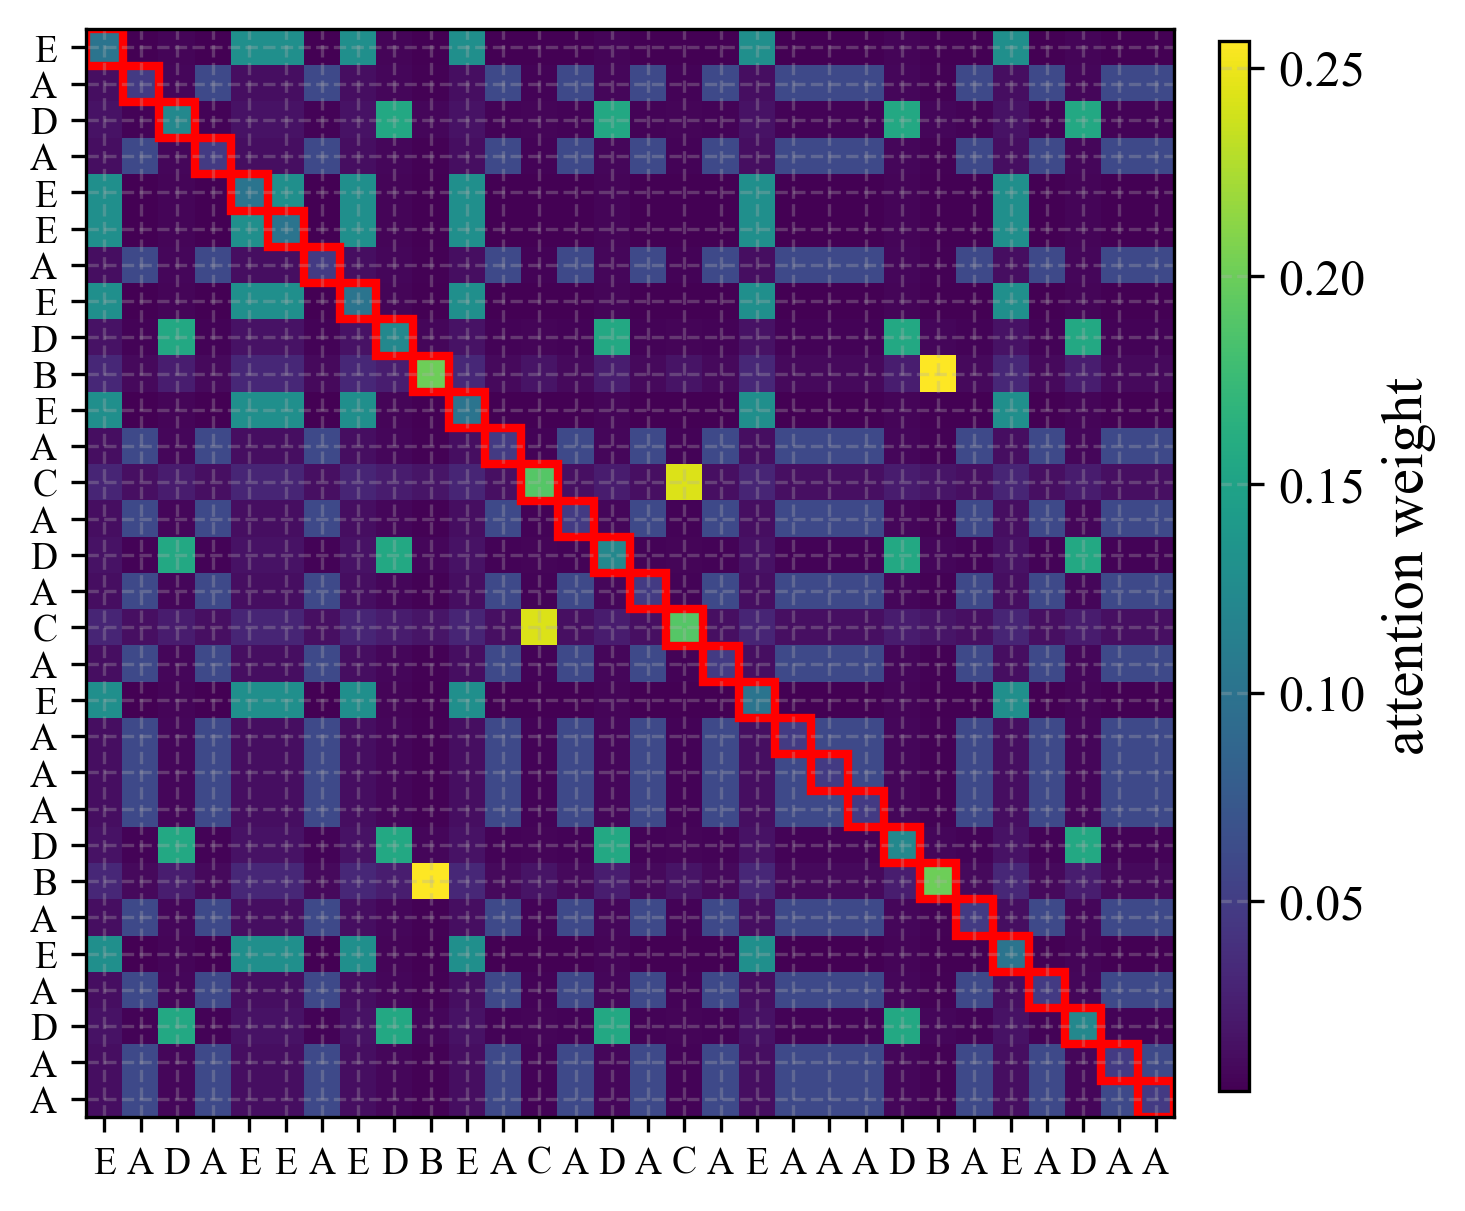

Processing file: attn_8.pkl
✅ Saved plot: ../results/run_20251217_0723/plots/attn_8_run3.png


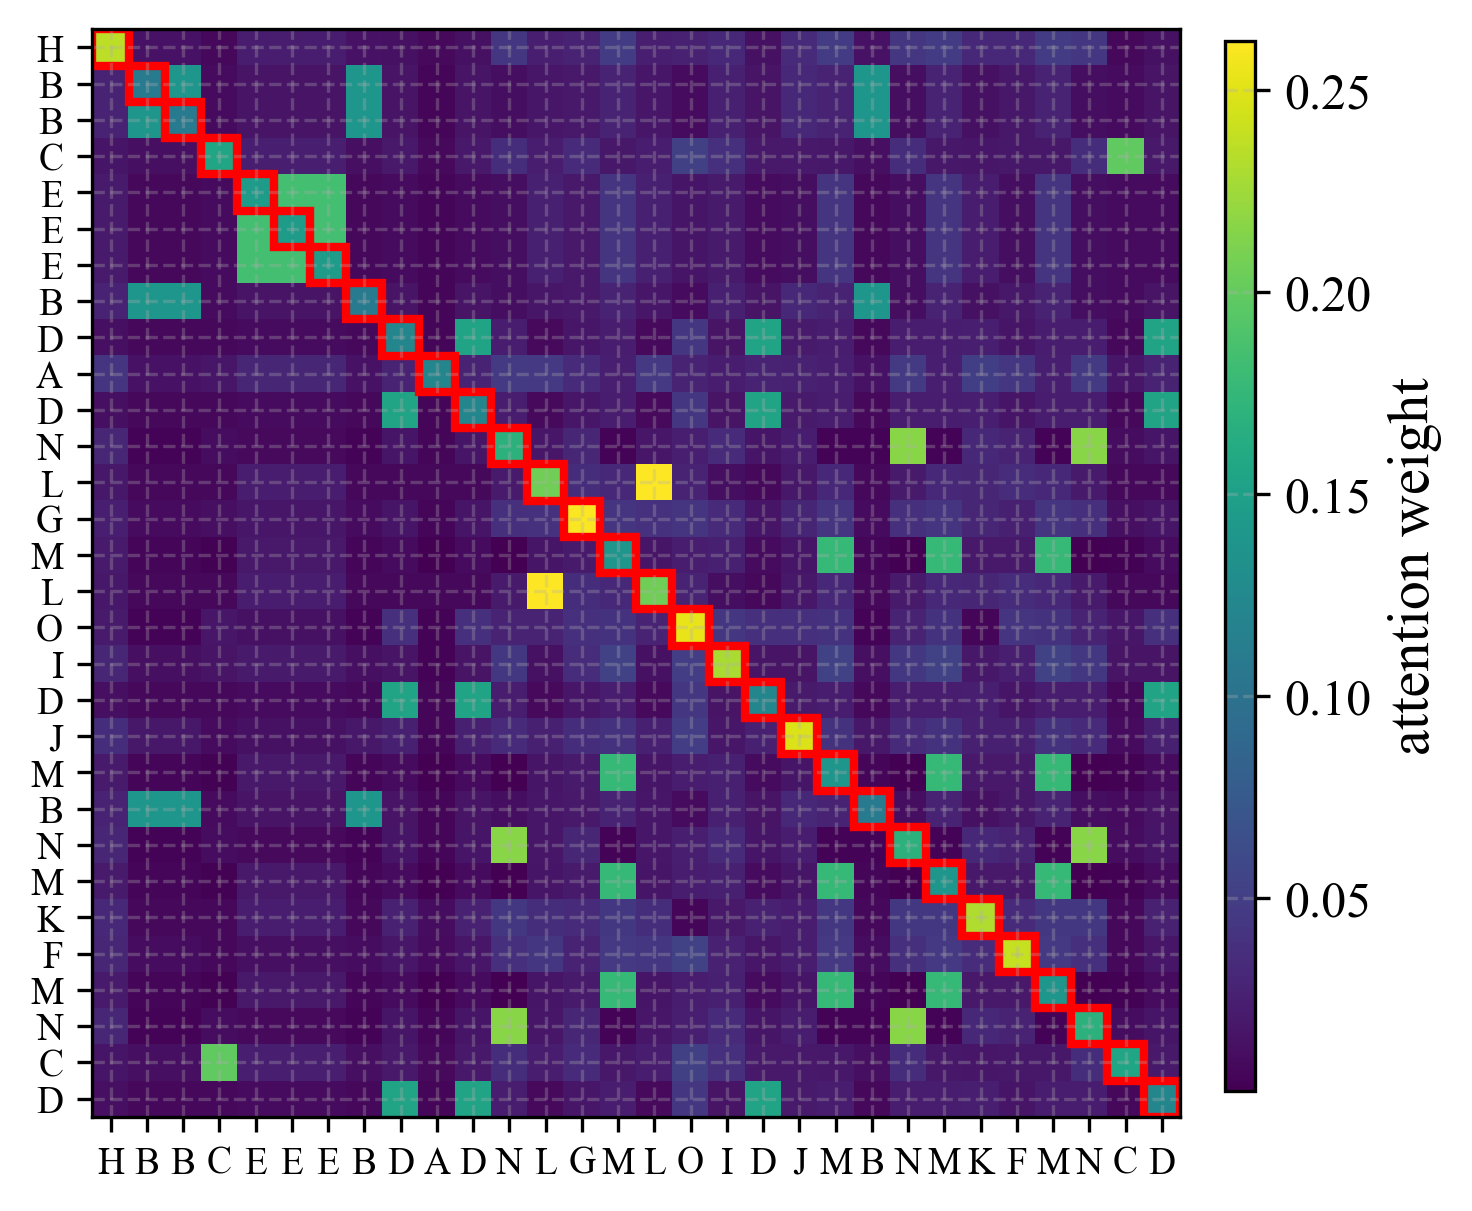

Processing file: attn_9.pkl
✅ Saved plot: ../results/run_20251217_0723/plots/attn_9_run3.png


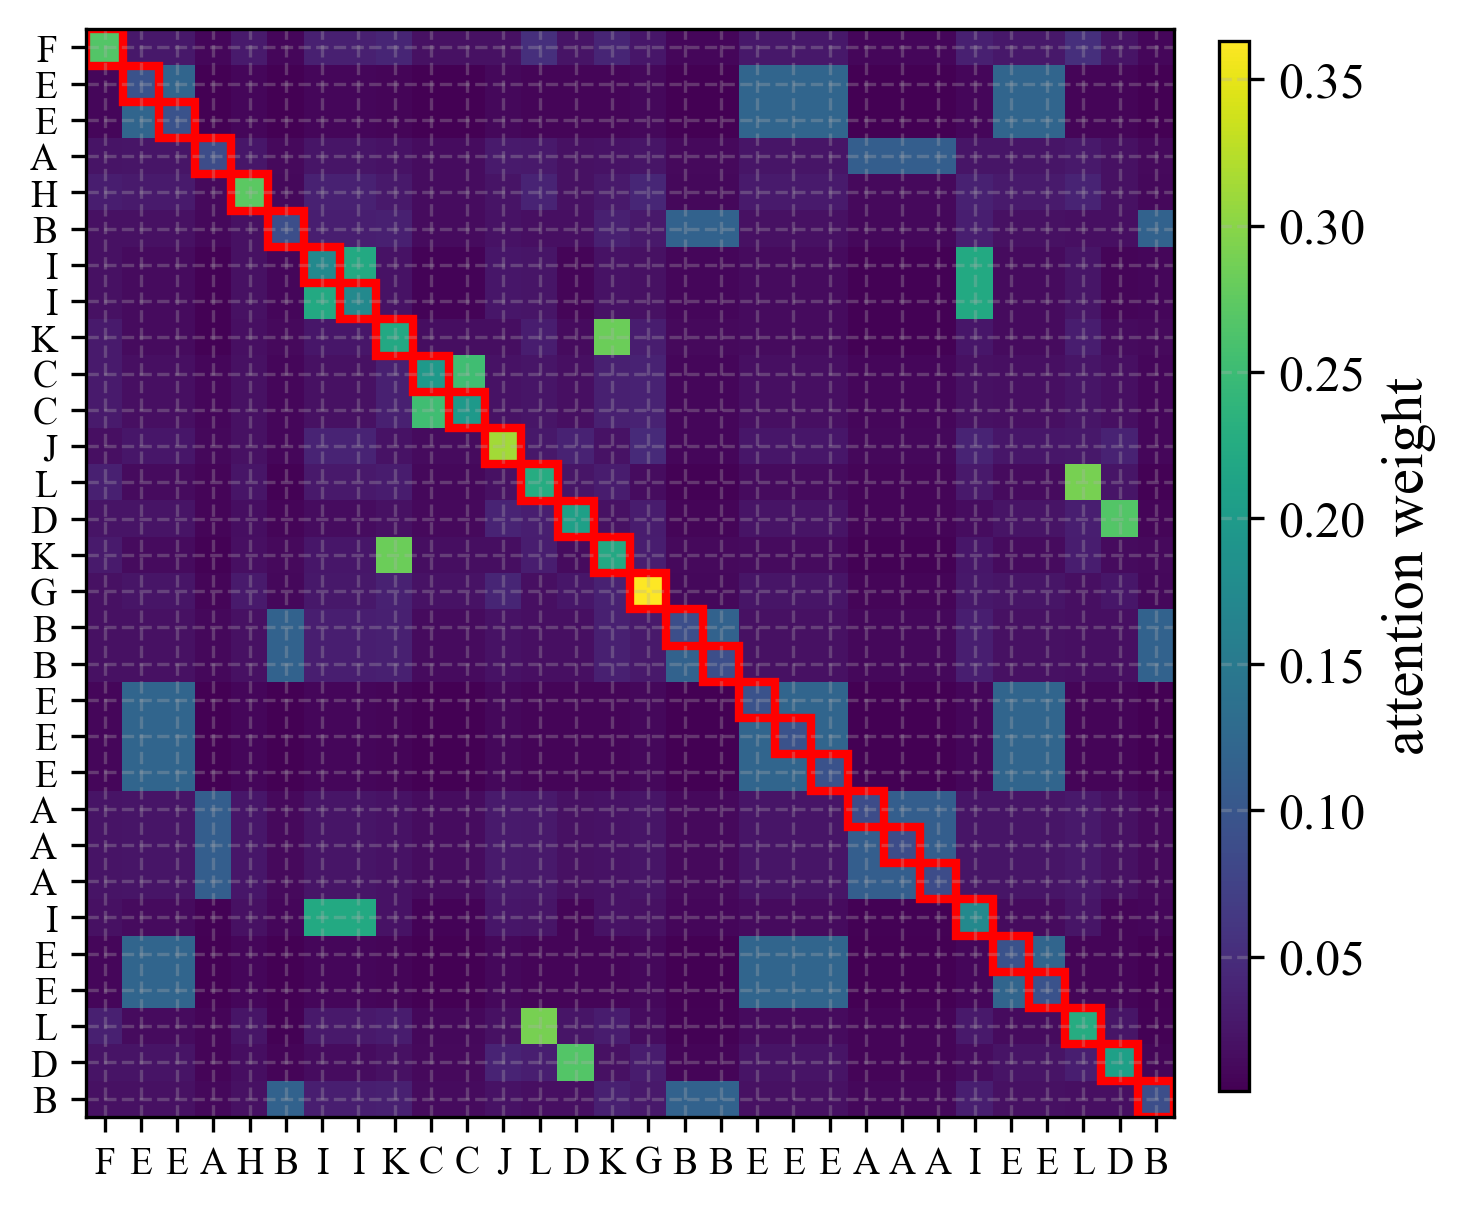

In [7]:
# Load attention and sequences
attn_files = sorted(glob.glob(os.path.join(run_dir, "attn_*.pkl")))
preds_files = sorted(glob.glob(os.path.join(run_dir, "preds_*.pkl")))

print(f"Found {len(attn_files)} attention files and {len(preds_files)} preds files")

# --- Configuration des chemins ---
# Assurez-vous que plot_path est défini avant la boucle
plot_path = os.path.join(run_dir, "plots") # Exemple de dossier de sortie
os.makedirs(plot_path, exist_ok=True) # Crée le dossier s'il n'existe pas

# --- Paramètres ---
NUM_EXAMPLES = 1 
RUN_IDX = 3
alphabet = list(string.ascii_uppercase)

print(f"Les images seront sauvegardées dans : {plot_path}")

for attn_path, preds_path in zip(attn_files, preds_files):

    print(f"Processing file: {os.path.basename(attn_path)}")

    # Load attention
    with open(attn_path, "rb") as f:
        attn_data = pickle.load(f)
    attn_all_runs = np.array(attn_data["attention_matrices"])

    # Load sequences
    with open(preds_path, "rb") as f:
        preds_data = pickle.load(f)
    seq_all_runs = preds_data["sequence_samples"]

    N_runs, N_samples, T, _ = attn_all_runs.shape

    # --- Select examples ---
    attn_examples = attn_all_runs[RUN_IDX, :NUM_EXAMPLES, :, :]
    seq_examples = seq_all_runs[RUN_IDX][:NUM_EXAMPLES]

    # Determine global min/max for colorbar
    vmin = attn_examples.min()
    vmax = attn_examples.max()

    # --- Plot matrices side by side ---
    fig, axes = plt.subplots(1, NUM_EXAMPLES, figsize=(5*NUM_EXAMPLES, 5))

    # Gestion axes unique vs multiple
    if NUM_EXAMPLES == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx in range(NUM_EXAMPLES):
        attn_matrix = attn_examples[idx]
        seq = seq_examples[idx]

        # Sequence → letters
        if seq.ndim == 2:
            token_seq = seq[:,0]
        elif seq.ndim == 1:
            token_seq = seq
        else:
            raise ValueError(f"Unexpected sequence shape: {seq.shape}")

        token_seq = token_seq[:T]
        token_labels = [alphabet[int(x) % len(alphabet)] for x in token_seq]
    
        ax = axes[idx]
        im = ax.imshow(attn_matrix, cmap="viridis", vmin=vmin, vmax=vmax)

        # Axis labels
        ax.set_xticks(np.arange(T))
        ax.set_xticklabels(token_labels, rotation=0, fontsize=9)
        ax.set_yticks(np.arange(T))
        ax.set_yticklabels(token_labels, fontsize=9)

        # Diagonal in red
        for i in range(T):
            rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)

    # --- Add colorbar ---
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="attention weight")

    # --- SAVE ---
    # 1. Récupérer le nom de base sans le chemin (ex: 'attn_data_01.pkl')
    base_name = os.path.basename(attn_path)
    # 2. Enlever l'extension .pkl (ex: 'attn_data_01')
    file_root = os.path.splitext(base_name)[0]
    # 3. Créer le nouveau nom .png
    save_name = f"{file_root}_run{RUN_IDX}.png"
    # 4. Joindre avec le dossier de destination
    save_full = os.path.join(plot_path, save_name)
    
    # bbox_inches='tight' enlève les marges blanches excessives
    fig.savefig(save_full, dpi=150, bbox_inches='tight') 
    
    print(f"✅ Saved plot: {save_full}")
    
    plt.show() # Optionnel si vous sauvegardez beaucoup de fichiers
    # plt.close(fig) # IMPORTANT : Ferme la figure pour libérer la mémoire (RAM)

✅ Figure sauvegardée : ../results/run_20251217_0723/plots_combined/Combined_Spectra_Attention_HorizontalColorbars.png


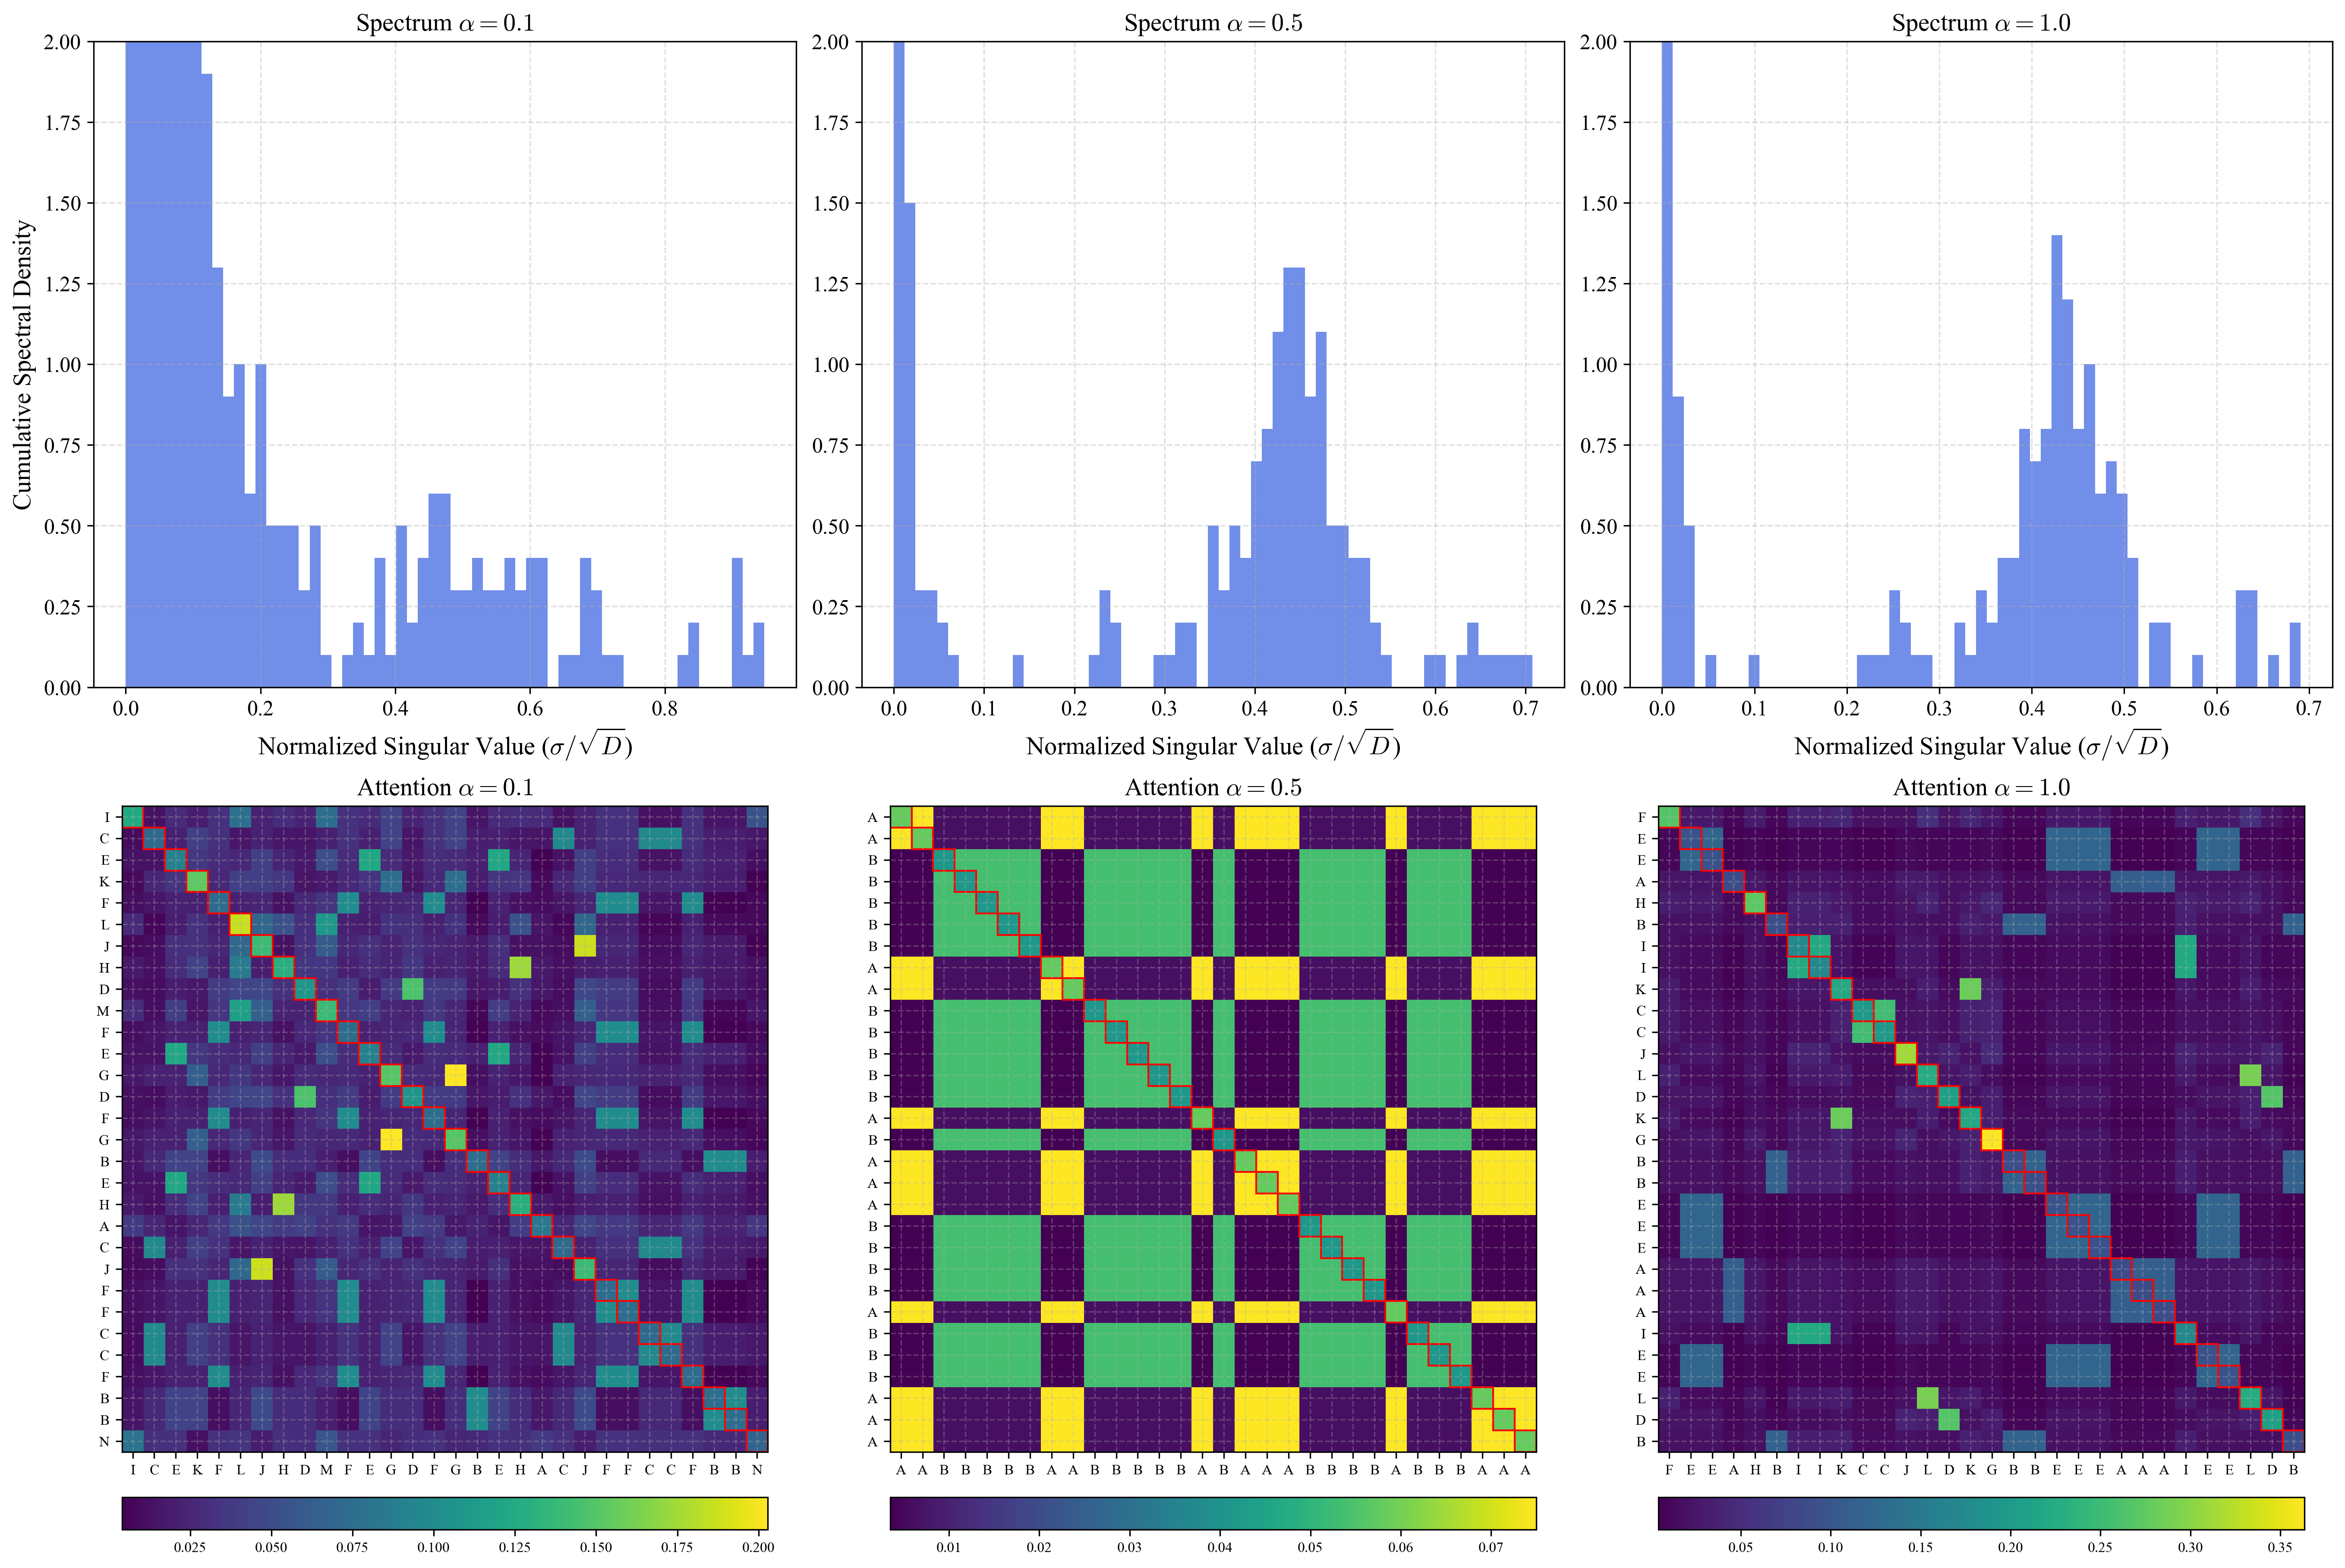

In [9]:
# ==========================================
# 1. CONFIGURATION
# ==========================================

# --- Dossiers (À ADAPTER) ---
plot_path = os.path.join(run_dir, "plots_combined")
os.makedirs(plot_path, exist_ok=True)

# Indices et Titres
INDICES_TO_PLOT = [0, 5, 14] 
TITLES = [r"$\alpha = 0.01$", r"$\alpha = 0.5$", r"$\alpha = 1.0$"]

RUN_IDX = 3       
SAMPLE_IDX = 0    
alphabet = list(string.ascii_uppercase)

heavy_files = sorted(glob.glob(os.path.join(run_dir, "heavy_data_*.pkl")))
attn_files = sorted(glob.glob(os.path.join(run_dir, "attn_*.pkl")))
preds_files = sorted(glob.glob(os.path.join(run_dir, "preds_*.pkl")))

# ==========================================
# 2. GÉNÉRATION DE LA FIGURE
# ==========================================

# On augmente un peu la hauteur (12) pour accommoder les colorbars en bas
fig, axes = plt.subplots(2, 3, figsize=(18, 12), constrained_layout=True)

for col, file_idx in enumerate(INDICES_TO_PLOT):
    
    current_title = TITLES[col]

    # --- CHARGEMENT ---
    with open(heavy_files[file_idx], "rb") as f:
        h_data = pickle.load(f)
    W_runs = h_data.get("W_runs", [])
    
    with open(attn_files[file_idx], "rb") as f:
        a_data = pickle.load(f)
    with open(preds_files[file_idx], "rb") as f:
        p_data = pickle.load(f)
        
    # --- PLOT 1 : SPECTRE (Haut) ---
    ax_spec = axes[0, col]
    
    if len(W_runs) > 0:
        all_singvals = []
        for W in W_runs:
            s = np.linalg.svd(W, compute_uv=False) / np.sqrt(W.shape[0])
            all_singvals.append(s)
        all_singvals = np.concatenate(all_singvals)
        
        bins = np.linspace(all_singvals.min(), all_singvals.max(), 60)
        hist, _ = np.histogram(all_singvals, bins=bins)
        hist = hist / len(W_runs)
        
        ax_spec.bar((bins[:-1] + bins[1:]) / 2, hist, width=np.diff(bins), alpha=0.75, color="royalblue")
    
    ax_spec.set_title(f"Spectrum {current_title}", fontsize=14)
    ax_spec.set_xlabel(r"Normalized Singular Value ($\sigma / \sqrt{D}$)")
    ax_spec.set_ylim(0, 2) 
    ax_spec.grid(True, linestyle="--", alpha=0.4)
    if col == 0:
        ax_spec.set_ylabel("Cumulative Spectral Density")

    # --- PLOT 2 : MATRICE (Bas) ---
    ax_attn = axes[1, col]
    
    attn_matrix = np.array(a_data["attention_matrices"])[RUN_IDX, SAMPLE_IDX]
    seq = p_data["sequence_samples"][RUN_IDX][SAMPLE_IDX]
    T = attn_matrix.shape[0]

    # Séquence -> Lettres
    if seq.ndim == 2: seq = seq[:, 0]
    token_seq = seq[:T]
    token_labels = [alphabet[int(x) % len(alphabet)] for x in token_seq]

    # Affichage
    im = ax_attn.imshow(attn_matrix, cmap="viridis") 
    
    ax_attn.set_title(f"Attention {current_title}", fontsize=14, loc='center')
    
    # Axes
    ax_attn.set_xticks(np.arange(T))
    ax_attn.set_xticklabels(token_labels, fontsize=8)
    ax_attn.set_yticks(np.arange(T))
    ax_attn.set_yticklabels(token_labels, fontsize=8)
    
    # Diagonale rouge
    for i in range(T):
        rect = Rectangle((i-0.5, i-0.5), 1, 1, linewidth=1, edgecolor='red', facecolor='none')
        ax_attn.add_patch(rect)

    # --- COLORBAR HORIZONTALE ---
    # orientation='horizontal' : couche la barre
    # location='bottom' : la force en bas
    # fraction=0.05 : définit l'épaisseur de la barre (5% de la hauteur du plot)
    # pad=0.15 : pousse la barre vers le bas pour laisser la place aux lettres (A, B, C...)
    cbar = plt.colorbar(im, ax=ax_attn, 
                        orientation='horizontal', 
                        location='bottom',
                        fraction=0.05, 
                        pad=0.03)
    cbar.ax.tick_params(labelsize=8)

# ==========================================
# 3. SAUVEGARDE
# ==========================================

save_name = "Combined_Spectra_Attention_HorizontalColorbars.png"
full_path = os.path.join(plot_path, save_name)

# plt.suptitle("Impact of Sample Complexity on Spectral Concentration and Attention Structure", fontsize=16)

plt.savefig(full_path, dpi=300, bbox_inches='tight')

print(f"✅ Figure sauvegardée : {full_path}")
plt.show()